# Common Setup for All Three Techniques

## Import Required Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# File and folder handling
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Use whitegrid style for all plots
sns.set_theme(style="whitegrid")

# t-SNE
from sklearn.manifold import TSNE

# UMAP
import umap

# DBSCAN clustering
from sklearn.cluster import DBSCAN

# Nearest-neighbor distances for DBSCAN epsilon selection
from sklearn.neighbors import NearestNeighbors

# Knee detection
from kneed import KneeLocator

# Clustering evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# PyTorch for Variational Autoencoder
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Random seed control
import random

## Define Project Folder Paths

In [2]:
# ---------------------------------------------------------
# Project root
# ---------------------------------------------------------

# This assumes the notebook is inside:
# notebooks/module_2/
ROOT_DIR = Path.cwd().resolve().parents[1]


# ---------------------------------------------------------
# Main folders
# ---------------------------------------------------------

DATA_DIR = ROOT_DIR / "data"

RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "module_2"
    / "3.nonlinear_dbscan_hyperparameter"
)

PLOTS_DIR = (
    ROOT_DIR
    / "plots"
    / "module_2"
    / "3.nonlinear_dbscan_hyperparameter"
)


# ---------------------------------------------------------
# Embedding folders
# Store the 2D representations from each method
# ---------------------------------------------------------

TSNE_EMBEDDINGS_DIR = RESULTS_DIR / "embeddings" / "tsne"
UMAP_EMBEDDINGS_DIR = RESULTS_DIR / "embeddings" / "umap"
VAE_EMBEDDINGS_DIR = RESULTS_DIR / "embeddings" / "vae"


# ---------------------------------------------------------
# Hyperparameter result folders
# Store tuning results and evaluation metrics
# ---------------------------------------------------------

TSNE_RESULTS_DIR = RESULTS_DIR / "hyperparameter_results" / "tsne"
UMAP_RESULTS_DIR = RESULTS_DIR / "hyperparameter_results" / "umap"
VAE_RESULTS_DIR = RESULTS_DIR / "hyperparameter_results" / "vae"


# ---------------------------------------------------------
# Cluster assignment folders
# Store patient IDs and DBSCAN cluster labels
# ---------------------------------------------------------

TSNE_CLUSTER_DIR = RESULTS_DIR / "clusters" / "tsne"
UMAP_CLUSTER_DIR = RESULTS_DIR / "clusters" / "umap"
VAE_CLUSTER_DIR = RESULTS_DIR / "clusters" / "vae"


# ---------------------------------------------------------
# Plot folders
# Store plots created during tuning
# ---------------------------------------------------------

TSNE_PLOTS_DIR = PLOTS_DIR / "tsne"
UMAP_PLOTS_DIR = PLOTS_DIR / "umap"
VAE_PLOTS_DIR = PLOTS_DIR / "vae"


# ---------------------------------------------------------
# Create all folders
# ---------------------------------------------------------

folders = [
    TSNE_EMBEDDINGS_DIR,
    UMAP_EMBEDDINGS_DIR,
    VAE_EMBEDDINGS_DIR,
    TSNE_RESULTS_DIR,
    UMAP_RESULTS_DIR,
    VAE_RESULTS_DIR,
    TSNE_CLUSTER_DIR,
    UMAP_CLUSTER_DIR,
    VAE_CLUSTER_DIR,
    TSNE_PLOTS_DIR,
    UMAP_PLOTS_DIR,
    VAE_PLOTS_DIR
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Confirm important paths
# ---------------------------------------------------------

print("Project root:")
print(ROOT_DIR)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nPlots folder:")
print(PLOTS_DIR)

print("\nAll required folders are ready.")

Project root:
C:\Users\samsa\Documents\ICU Clustering

Results folder:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter

Plots folder:
C:\Users\samsa\Documents\ICU Clustering\plots\module_2\3.nonlinear_dbscan_hyperparameter

All required folders are ready.


## Locate the Prepared Clustering Dataset

In [3]:
# Folder containing the outputs from dataset preparation
DATASET_PREP_DIR = (
    ROOT_DIR
    / "results"
    / "module_2"
    / "dataset_creation"
)

# Find CSV files saved in the dataset preparation folder
available_files = list(DATASET_PREP_DIR.glob("*.csv"))

print("Dataset preparation folder:")
print(DATASET_PREP_DIR)

print("\nAvailable CSV files:")

for file in available_files:
    print("-", file.name)

Dataset preparation folder:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation

Available CSV files:
- clustering_dataset_scaled.csv
- clustering_feature_names.csv
- feature_data_encoded.csv
- feature_data_imputed.csv
- vital_fpc_features.csv


## Load the Prepared Clustering Dataset and Feature Names

In [4]:
# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------

CLUSTERING_DATA_FILE = DATASET_PREP_DIR / "clustering_dataset_scaled.csv"
FEATURE_NAMES_FILE = DATASET_PREP_DIR / "clustering_feature_names.csv"


# ---------------------------------------------------------
# Load the final scaled clustering dataset
# ---------------------------------------------------------

clustering_data = pd.read_csv(CLUSTERING_DATA_FILE)


# ---------------------------------------------------------
# Load the clustering feature names
# ---------------------------------------------------------

feature_names_df = pd.read_csv(FEATURE_NAMES_FILE)


# ---------------------------------------------------------
# Display basic information
# ---------------------------------------------------------

print("Clustering dataset shape:")
print(clustering_data.shape)

print("\nFeature names file shape:")
print(feature_names_df.shape)

print("\nFirst 5 rows of clustering dataset:")
display(clustering_data.head())

print("\nFeature names file:")
display(feature_names_df.head())

Clustering dataset shape:
(7859, 81)

Feature names file shape:
(80, 1)

First 5 rows of clustering dataset:


,patientunitstayid,age,gender,admissionheight,admissionweight,BUN_min,Hgb_min,WBC x 1000_min,anion gap_min,bicarbonate_min,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,151900,0.666667,0.0,0.271546,0.077035,0.055777,0.283237,0.028740,0.339286,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,165269,0.486111,1.0,0.267434,0.057636,0.143426,0.364162,0.042126,0.410714,0.219512,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179269,0.888889,0.0,0.254770,0.061000,0.183267,0.410405,0.023228,0.482143,0.439024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,172764,0.736111,0.0,0.275658,0.075577,0.039841,0.705202,0.073622,0.535714,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,215156,0.680556,0.0,0.250658,0.065598,0.135458,0.398844,0.013386,0.464286,0.390244,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0



Feature names file:


,feature_name
0,age
1,gender
2,admissionheight
3,admissionweight
4,BUN_min


## Extract the Clustering Feature Names and Create the Feature Matrix

In [5]:
# ---------------------------------------------------------
# Check the feature names file
# ---------------------------------------------------------

print("Columns in feature names file:")
print(feature_names_df.columns.tolist())


# ---------------------------------------------------------
# Extract clustering feature names
# ---------------------------------------------------------

clustering_features = feature_names_df.iloc[:, 0].tolist()


# ---------------------------------------------------------
# Keep patient IDs separately
# ---------------------------------------------------------

patient_ids = clustering_data["patientunitstayid"].copy()


# ---------------------------------------------------------
# Create the clustering feature matrix
# ---------------------------------------------------------

X = clustering_data[clustering_features].copy()


# ---------------------------------------------------------
# Display basic information
# ---------------------------------------------------------

print("\nNumber of patients:")
print(X.shape[0])

print("\nNumber of clustering features:")
print(X.shape[1])

print("\nFirst 10 clustering features:")
print(clustering_features[:10])

print("\nFeature matrix preview:")
display(X.head())

Columns in feature names file:
['feature_name']

Number of patients:
7859

Number of clustering features:
80

First 10 clustering features:
['age', 'gender', 'admissionheight', 'admissionweight', 'BUN_min', 'Hgb_min', 'WBC x 1000_min', 'anion gap_min', 'bicarbonate_min', 'chloride_min']

Feature matrix preview:


,age,gender,admissionheight,admissionweight,BUN_min,Hgb_min,WBC x 1000_min,anion gap_min,bicarbonate_min,chloride_min,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,0.666667,0.0,0.271546,0.077035,0.055777,0.283237,0.028740,0.339286,0.512195,0.468354,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.486111,1.0,0.267434,0.057636,0.143426,0.364162,0.042126,0.410714,0.219512,0.531646,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.888889,0.0,0.254770,0.061000,0.183267,0.410405,0.023228,0.482143,0.439024,0.569620,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.736111,0.0,0.275658,0.075577,0.039841,0.705202,0.073622,0.535714,0.317073,0.455696,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.680556,0.0,0.250658,0.065598,0.135458,0.398844,0.013386,0.464286,0.390244,0.417722,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Validate the Input Dataset

In [6]:
# ---------------------------------------------------------
# Basic dataset validation
# ---------------------------------------------------------

print("Dataset Validation")
print("=" * 50)

# Number of patients and features
print("Number of patients:", X.shape[0])
print("Number of clustering features:", X.shape[1])


# ---------------------------------------------------------
# Check patient IDs
# ---------------------------------------------------------

print("\nUnique patients:", patient_ids.nunique())
print("Duplicate patient IDs:", patient_ids.duplicated().sum())


# ---------------------------------------------------------
# Check missing values
# ---------------------------------------------------------

missing_values = X.isna().sum().sum()

print("\nMissing values:", missing_values)


# ---------------------------------------------------------
# Check infinite values
# ---------------------------------------------------------

infinite_values = np.isinf(X.to_numpy()).sum()

print("Infinite values:", infinite_values)


# ---------------------------------------------------------
# Check feature value range
# ---------------------------------------------------------

print("\nMinimum feature value:", X.min().min())
print("Maximum feature value:", X.max().max())


# ---------------------------------------------------------
# Check feature order
# ---------------------------------------------------------

feature_order_matches = X.columns.tolist() == clustering_features

print("\nFeature order matches saved feature list:",
      feature_order_matches)

Dataset Validation
Number of patients: 7859
Number of clustering features: 80

Unique patients: 7859
Duplicate patient IDs: 0

Missing values: 0
Infinite values: 0

Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002

Feature order matches saved feature list: True


# t-SNE + DBSCAN Hyperparameter Tuning

## Define t-SNE Hyperparameter Search Settings

In [7]:
# ---------------------------------------------------------
# t-SNE hyperparameter values to test
# ---------------------------------------------------------

tsne_perplexities = [
    i for i in range(20,81,10)
]


# ---------------------------------------------------------
# Fixed t-SNE settings
# ---------------------------------------------------------

TSNE_COMPONENTS = 2
TSNE_METRIC = "euclidean"
RANDOM_STATE = 42


# ---------------------------------------------------------
# Fixed DBSCAN settings
# ---------------------------------------------------------

DBSCAN_MIN_SAMPLES = 50

# Epsilon values will be calculated relative to the knee point
EPSILON_MULTIPLIERS = [
    0.80,
    0.90,
    1.00
]


# ---------------------------------------------------------
# Display tuning settings
# ---------------------------------------------------------

print("t-SNE + DBSCAN Hyperparameter Settings")
print("=" * 50)

print("\nPerplexity values:")
print(tsne_perplexities)

print("\nFixed t-SNE settings:")
print("Embedding dimensions:", TSNE_COMPONENTS)
print("Distance metric:", TSNE_METRIC)
print("Random seed:", RANDOM_STATE)

print("\nFixed DBSCAN settings:")
print("Minimum samples:", DBSCAN_MIN_SAMPLES)
print("Epsilon multipliers:", EPSILON_MULTIPLIERS)

t-SNE + DBSCAN Hyperparameter Settings

Perplexity values:
[20, 30, 40, 50, 60, 70, 80]

Fixed t-SNE settings:
Embedding dimensions: 2
Distance metric: euclidean
Random seed: 42

Fixed DBSCAN settings:
Minimum samples: 50
Epsilon multipliers: [0.8, 0.9, 1.0]


## Generate and Save t-SNE Embeddings

In [8]:
# ---------------------------------------------------------
# Store t-SNE embeddings
# ---------------------------------------------------------

tsne_embeddings = {}


# ---------------------------------------------------------
# Generate one embedding for each perplexity
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    print(f"Generating t-SNE embedding for perplexity = {perplexity}...")

    # Create t-SNE model
    tsne_model = TSNE(
        n_components=TSNE_COMPONENTS,
        perplexity=perplexity,
        metric=TSNE_METRIC,
        random_state=RANDOM_STATE,
        init="pca",
        learning_rate="auto"
    )

    # Generate 2D embedding
    embedding = tsne_model.fit_transform(X)

    # Store embedding for later use
    tsne_embeddings[perplexity] = embedding

    # Create DataFrame for saving
    embedding_df = pd.DataFrame({
        "patientunitstayid": patient_ids.values,
        "tsne_1": embedding[:, 0],
        "tsne_2": embedding[:, 1]
    })

    # Save embedding
    output_file = (
        TSNE_EMBEDDINGS_DIR
        / f"tsne_perplexity_{perplexity}.csv"
    )

    embedding_df.to_csv(output_file, index=False)

    print(f"Saved: {output_file.name}")


print("\nAll t-SNE embeddings generated successfully.")

Generating t-SNE embedding for perplexity = 20...
Saved: tsne_perplexity_20.csv
Generating t-SNE embedding for perplexity = 30...
Saved: tsne_perplexity_30.csv
Generating t-SNE embedding for perplexity = 40...
Saved: tsne_perplexity_40.csv
Generating t-SNE embedding for perplexity = 50...
Saved: tsne_perplexity_50.csv
Generating t-SNE embedding for perplexity = 60...
Saved: tsne_perplexity_60.csv
Generating t-SNE embedding for perplexity = 70...
Saved: tsne_perplexity_70.csv
Generating t-SNE embedding for perplexity = 80...
Saved: tsne_perplexity_80.csv

All t-SNE embeddings generated successfully.


## Calculate the $50$-Nearest Neighbor Distance Curves

In [9]:
# ---------------------------------------------------------
# Store sorted 50-NN distances for each perplexity
# ---------------------------------------------------------

tsne_knn_distances = {}


# ---------------------------------------------------------
# Calculate 50-NN distances
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    print(f"Calculating 50-NN distances for perplexity = {perplexity}...")

    # Get the saved t-SNE embedding from memory
    embedding = tsne_embeddings[perplexity]

    # Fit nearest-neighbor model
    neighbors = NearestNeighbors(
        n_neighbors=DBSCAN_MIN_SAMPLES,
        metric="euclidean"
    )

    neighbors.fit(embedding)

    # Calculate distances to nearest neighbors
    distances, _ = neighbors.kneighbors(embedding)

    # Keep the distance to the 50th nearest neighbor
    k_distances = distances[:, -1]

    # Sort distances from smallest to largest
    k_distances = np.sort(k_distances)

    # Store for later knee detection
    tsne_knn_distances[perplexity] = k_distances


print("\n50-NN distance curves calculated successfully.")

Calculating 50-NN distances for perplexity = 20...
Calculating 50-NN distances for perplexity = 30...
Calculating 50-NN distances for perplexity = 40...
Calculating 50-NN distances for perplexity = 50...
Calculating 50-NN distances for perplexity = 60...
Calculating 50-NN distances for perplexity = 70...
Calculating 50-NN distances for perplexity = 80...

50-NN distance curves calculated successfully.


## Detect the Knee Point for Each t-SNE Embedding

In [10]:
# ---------------------------------------------------------
# Store knee values for each perplexity
# ---------------------------------------------------------

tsne_knee_values = {}


# ---------------------------------------------------------
# Detect knee point
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    print(f"Detecting knee for perplexity = {perplexity}...")

    # Get sorted 50-NN distances
    k_distances = tsne_knn_distances[perplexity]

    # X-axis values for the distance curve
    x_values = np.arange(len(k_distances))

    # Detect the knee point
    knee_locator = KneeLocator(
        x_values,
        k_distances,
        curve="convex",
        direction="increasing"
    )

    # Get the distance value at the knee
    knee_index = knee_locator.knee

    if knee_index is not None:
        knee_value = k_distances[knee_index]
    else:
        knee_value = np.nan

    # Store knee value
    tsne_knee_values[perplexity] = knee_value

    print("Knee value:", knee_value)


print("\nKnee detection completed.")

Detecting knee for perplexity = 20...
Knee value: 11.264355543764642
Detecting knee for perplexity = 30...
Knee value: 9.448648927501294
Detecting knee for perplexity = 40...
Knee value: 12.67115992723129
Detecting knee for perplexity = 50...
Knee value: 10.315452916964487
Detecting knee for perplexity = 60...
Knee value: 9.868577066013351
Detecting knee for perplexity = 70...
Knee value: 8.94044567454542
Detecting knee for perplexity = 80...
Knee value: 10.820534853000948

Knee detection completed.


## Plot the $50$-NN Distance Curves and Knee Points

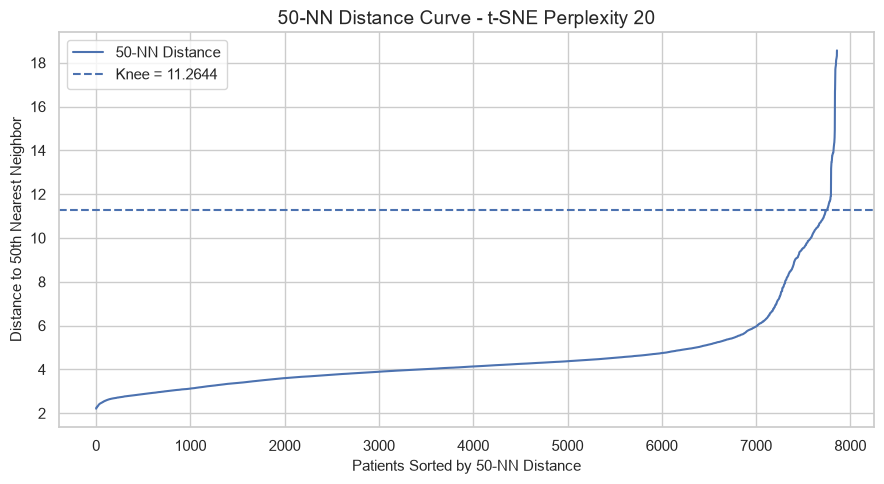

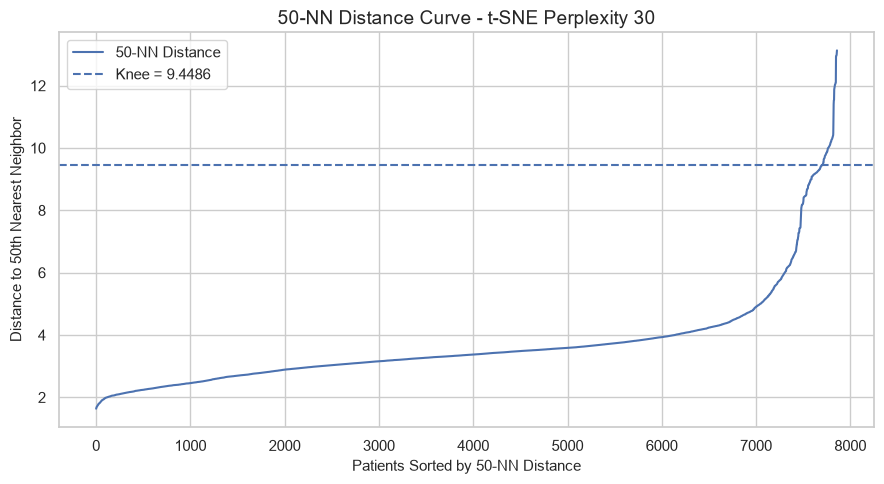

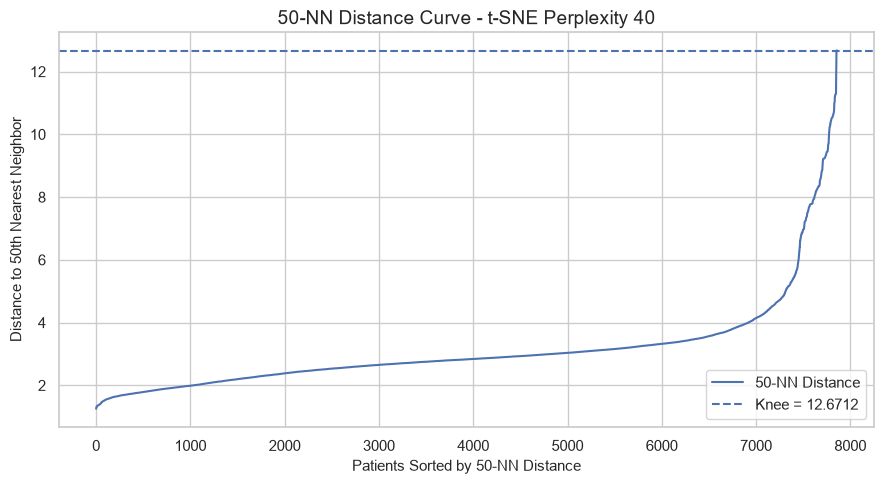

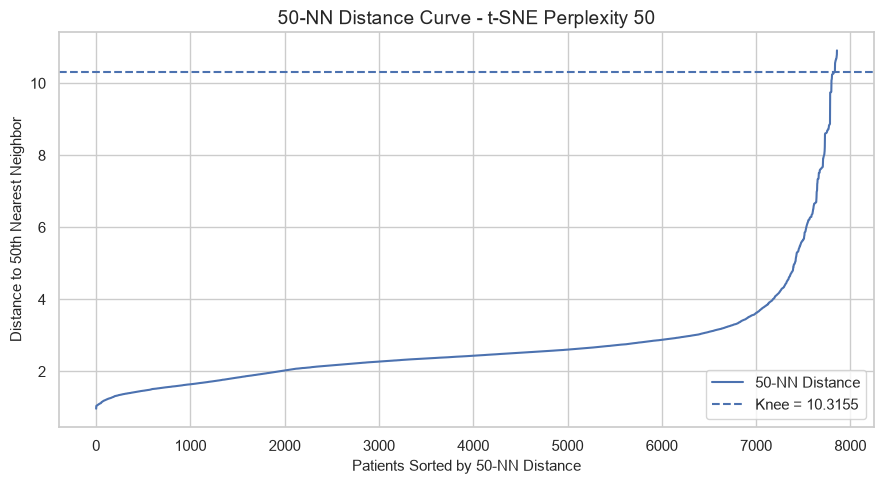

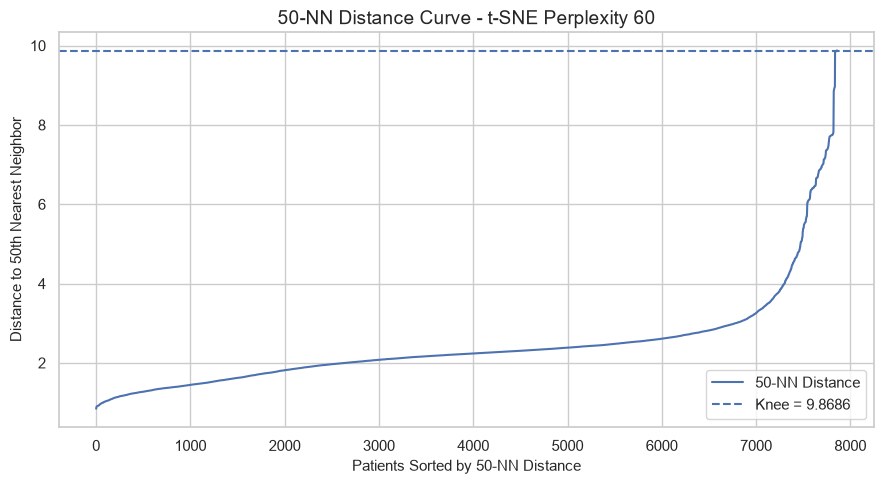

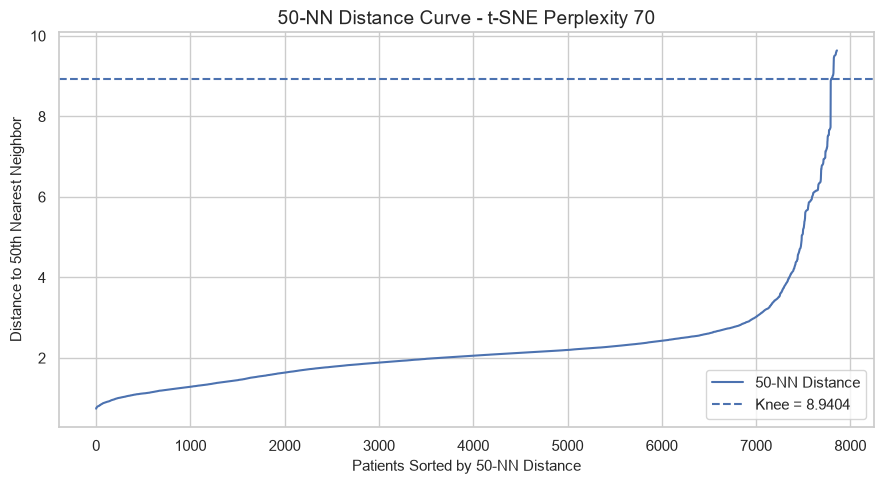

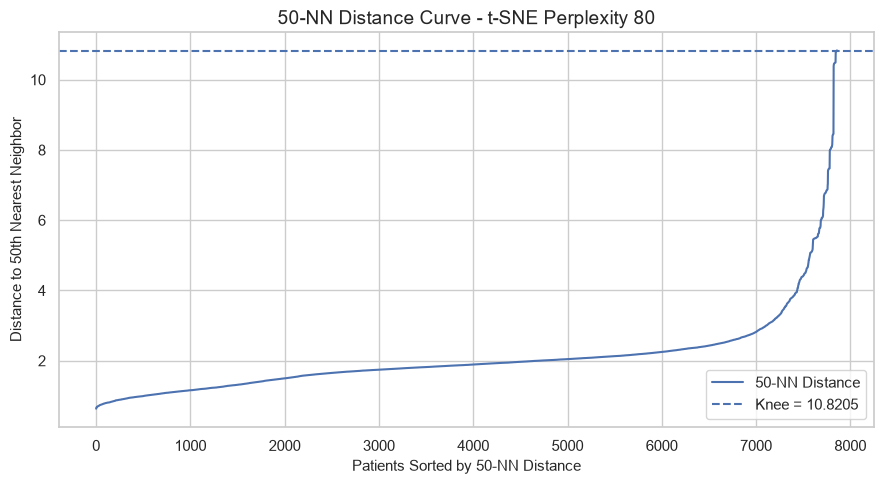

In [11]:
# ---------------------------------------------------------
# Plot 50-NN distance curve for each perplexity
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    # Get the sorted 50-NN distances
    k_distances = tsne_knn_distances[perplexity]

    # Get the detected knee value
    knee_value = tsne_knee_values[perplexity]

    # X-axis values
    x_values = np.arange(len(k_distances))


    # -----------------------------------------------------
    # Create plot
    # -----------------------------------------------------

    plt.figure(figsize=(9, 5))

    # Plot the 50-NN distance curve
    sns.lineplot(
        x=x_values,
        y=k_distances,
        label="50-NN Distance"
    )


    # -----------------------------------------------------
    # Add detected knee
    # -----------------------------------------------------

    if not np.isnan(knee_value):

        plt.axhline(
            y=knee_value,
            linestyle="--",
            label=f"Knee = {knee_value:.4f}"
        )


    # -----------------------------------------------------
    # Plot formatting
    # -----------------------------------------------------

    plt.title(
        f"50-NN Distance Curve - t-SNE Perplexity {perplexity}",
        fontsize=14
    )

    plt.xlabel(
        "Patients Sorted by 50-NN Distance",
        fontsize=11
    )

    plt.ylabel(
        "Distance to 50th Nearest Neighbor",
        fontsize=11
    )

    plt.legend()
    plt.tight_layout()


    # -----------------------------------------------------
    # Save plot
    # -----------------------------------------------------

    plot_file = (
        TSNE_PLOTS_DIR
        / f"knn_curve_perplexity_{perplexity}.png"
    )

    plt.savefig(
        plot_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Create DBSCAN Epsilon Candidates from the Knee Values

In [12]:
# ---------------------------------------------------------
# Store epsilon candidates for each perplexity
# ---------------------------------------------------------

tsne_epsilon_candidates = {}


# ---------------------------------------------------------
# Create epsilon values from each knee
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    knee_value = tsne_knee_values[perplexity]

    # Skip if no knee was detected
    if np.isnan(knee_value):
        print(f"Perplexity {perplexity}: No knee detected")
        continue

    # Calculate epsilon candidates
    epsilon_values = [
        0.80 * knee_value,
        0.90 * knee_value,
        1.00 * knee_value
    ]

    # Store values
    tsne_epsilon_candidates[perplexity] = epsilon_values

    # Display values
    print(f"\nPerplexity = {perplexity}")
    print(f"Knee value = {knee_value:.4f}")

    print("Epsilon candidates:")

    for epsilon in epsilon_values:
        print(f"- {epsilon:.4f}")


Perplexity = 20
Knee value = 11.2644
Epsilon candidates:
- 9.0115
- 10.1379
- 11.2644

Perplexity = 30
Knee value = 9.4486
Epsilon candidates:
- 7.5589
- 8.5038
- 9.4486

Perplexity = 40
Knee value = 12.6712
Epsilon candidates:
- 10.1369
- 11.4040
- 12.6712

Perplexity = 50
Knee value = 10.3155
Epsilon candidates:
- 8.2524
- 9.2839
- 10.3155

Perplexity = 60
Knee value = 9.8686
Epsilon candidates:
- 7.8949
- 8.8817
- 9.8686

Perplexity = 70
Knee value = 8.9404
Epsilon candidates:
- 7.1524
- 8.0464
- 8.9404

Perplexity = 80
Knee value = 10.8205
Epsilon candidates:
- 8.6564
- 9.7385
- 10.8205


## Run DBSCAN for Every t-SNE and Epsilon Combination

In [13]:
# ---------------------------------------------------------
# Store DBSCAN cluster labels
# ---------------------------------------------------------

tsne_cluster_labels = {}


# ---------------------------------------------------------
# Run DBSCAN for every t-SNE configuration
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    # Skip perplexity if no knee was detected
    if perplexity not in tsne_epsilon_candidates:
        continue

    # Get t-SNE embedding
    embedding = tsne_embeddings[perplexity]

    # Get epsilon candidates
    epsilon_values = tsne_epsilon_candidates[perplexity]


    # -----------------------------------------------------
    # Test each epsilon value
    # -----------------------------------------------------

    for multiplier, epsilon in zip(
        EPSILON_MULTIPLIERS,
        epsilon_values
    ):

        print(
            f"Running DBSCAN: "
            f"Perplexity = {perplexity}, "
            f"Epsilon = {epsilon:.4f}"
        )

        # Create DBSCAN model
        dbscan_model = DBSCAN(
            eps=epsilon,
            min_samples=DBSCAN_MIN_SAMPLES,
            metric="euclidean"
        )

        # Run clustering
        labels = dbscan_model.fit_predict(embedding)

        # Store cluster labels
        tsne_cluster_labels[
            (perplexity, multiplier)
        ] = labels


        # -------------------------------------------------
        # Create cluster assignment DataFrame
        # -------------------------------------------------

        cluster_df = pd.DataFrame({
            "patientunitstayid": patient_ids.values,
            "cluster": labels
        })


        # -------------------------------------------------
        # Save cluster assignments
        # -------------------------------------------------

        multiplier_name = int(multiplier * 100)

        output_file = (
            TSNE_CLUSTER_DIR
            / (
                f"tsne_perplexity_{perplexity}"
                f"_eps_{multiplier_name}_percent_knee.csv"
            )
        )

        cluster_df.to_csv(
            output_file,
            index=False
        )

        print(f"Saved: {output_file.name}\n")


print("All t-SNE + DBSCAN configurations completed.")

Running DBSCAN: Perplexity = 20, Epsilon = 9.0115
Saved: tsne_perplexity_20_eps_80_percent_knee.csv

Running DBSCAN: Perplexity = 20, Epsilon = 10.1379
Saved: tsne_perplexity_20_eps_90_percent_knee.csv

Running DBSCAN: Perplexity = 20, Epsilon = 11.2644
Saved: tsne_perplexity_20_eps_100_percent_knee.csv

Running DBSCAN: Perplexity = 30, Epsilon = 7.5589
Saved: tsne_perplexity_30_eps_80_percent_knee.csv

Running DBSCAN: Perplexity = 30, Epsilon = 8.5038
Saved: tsne_perplexity_30_eps_90_percent_knee.csv

Running DBSCAN: Perplexity = 30, Epsilon = 9.4486
Saved: tsne_perplexity_30_eps_100_percent_knee.csv

Running DBSCAN: Perplexity = 40, Epsilon = 10.1369
Saved: tsne_perplexity_40_eps_80_percent_knee.csv

Running DBSCAN: Perplexity = 40, Epsilon = 11.4040
Saved: tsne_perplexity_40_eps_90_percent_knee.csv

Running DBSCAN: Perplexity = 40, Epsilon = 12.6712
Saved: tsne_perplexity_40_eps_100_percent_knee.csv

Running DBSCAN: Perplexity = 50, Epsilon = 8.2524
Saved: tsne_perplexity_50_eps_80_

## Calculate Cluster Statistics for Every Configuration

In [14]:
# ---------------------------------------------------------
# Store cluster statistics
# ---------------------------------------------------------

tsne_cluster_statistics = []


# ---------------------------------------------------------
# Calculate statistics for every configuration
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    # Skip if no knee was detected
    if perplexity not in tsne_epsilon_candidates:
        continue

    epsilon_values = tsne_epsilon_candidates[perplexity]


    for multiplier, epsilon in zip(
        EPSILON_MULTIPLIERS,
        epsilon_values
    ):

        # Get DBSCAN cluster labels
        labels = tsne_cluster_labels[
            (perplexity, multiplier)
        ]


        # -------------------------------------------------
        # Number of clusters
        # -------------------------------------------------

        unique_labels = np.unique(labels)

        # Exclude -1 because it represents outliers
        cluster_labels = unique_labels[unique_labels != -1]

        number_of_clusters = len(cluster_labels)


        # -------------------------------------------------
        # Outlier information
        # -------------------------------------------------

        number_of_outliers = np.sum(labels == -1)

        outlier_percentage = (
            number_of_outliers / len(labels)
        ) * 100


        # -------------------------------------------------
        # Smallest cluster size
        # -------------------------------------------------

        if number_of_clusters > 0:

            cluster_sizes = [
                np.sum(labels == cluster)
                for cluster in cluster_labels
            ]

            smallest_cluster_size = min(cluster_sizes)

        else:
            smallest_cluster_size = 0


        # -------------------------------------------------
        # Store results
        # -------------------------------------------------

        tsne_cluster_statistics.append({
            "perplexity": perplexity,
            "epsilon_multiplier": multiplier,
            "epsilon": epsilon,
            "number_of_clusters": number_of_clusters,
            "number_of_outliers": number_of_outliers,
            "outlier_percentage": outlier_percentage,
            "smallest_cluster_size": smallest_cluster_size
        })


# ---------------------------------------------------------
# Convert results to DataFrame
# ---------------------------------------------------------

tsne_cluster_statistics_df = pd.DataFrame(
    tsne_cluster_statistics
)


# ---------------------------------------------------------
# Save cluster statistics table
# ---------------------------------------------------------

cluster_statistics_file = (
    TSNE_CLUSTER_DIR
    / "tsne_cluster_statistics.csv"
)

tsne_cluster_statistics_df.to_csv(
    cluster_statistics_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("Cluster statistics saved to:")
print(cluster_statistics_file)

display(tsne_cluster_statistics_df)

Cluster statistics saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\tsne\tsne_cluster_statistics.csv


,perplexity,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size
0,20,0.8,9.011484,16,166,2.112228,58
1,20,0.9,10.137920,12,65,0.827077,58
2,20,1.0,11.264356,7,49,0.623489,58
3,30,0.8,7.558919,19,248,3.155618,61
4,30,0.9,8.503784,17,73,0.928871,49
5,30,1.0,9.448649,13,26,0.330831,70
6,40,0.8,10.136928,10,9,0.114518,98
7,40,0.9,11.404044,4,0,0.000000,201
8,40,1.0,12.671160,2,0,0.000000,240
9,50,0.8,8.252362,11,68,0.865250,70


## Calculate and Save Internal Clustering Metrics

In [15]:
# ---------------------------------------------------------
# Store internal metric results
# ---------------------------------------------------------

tsne_metric_results = []


# ---------------------------------------------------------
# Calculate metrics for every configuration
# ---------------------------------------------------------

for perplexity in tsne_perplexities:

    # Skip if no knee was detected
    if perplexity not in tsne_epsilon_candidates:
        continue

    epsilon_values = tsne_epsilon_candidates[perplexity]


    for multiplier, epsilon in zip(
        EPSILON_MULTIPLIERS,
        epsilon_values
    ):

        # Get embedding and cluster labels
        embedding = tsne_embeddings[perplexity]

        labels = tsne_cluster_labels[
            (perplexity, multiplier)
        ]


        # -------------------------------------------------
        # Remove DBSCAN outliers
        # -------------------------------------------------

        non_outlier_mask = labels != -1

        embedding_clean = embedding[non_outlier_mask]
        labels_clean = labels[non_outlier_mask]


        # -------------------------------------------------
        # Count remaining clusters
        # -------------------------------------------------

        number_of_clusters = len(
            np.unique(labels_clean)
        )


        # -------------------------------------------------
        # Calculate internal metrics
        # -------------------------------------------------

        if number_of_clusters >= 2:

            silhouette = silhouette_score(
                embedding_clean,
                labels_clean
            )

            davies_bouldin = davies_bouldin_score(
                embedding_clean,
                labels_clean
            )

            calinski_harabasz = calinski_harabasz_score(
                embedding_clean,
                labels_clean
            )

        else:

            silhouette = np.nan
            davies_bouldin = np.nan
            calinski_harabasz = np.nan


        # -------------------------------------------------
        # Store results
        # -------------------------------------------------

        tsne_metric_results.append({
            "perplexity": perplexity,
            "epsilon_multiplier": multiplier,
            "epsilon": epsilon,
            "silhouette_score": silhouette,
            "davies_bouldin_index": davies_bouldin,
            "calinski_harabasz_index": calinski_harabasz
        })


# ---------------------------------------------------------
# Convert results to DataFrame
# ---------------------------------------------------------

tsne_metric_results_df = pd.DataFrame(
    tsne_metric_results
)


# ---------------------------------------------------------
# Save internal metrics table
# ---------------------------------------------------------

metric_results_file = (
    TSNE_CLUSTER_DIR
    / "tsne_internal_metrics.csv"
)

tsne_metric_results_df.to_csv(
    metric_results_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("Internal metrics saved to:")
print(metric_results_file)

display(tsne_metric_results_df)

Internal metrics saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\tsne\tsne_internal_metrics.csv


,perplexity,epsilon_multiplier,epsilon,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,20,0.8,9.011484,0.450687,0.509690,4709.812395
1,20,0.9,10.137920,0.365273,0.613046,3883.205309
2,20,1.0,11.264356,-0.058121,0.636103,409.416715
3,30,0.8,7.558919,0.523169,0.482846,5496.932117
4,30,0.9,8.503784,0.461691,0.539469,5240.151256
5,30,1.0,9.448649,0.414306,0.537765,4788.729615
6,40,0.8,10.136928,0.442062,0.623988,5325.675645
7,40,0.9,11.404044,0.165929,0.824019,1781.111394
8,40,1.0,12.671160,0.197463,0.678463,535.072188
9,50,0.8,8.252362,0.518743,0.783927,6569.021583


## Combine Cluster Statistics and Internal Metrics

In [16]:
# ---------------------------------------------------------
# Combine cluster statistics and internal metrics
# ---------------------------------------------------------

tsne_tuning_results = pd.merge(
    tsne_cluster_statistics_df,
    tsne_metric_results_df,
    on=[
        "perplexity",
        "epsilon_multiplier",
        "epsilon"
    ]
)


# ---------------------------------------------------------
# Save complete tuning results
# ---------------------------------------------------------

tuning_results_file = (
    TSNE_RESULTS_DIR
    / "tsne_hyperparameter_tuning_results.csv"
)

tsne_tuning_results.to_csv(
    tuning_results_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("Complete t-SNE tuning results saved to:")
print(tuning_results_file)

display(tsne_tuning_results)

Complete t-SNE tuning results saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\tsne\tsne_hyperparameter_tuning_results.csv


,perplexity,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,20,0.8,9.011484,16,166,2.112228,58,0.450687,0.509690,4709.812395
1,20,0.9,10.137920,12,65,0.827077,58,0.365273,0.613046,3883.205309
2,20,1.0,11.264356,7,49,0.623489,58,-0.058121,0.636103,409.416715
3,30,0.8,7.558919,19,248,3.155618,61,0.523169,0.482846,5496.932117
4,30,0.9,8.503784,17,73,0.928871,49,0.461691,0.539469,5240.151256
5,30,1.0,9.448649,13,26,0.330831,70,0.414306,0.537765,4788.729615
6,40,0.8,10.136928,10,9,0.114518,98,0.442062,0.623988,5325.675645
7,40,0.9,11.404044,4,0,0.000000,201,0.165929,0.824019,1781.111394
8,40,1.0,12.671160,2,0,0.000000,240,0.197463,0.678463,535.072188
9,50,0.8,8.252362,11,68,0.865250,70,0.518743,0.783927,6569.021583


## Apply Validity Conditions

In [17]:
# ---------------------------------------------------------
# Apply validity conditions
# ---------------------------------------------------------

tsne_tuning_results["valid_model"] = (

    # At least 2 clusters
    (tsne_tuning_results["number_of_clusters"] >= 2)

    &

    # Outliers must be 5% or less
    (tsne_tuning_results["outlier_percentage"] <= 5)

    &

    # Smallest cluster must contain at least 50 patients
    (tsne_tuning_results["smallest_cluster_size"] >= 50)

    &

    # Internal metrics must be available
    (tsne_tuning_results["silhouette_score"].notna())

    &

    (tsne_tuning_results["davies_bouldin_index"].notna())

    &

    (tsne_tuning_results["calinski_harabasz_index"].notna())
)


# ---------------------------------------------------------
# Separate valid models
# ---------------------------------------------------------

tsne_valid_models = tsne_tuning_results[
    tsne_tuning_results["valid_model"]
].copy()


# ---------------------------------------------------------
# Display summary
# ---------------------------------------------------------

print("Total configurations:",
      len(tsne_tuning_results))

print("Valid configurations:",
      len(tsne_valid_models))

print("Invalid configurations:",
      len(tsne_tuning_results) - len(tsne_valid_models))


print("\nValid t-SNE + DBSCAN configurations:")

display(tsne_valid_models)

Total configurations: 21
Valid configurations: 20
Invalid configurations: 1

Valid t-SNE + DBSCAN configurations:


,perplexity,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,valid_model
0,20,0.8,9.011484,16,166,2.112228,58,0.450687,0.509690,4709.812395,True
1,20,0.9,10.137920,12,65,0.827077,58,0.365273,0.613046,3883.205309,True
2,20,1.0,11.264356,7,49,0.623489,58,-0.058121,0.636103,409.416715,True
3,30,0.8,7.558919,19,248,3.155618,61,0.523169,0.482846,5496.932117,True
5,30,1.0,9.448649,13,26,0.330831,70,0.414306,0.537765,4788.729615,True
6,40,0.8,10.136928,10,9,0.114518,98,0.442062,0.623988,5325.675645,True
7,40,0.9,11.404044,4,0,0.000000,201,0.165929,0.824019,1781.111394,True
8,40,1.0,12.671160,2,0,0.000000,240,0.197463,0.678463,535.072188,True
9,50,0.8,8.252362,11,68,0.865250,70,0.518743,0.783927,6569.021583,True
10,50,0.9,9.283908,8,7,0.089070,70,0.403385,0.923625,4967.492563,True


## Rank the Valid t-SNE + DBSCAN Models

In [18]:
# ---------------------------------------------------------
# Rank valid models using the three internal metrics
# ---------------------------------------------------------

tsne_valid_models["silhouette_rank"] = (
    tsne_valid_models["silhouette_score"]
    .rank(ascending=False, method="min")
)

tsne_valid_models["davies_bouldin_rank"] = (
    tsne_valid_models["davies_bouldin_index"]
    .rank(ascending=True, method="min")
)

tsne_valid_models["calinski_harabasz_rank"] = (
    tsne_valid_models["calinski_harabasz_index"]
    .rank(ascending=False, method="min")
)


# ---------------------------------------------------------
# Calculate combined rank
# ---------------------------------------------------------

tsne_valid_models["combined_rank"] = (
    tsne_valid_models["silhouette_rank"]
    + tsne_valid_models["davies_bouldin_rank"]
    + tsne_valid_models["calinski_harabasz_rank"]
)


# ---------------------------------------------------------
# Sort models from best to worst
# ---------------------------------------------------------

tsne_ranked_models = tsne_valid_models.sort_values(
    by=[
        "combined_rank",
        "outlier_percentage",
        "silhouette_score"
    ],
    ascending=[
        True,   # Lower combined rank is better
        True,   # Lower outlier percentage is better
        False   # Higher silhouette is better
    ]
).reset_index(drop=True)


# ---------------------------------------------------------
# Display ranked models
# ---------------------------------------------------------

display(
    tsne_ranked_models[
        [
            "perplexity",
            "epsilon_multiplier",
            "epsilon",
            "number_of_clusters",
            "outlier_percentage",
            "smallest_cluster_size",
            "silhouette_score",
            "davies_bouldin_index",
            "calinski_harabasz_index",
            "silhouette_rank",
            "davies_bouldin_rank",
            "calinski_harabasz_rank",
            "combined_rank"
        ]
    ]
)

,perplexity,epsilon_multiplier,epsilon,number_of_clusters,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,silhouette_rank,davies_bouldin_rank,calinski_harabasz_rank,combined_rank
0,70,0.8,7.152357,13,0.712559,95,0.543774,0.549291,10800.525614,1.0,4.0,1.0,6.0
1,30,0.8,7.558919,19,3.155618,61,0.523169,0.482846,5496.932117,2.0,1.0,9.0,12.0
2,60,0.9,8.881719,7,0.000000,168,0.458127,0.610676,6884.735459,6.0,8.0,4.0,18.0
3,60,0.8,7.894862,9,0.279934,94,0.513949,0.644721,7547.378938,4.0,12.0,3.0,19.0
4,70,1.0,8.940446,8,0.000000,119,0.447645,0.557250,6252.136299,9.0,5.0,7.0,21.0
5,80,0.9,9.738481,5,0.190864,95,0.456559,0.607619,6147.970878,7.0,7.0,8.0,22.0
6,80,0.8,8.656428,7,0.470798,95,0.476803,0.781487,7649.880334,5.0,16.0,2.0,23.0
7,70,0.9,8.046401,10,0.712559,95,0.416529,0.599875,6503.815986,11.0,6.0,6.0,23.0
8,20,0.8,9.011484,16,2.112228,58,0.450687,0.509690,4709.812395,8.0,2.0,13.0,23.0
9,50,0.8,8.252362,11,0.865250,70,0.518743,0.783927,6569.021583,3.0,17.0,5.0,25.0


## Save the Ranked Models and Select the Best t-SNE + DBSCAN Configuration

In [19]:
# ---------------------------------------------------------
# Save ranked t-SNE models
# ---------------------------------------------------------

ranked_results_file = (
    TSNE_RESULTS_DIR
    / "tsne_ranked_models.csv"
)

tsne_ranked_models.to_csv(
    ranked_results_file,
    index=False
)


# ---------------------------------------------------------
# Select the best model
# ---------------------------------------------------------

best_tsne_model = tsne_ranked_models.iloc[0]


# ---------------------------------------------------------
# Display the best configuration
# ---------------------------------------------------------

print("Best t-SNE + DBSCAN Configuration")
print("=" * 50)

print("Perplexity:",
      int(best_tsne_model["perplexity"]))

print("Epsilon multiplier:",
      best_tsne_model["epsilon_multiplier"])

print("Epsilon:",
      round(best_tsne_model["epsilon"], 4))

print("Number of clusters:",
      int(best_tsne_model["number_of_clusters"]))

print("Number of outliers:",
      int(best_tsne_model["number_of_outliers"]))

print("Outlier percentage:",
      round(best_tsne_model["outlier_percentage"], 4))

print("Smallest cluster size:",
      int(best_tsne_model["smallest_cluster_size"]))

print("\nInternal metrics:")

print("Silhouette Score:",
      round(best_tsne_model["silhouette_score"], 4))

print("Davies-Bouldin Index:",
      round(best_tsne_model["davies_bouldin_index"], 4))

print("Calinski-Harabasz Index:",
      round(best_tsne_model["calinski_harabasz_index"], 4))

print("\nCombined Rank:",
      best_tsne_model["combined_rank"])

print("\nRanked models saved to:")
print(ranked_results_file)

Best t-SNE + DBSCAN Configuration
Perplexity: 70
Epsilon multiplier: 0.8
Epsilon: 7.1524
Number of clusters: 13
Number of outliers: 56
Outlier percentage: 0.7126
Smallest cluster size: 95

Internal metrics:
Silhouette Score: 0.5438
Davies-Bouldin Index: 0.5493
Calinski-Harabasz Index: 10800.5256

Combined Rank: 6.0

Ranked models saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\tsne\tsne_ranked_models.csv


# UMAP + DBSCAN Hyperparameter Tuning

In [20]:
# ---------------------------------------------------------
# UMAP hyperparameter values to test
# ---------------------------------------------------------

umap_n_neighbors = [
    10,
    15,
    25,
    30,
    50,
    60
]

umap_min_dist = [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
]


# ---------------------------------------------------------
# Fixed UMAP settings
# ---------------------------------------------------------

UMAP_COMPONENTS = 2
UMAP_METRIC = "euclidean"


# ---------------------------------------------------------
# Display tuning settings
# ---------------------------------------------------------

print("UMAP + DBSCAN Hyperparameter Settings")
print("=" * 50)

print("\nn_neighbors values:")
print(umap_n_neighbors)

print("\nmin_dist values:")
print(umap_min_dist)

print("\nFixed UMAP settings:")
print("Embedding dimensions:", UMAP_COMPONENTS)
print("Distance metric:", UMAP_METRIC)
print("Random seed:", RANDOM_STATE)

print("\nFixed DBSCAN settings:")
print("Minimum samples:", DBSCAN_MIN_SAMPLES)
print("Epsilon multipliers:", EPSILON_MULTIPLIERS)

UMAP + DBSCAN Hyperparameter Settings

n_neighbors values:
[10, 15, 25, 30, 50, 60]

min_dist values:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

Fixed UMAP settings:
Embedding dimensions: 2
Distance metric: euclidean
Random seed: 42

Fixed DBSCAN settings:
Minimum samples: 50
Epsilon multipliers: [0.8, 0.9, 1.0]


## Generate and Save UMAP Embeddings

In [21]:
# ---------------------------------------------------------
# Store UMAP embeddings
# ---------------------------------------------------------

umap_embeddings = {}


# ---------------------------------------------------------
# Generate UMAP embedding for each parameter combination
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        print(
            f"Generating UMAP embedding: "
            f"n_neighbors = {n_neighbors}, "
            f"min_dist = {min_dist}"
        )

        # Create UMAP model
        umap_model = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=UMAP_COMPONENTS,
            metric=UMAP_METRIC,
            random_state=RANDOM_STATE,
            n_jobs = 1
        )

        # Generate 2D embedding
        embedding = umap_model.fit_transform(X)

        # Store embedding in memory
        umap_embeddings[
            (n_neighbors, min_dist)
        ] = embedding


        # -------------------------------------------------
        # Create DataFrame for saving
        # -------------------------------------------------

        embedding_df = pd.DataFrame({
            "patientunitstayid": patient_ids.values,
            "umap_1": embedding[:, 0],
            "umap_2": embedding[:, 1]
        })


        # -------------------------------------------------
        # Save embedding
        # -------------------------------------------------

        min_dist_name = str(min_dist).replace(".", "_")

        output_file = (
            UMAP_EMBEDDINGS_DIR
            / (
                f"umap_neighbors_{n_neighbors}"
                f"_mindist_{min_dist_name}.csv"
            )
        )

        embedding_df.to_csv(
            output_file,
            index=False
        )

        print(f"Saved: {output_file.name}\n")


print("All UMAP embeddings generated successfully.")

Generating UMAP embedding: n_neighbors = 10, min_dist = 0.0
Saved: umap_neighbors_10_mindist_0_0.csv

Generating UMAP embedding: n_neighbors = 10, min_dist = 0.1
Saved: umap_neighbors_10_mindist_0_1.csv

Generating UMAP embedding: n_neighbors = 10, min_dist = 0.2
Saved: umap_neighbors_10_mindist_0_2.csv

Generating UMAP embedding: n_neighbors = 10, min_dist = 0.3
Saved: umap_neighbors_10_mindist_0_3.csv

Generating UMAP embedding: n_neighbors = 10, min_dist = 0.4
Saved: umap_neighbors_10_mindist_0_4.csv

Generating UMAP embedding: n_neighbors = 10, min_dist = 0.5
Saved: umap_neighbors_10_mindist_0_5.csv

Generating UMAP embedding: n_neighbors = 15, min_dist = 0.0
Saved: umap_neighbors_15_mindist_0_0.csv

Generating UMAP embedding: n_neighbors = 15, min_dist = 0.1
Saved: umap_neighbors_15_mindist_0_1.csv

Generating UMAP embedding: n_neighbors = 15, min_dist = 0.2
Saved: umap_neighbors_15_mindist_0_2.csv

Generating UMAP embedding: n_neighbors = 15, min_dist = 0.3
Saved: umap_neighbors_

## Calculate the 50-Nearest-Neighbor Distance Curves

In [22]:
# ---------------------------------------------------------
# Store sorted 50-NN distances for each UMAP configuration
# ---------------------------------------------------------

umap_knn_distances = {}


# ---------------------------------------------------------
# Calculate 50-NN distances
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        print(
            f"Calculating 50-NN distances: "
            f"n_neighbors = {n_neighbors}, "
            f"min_dist = {min_dist}"
        )

        # Get the UMAP embedding
        embedding = umap_embeddings[
            (n_neighbors, min_dist)
        ]

        # Create nearest-neighbor model
        neighbors = NearestNeighbors(
            n_neighbors=DBSCAN_MIN_SAMPLES,
            metric="euclidean"
        )

        # Fit model to the UMAP embedding
        neighbors.fit(embedding)

        # Calculate nearest-neighbor distances
        distances, _ = neighbors.kneighbors(embedding)

        # Keep distance to the 50th nearest neighbor
        k_distances = distances[:, -1]

        # Sort distances from smallest to largest
        k_distances = np.sort(k_distances)

        # Store for later knee detection
        umap_knn_distances[
            (n_neighbors, min_dist)
        ] = k_distances


print("\n50-NN distance curves calculated successfully.")

Calculating 50-NN distances: n_neighbors = 10, min_dist = 0.0
Calculating 50-NN distances: n_neighbors = 10, min_dist = 0.1
Calculating 50-NN distances: n_neighbors = 10, min_dist = 0.2
Calculating 50-NN distances: n_neighbors = 10, min_dist = 0.3
Calculating 50-NN distances: n_neighbors = 10, min_dist = 0.4
Calculating 50-NN distances: n_neighbors = 10, min_dist = 0.5
Calculating 50-NN distances: n_neighbors = 15, min_dist = 0.0
Calculating 50-NN distances: n_neighbors = 15, min_dist = 0.1
Calculating 50-NN distances: n_neighbors = 15, min_dist = 0.2
Calculating 50-NN distances: n_neighbors = 15, min_dist = 0.3
Calculating 50-NN distances: n_neighbors = 15, min_dist = 0.4
Calculating 50-NN distances: n_neighbors = 15, min_dist = 0.5
Calculating 50-NN distances: n_neighbors = 25, min_dist = 0.0
Calculating 50-NN distances: n_neighbors = 25, min_dist = 0.1
Calculating 50-NN distances: n_neighbors = 25, min_dist = 0.2
Calculating 50-NN distances: n_neighbors = 25, min_dist = 0.3
Calculat

## Detect the Knee Point for Each UMAP Embedding

In [23]:
# ---------------------------------------------------------
# Store knee values for each UMAP configuration
# ---------------------------------------------------------

umap_knee_values = {}


# ---------------------------------------------------------
# Detect knee point
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        print(
            f"Detecting knee: "
            f"n_neighbors = {n_neighbors}, "
            f"min_dist = {min_dist}"
        )

        # Get sorted 50-NN distances
        k_distances = umap_knn_distances[
            (n_neighbors, min_dist)
        ]

        # X-axis values
        x_values = np.arange(len(k_distances))

        # Detect knee
        knee_locator = KneeLocator(
            x_values,
            k_distances,
            curve="convex",
            direction="increasing"
        )

        # Get knee index
        knee_index = knee_locator.knee

        # Get knee distance value
        if knee_index is not None:
            knee_value = k_distances[knee_index]
        else:
            knee_value = np.nan

        # Store knee value
        umap_knee_values[
            (n_neighbors, min_dist)
        ] = knee_value

        print("Knee value:", knee_value)


print("\nKnee detection completed.")

Detecting knee: n_neighbors = 10, min_dist = 0.0
Knee value: 4.49325563683157
Detecting knee: n_neighbors = 10, min_dist = 0.1
Knee value: 5.420994301071213
Detecting knee: n_neighbors = 10, min_dist = 0.2
Knee value: 5.906075875589325
Detecting knee: n_neighbors = 10, min_dist = 0.3
Knee value: 4.513580431954411
Detecting knee: n_neighbors = 10, min_dist = 0.4
Knee value: 6.036899941228339
Detecting knee: n_neighbors = 10, min_dist = 0.5
Knee value: 3.8753706999232334
Detecting knee: n_neighbors = 15, min_dist = 0.0
Knee value: 5.32477323994698
Detecting knee: n_neighbors = 15, min_dist = 0.1
Knee value: 4.232441853582968
Detecting knee: n_neighbors = 15, min_dist = 0.2
Knee value: 5.362645020255886
Detecting knee: n_neighbors = 15, min_dist = 0.3
Knee value: 3.64206199917027
Detecting knee: n_neighbors = 15, min_dist = 0.4
Knee value: 6.898015324914956
Detecting knee: n_neighbors = 15, min_dist = 0.5
Knee value: 2.492002298376744
Detecting knee: n_neighbors = 25, min_dist = 0.0
Knee 

## Plot the $50$-NN Distance Curves and Knee Points

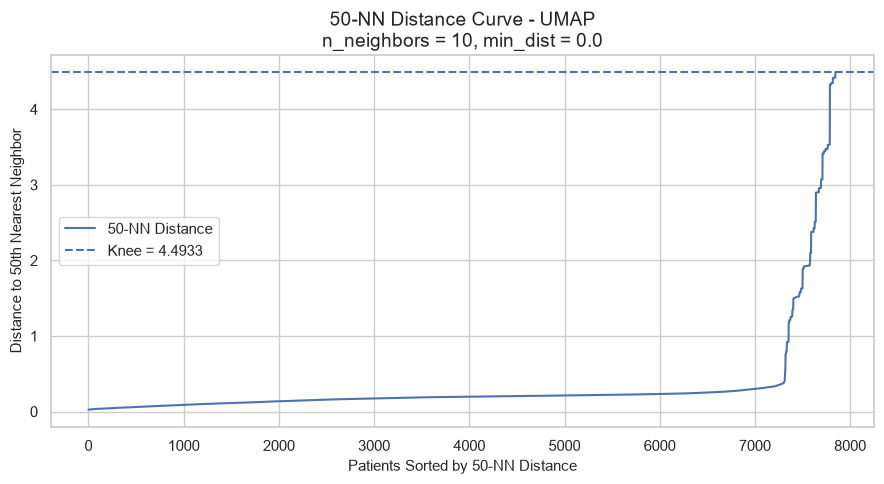

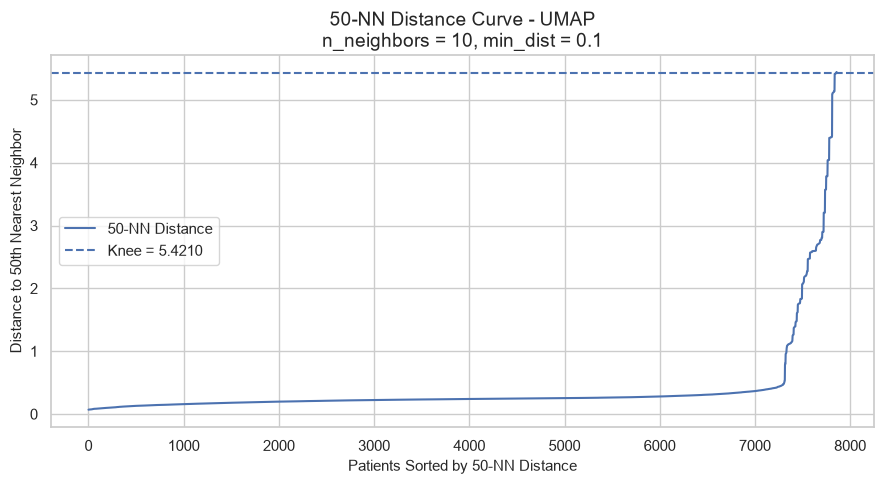

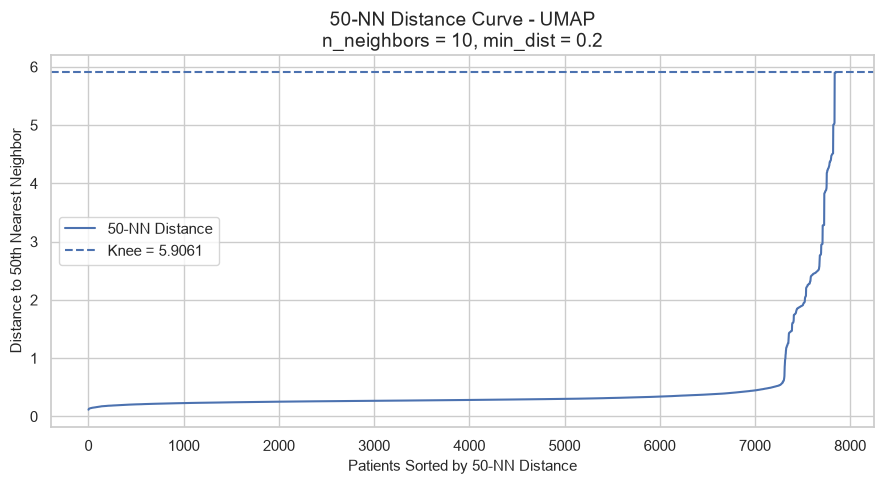

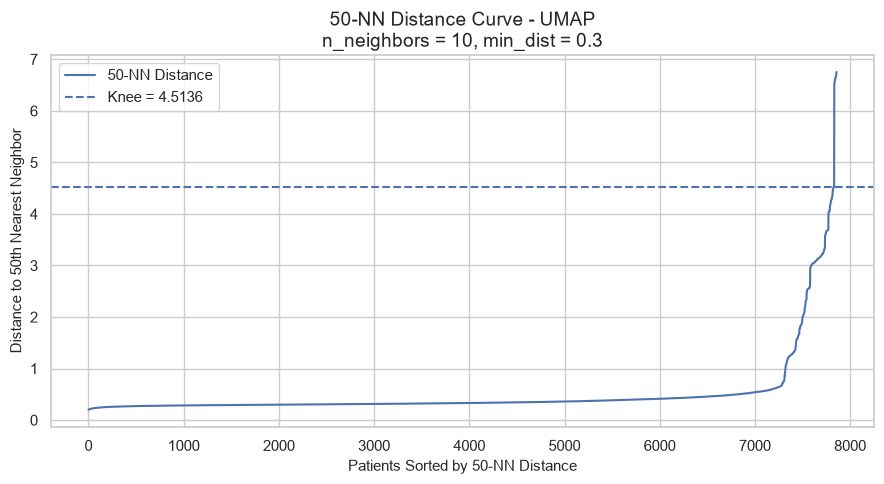

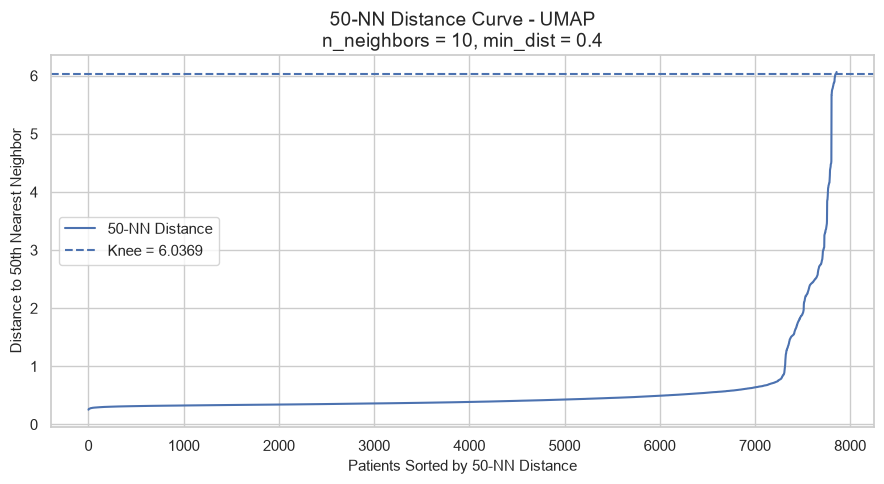

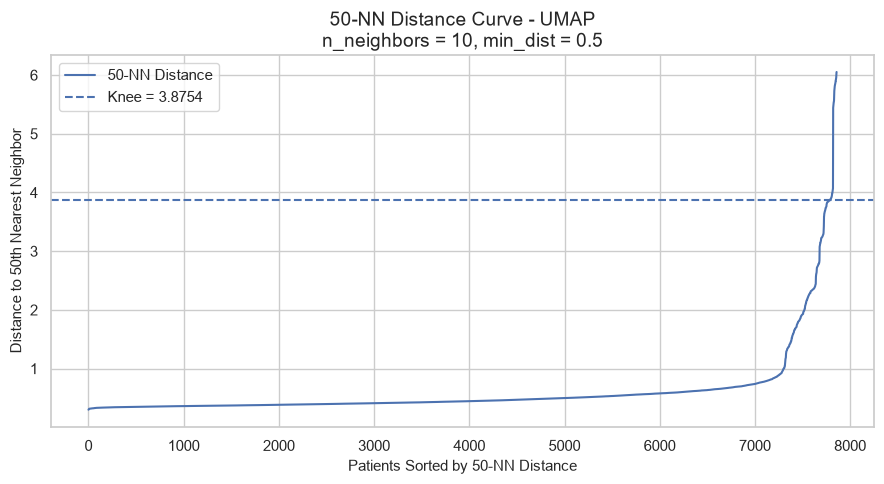

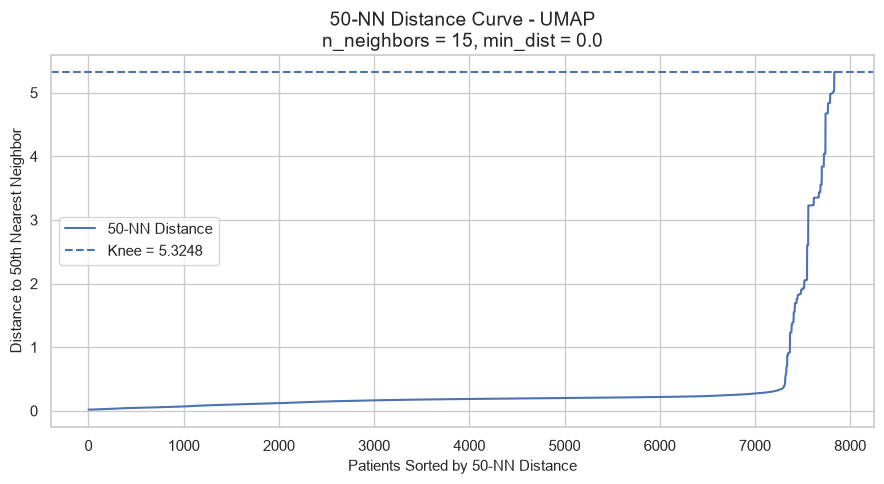

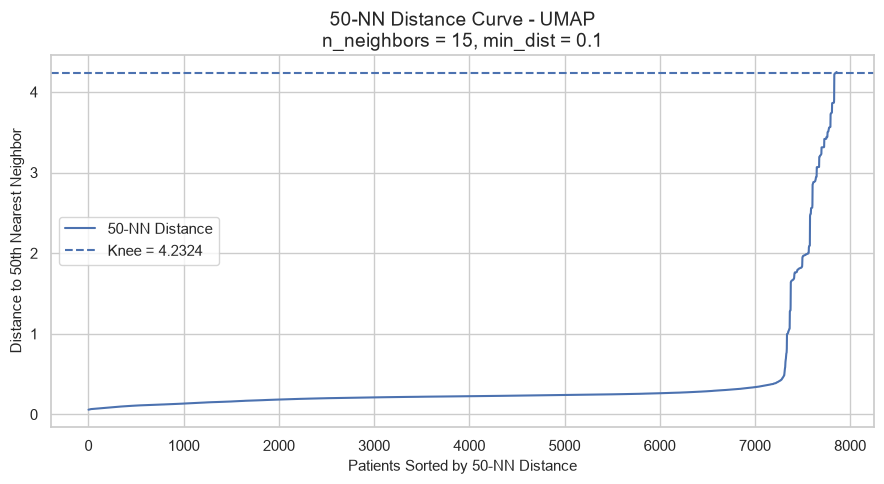

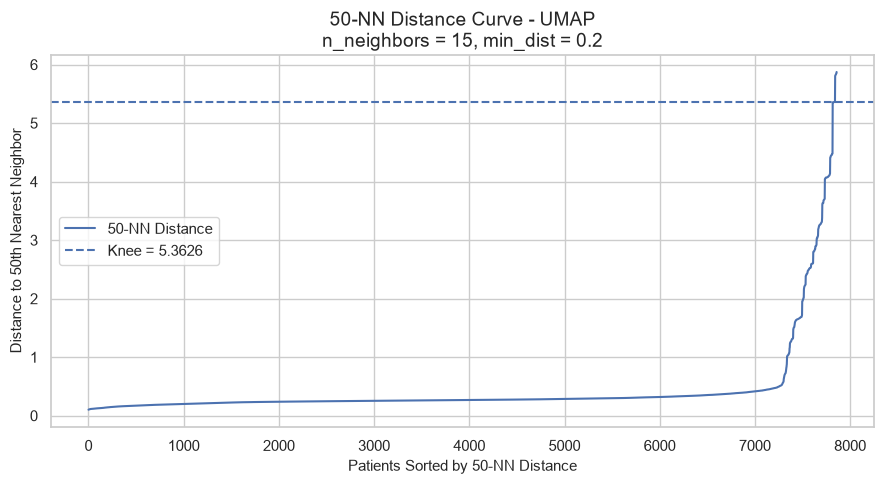

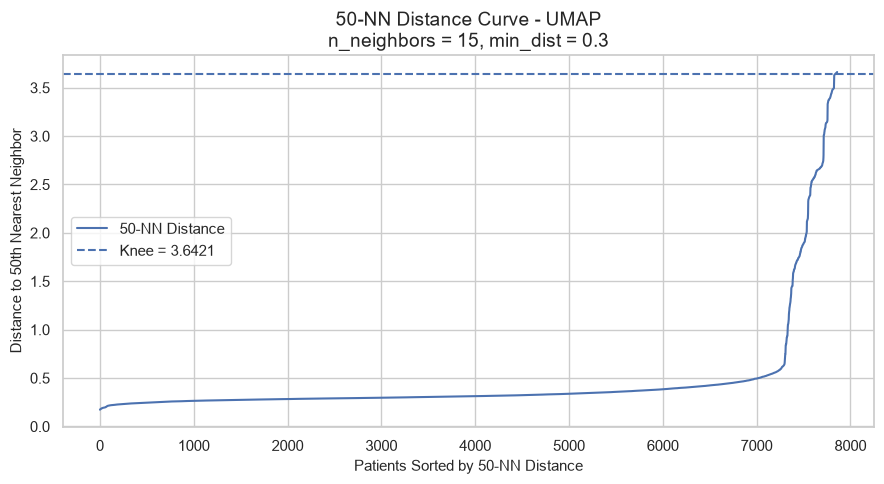

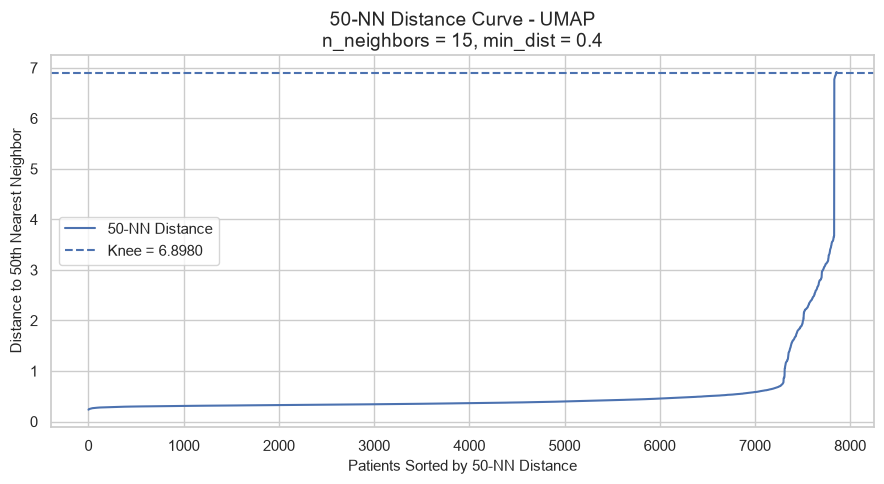

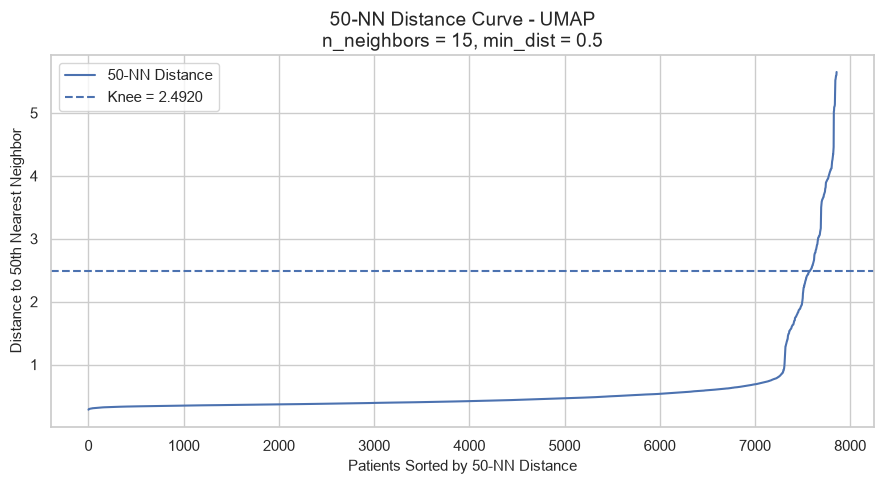

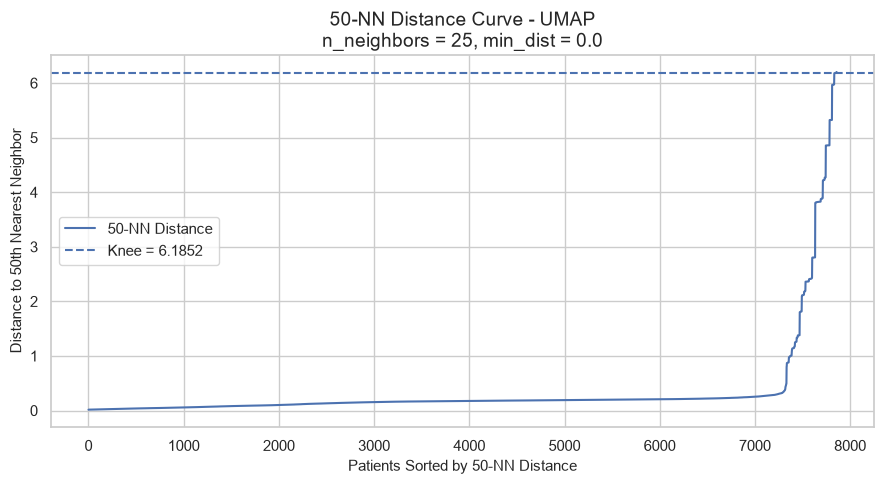

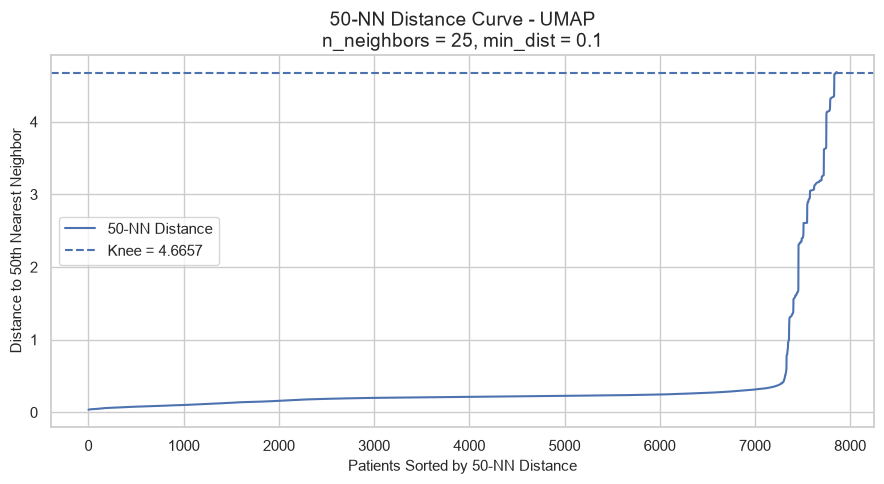

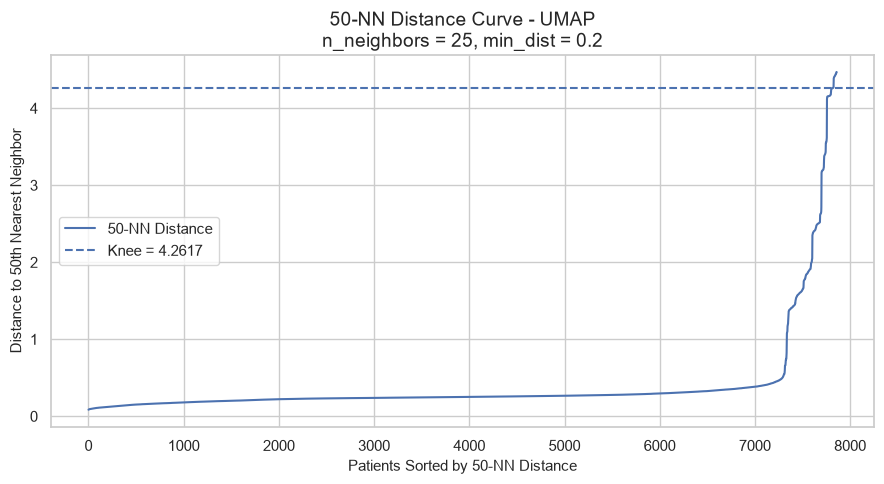

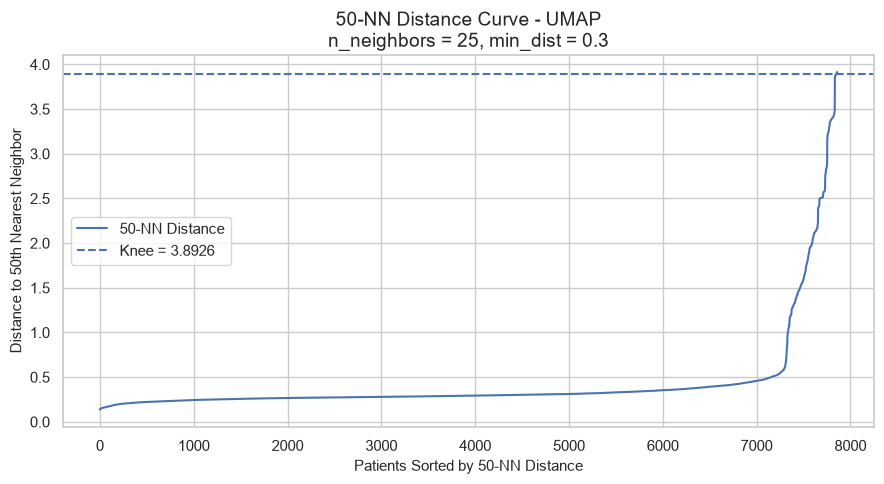

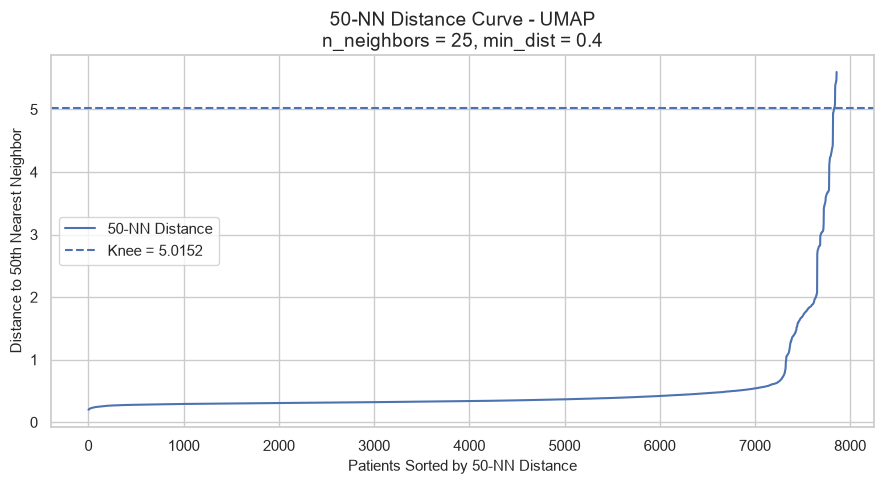

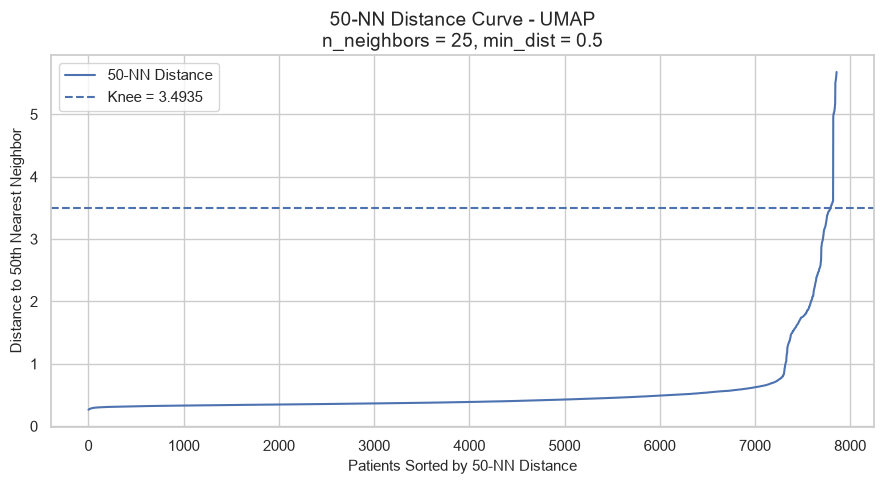

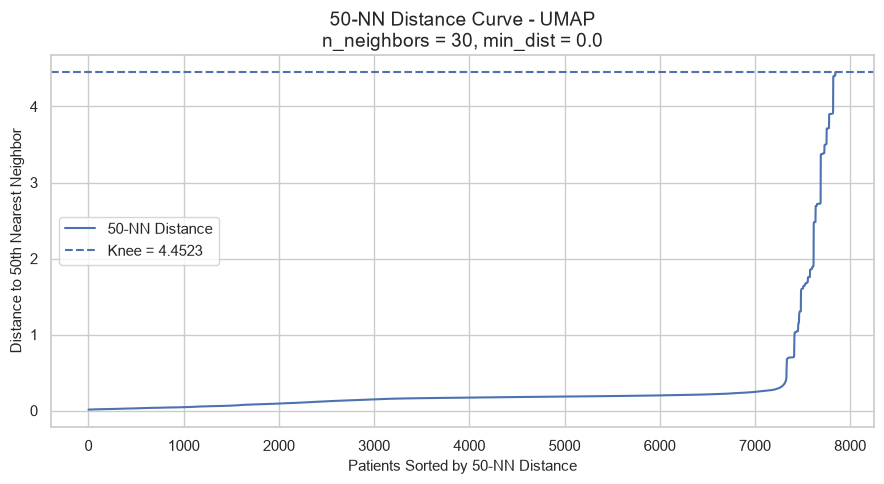

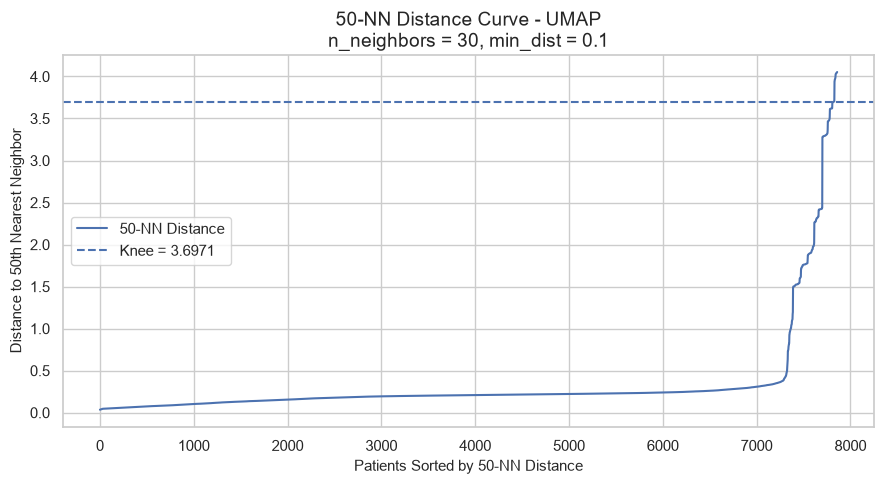

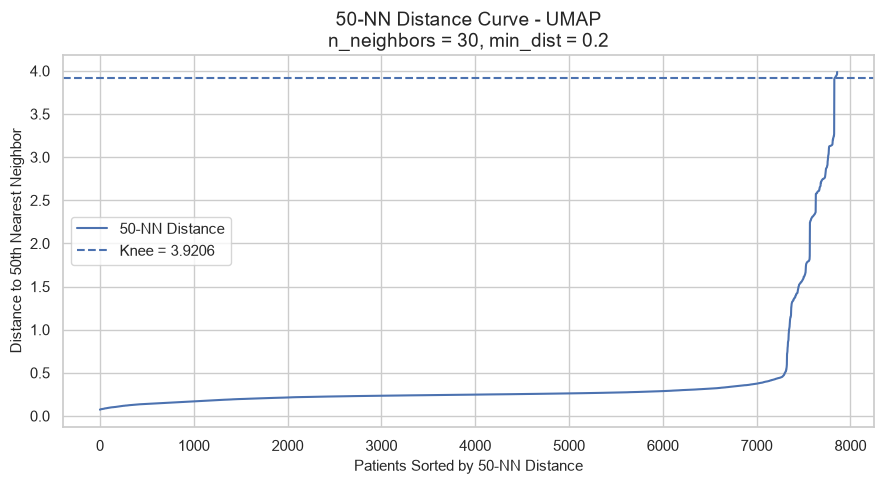

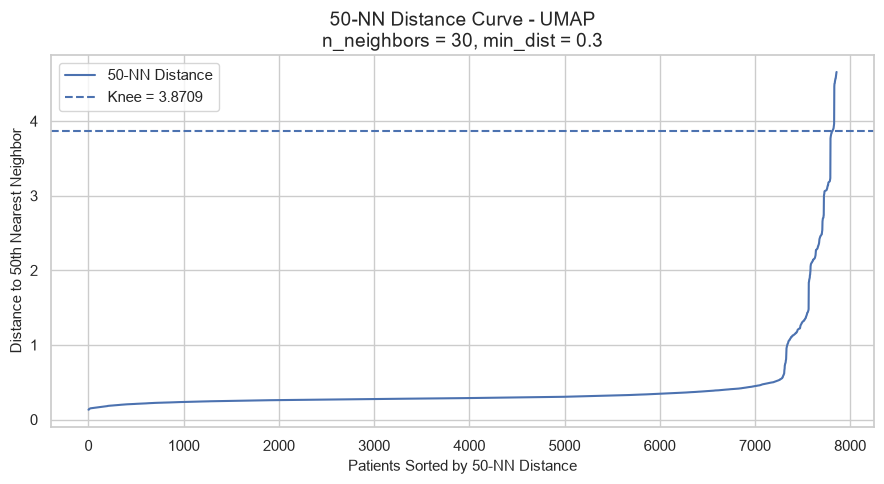

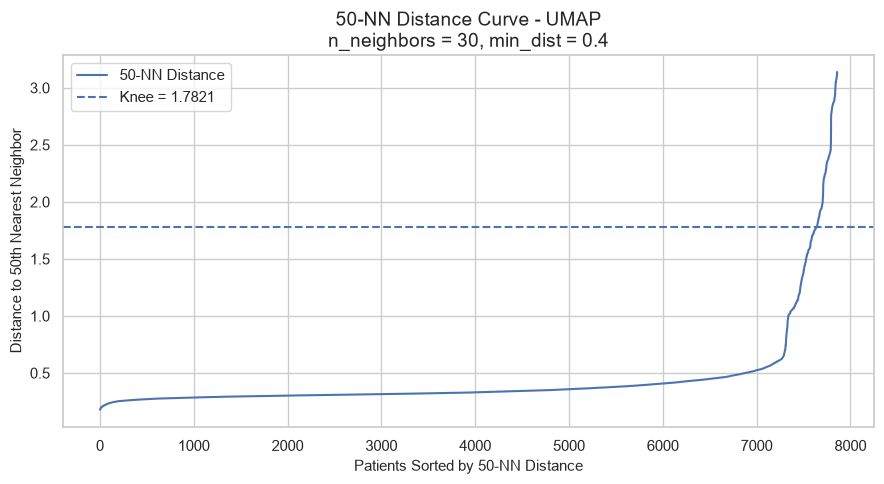

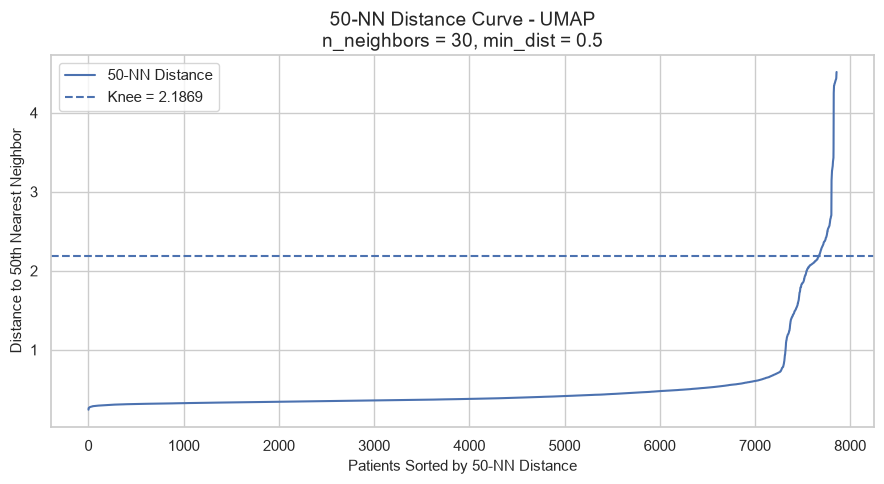

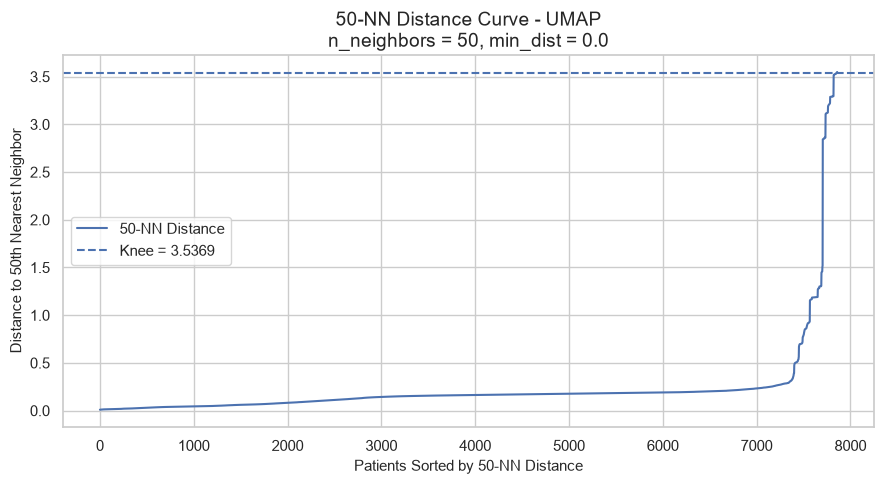

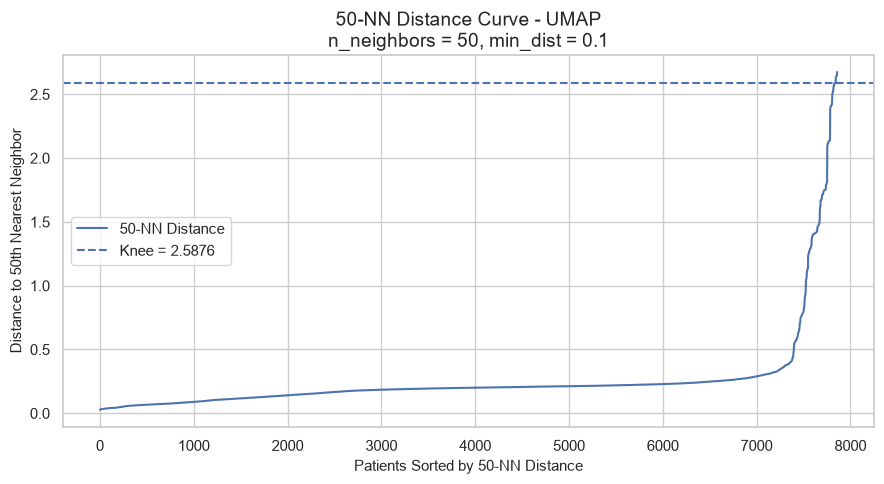

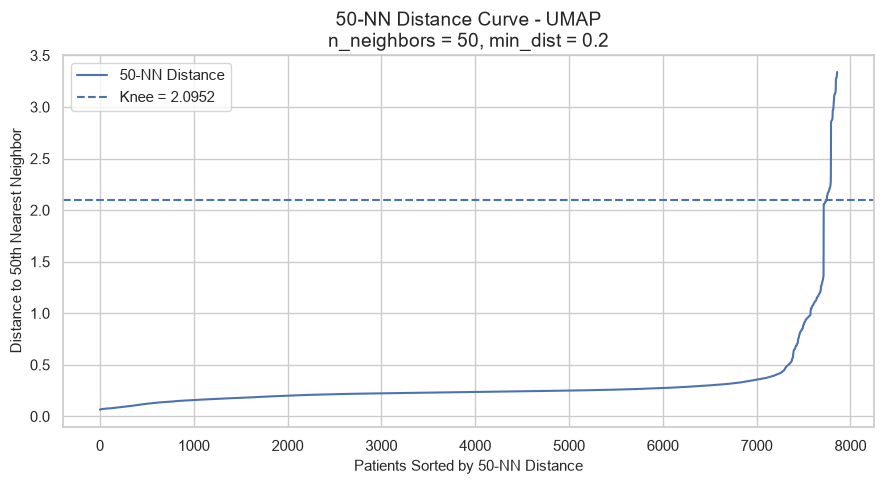

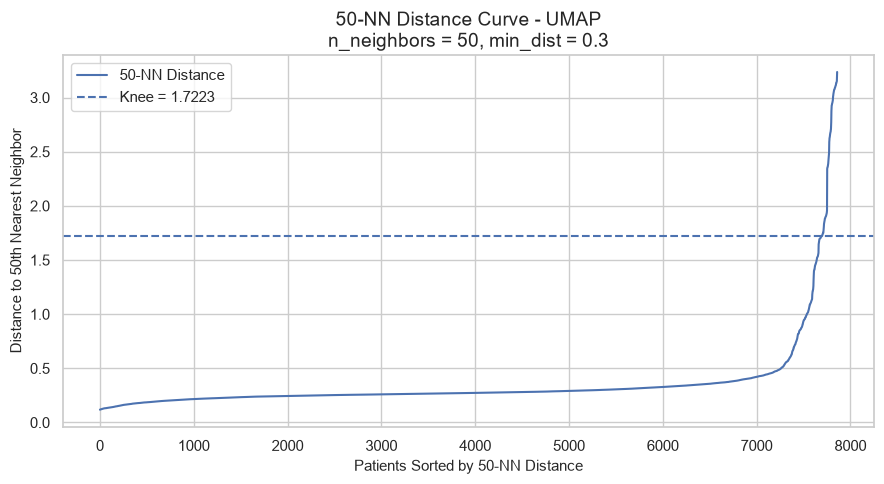

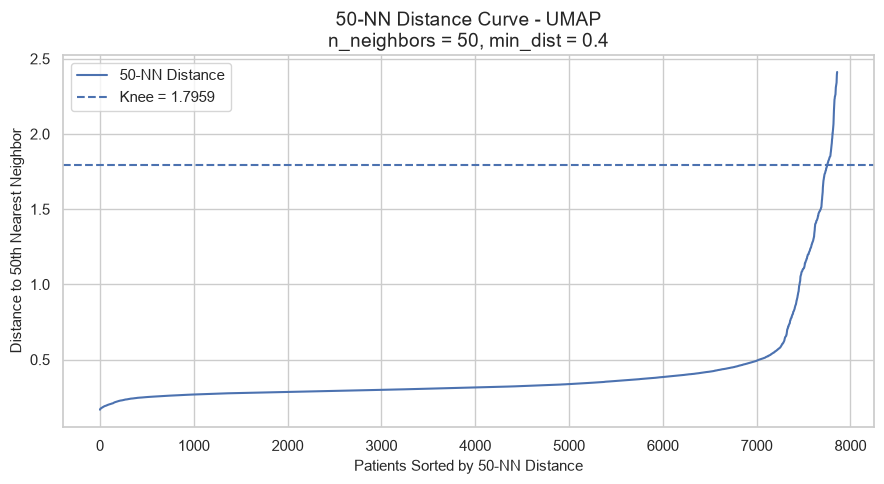

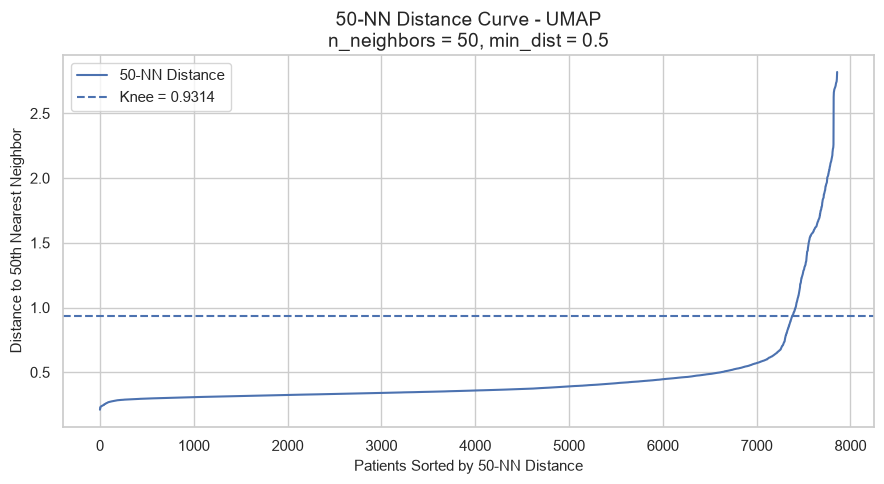

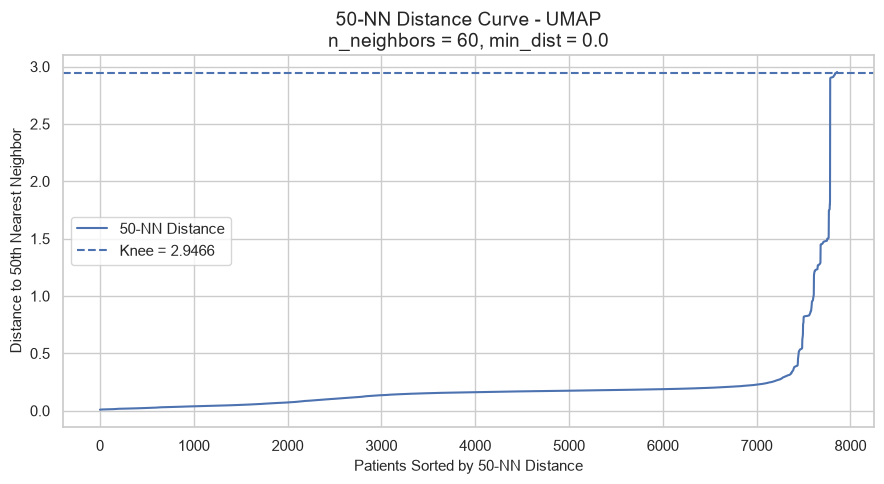

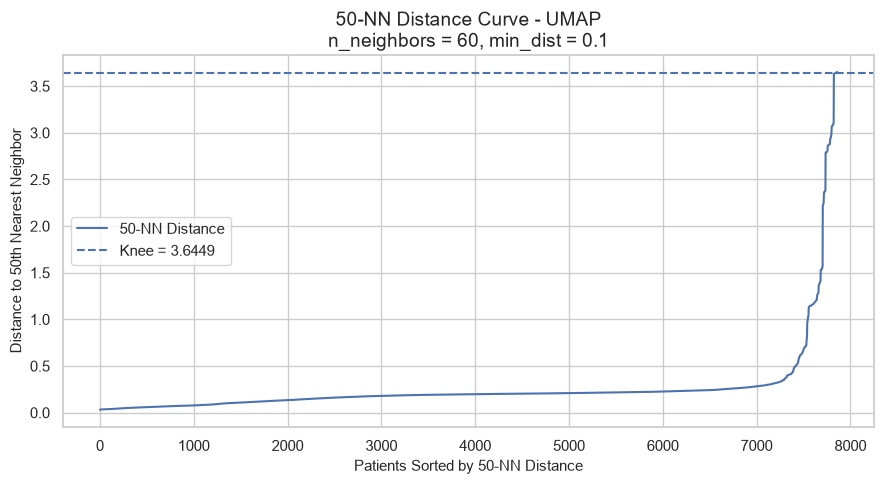

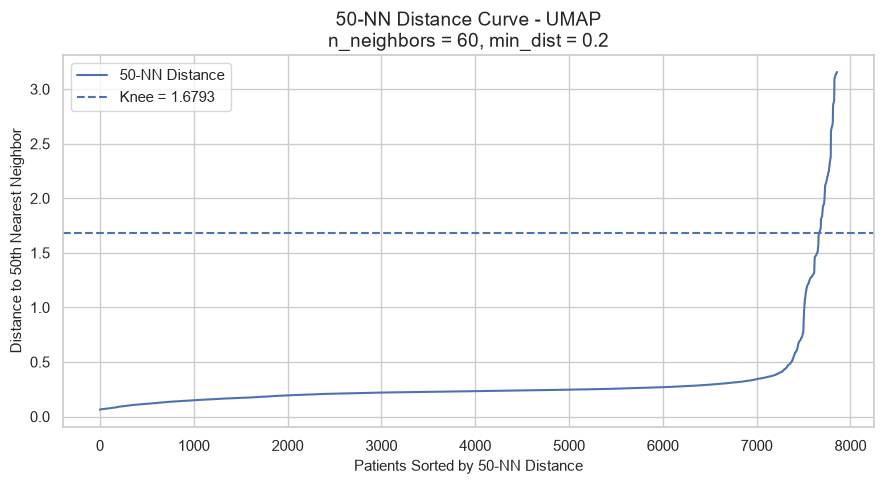

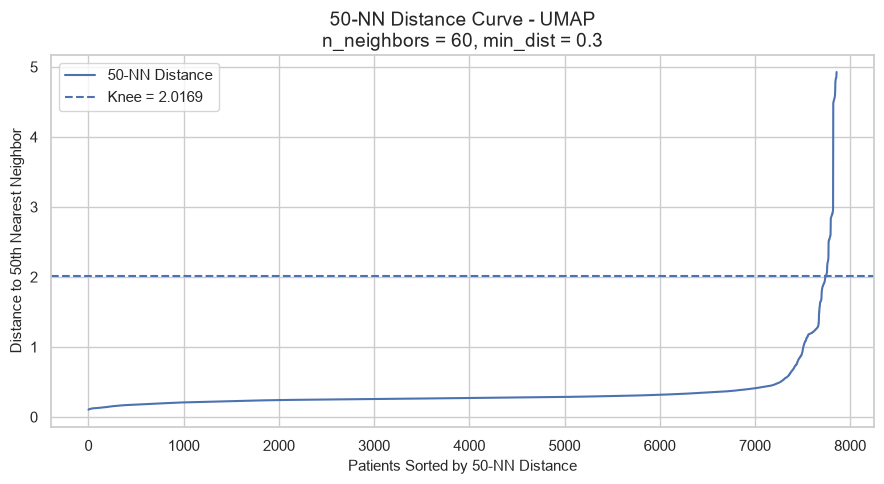

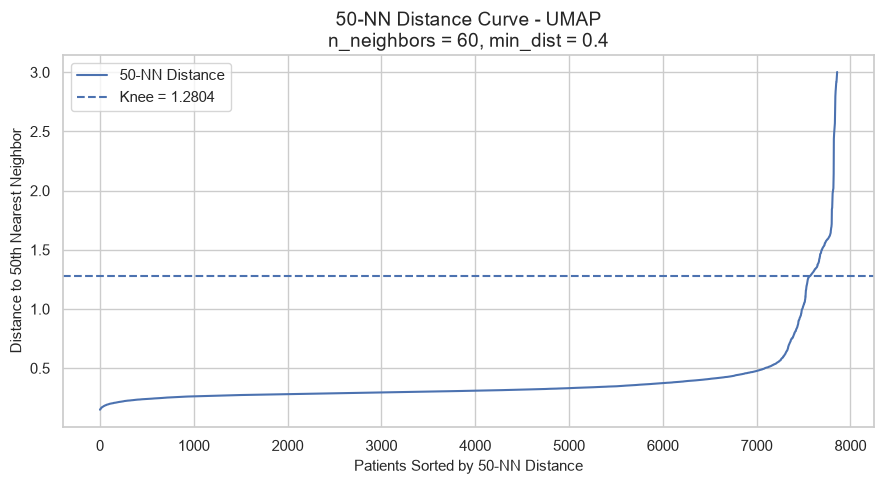

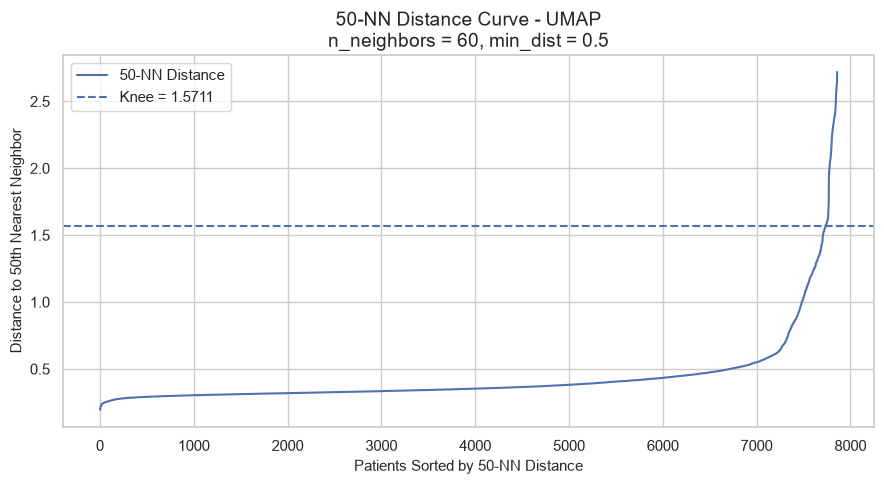

In [24]:
# ---------------------------------------------------------
# Plot 50-NN distance curve for each UMAP configuration
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        # Get sorted 50-NN distances
        k_distances = umap_knn_distances[
            (n_neighbors, min_dist)
        ]

        # Get detected knee value
        knee_value = umap_knee_values[
            (n_neighbors, min_dist)
        ]

        # X-axis values
        x_values = np.arange(len(k_distances))


        # -------------------------------------------------
        # Create plot
        # -------------------------------------------------

        plt.figure(figsize=(9, 5))

        sns.lineplot(
            x=x_values,
            y=k_distances,
            label="50-NN Distance"
        )


        # -------------------------------------------------
        # Add detected knee line
        # -------------------------------------------------

        if not np.isnan(knee_value):

            plt.axhline(
                y=knee_value,
                linestyle="--",
                label=f"Knee = {knee_value:.4f}"
            )


        # -------------------------------------------------
        # Plot formatting
        # -------------------------------------------------

        plt.title(
            f"50-NN Distance Curve - UMAP\n"
            f"n_neighbors = {n_neighbors}, min_dist = {min_dist}",
            fontsize=14
        )

        plt.xlabel(
            "Patients Sorted by 50-NN Distance",
            fontsize=11
        )

        plt.ylabel(
            "Distance to 50th Nearest Neighbor",
            fontsize=11
        )

        plt.legend()
        plt.tight_layout()


        # -------------------------------------------------
        # Save plot
        # -------------------------------------------------

        min_dist_name = str(min_dist).replace(".", "_")

        plot_file = (
            UMAP_PLOTS_DIR
            / (
                f"knn_curve_neighbors_{n_neighbors}"
                f"_mindist_{min_dist_name}.png"
            )
        )

        plt.savefig(
            plot_file,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

## Create DBSCAN Epsilon Candidates from the UMAP Knee Values

In [25]:
# ---------------------------------------------------------
# Store epsilon candidates for each UMAP configuration
# ---------------------------------------------------------

umap_epsilon_candidates = {}


# ---------------------------------------------------------
# Create epsilon values from each knee
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        knee_value = umap_knee_values[
            (n_neighbors, min_dist)
        ]

        # Skip if no knee was detected
        if np.isnan(knee_value):

            print(
                f"n_neighbors = {n_neighbors}, "
                f"min_dist = {min_dist}: No knee detected"
            )

            continue


        # -------------------------------------------------
        # Calculate epsilon candidates
        # -------------------------------------------------

        epsilon_values = [
            0.80 * knee_value,
            0.90 * knee_value,
            1.00 * knee_value
        ]


        # -------------------------------------------------
        # Store epsilon values
        # -------------------------------------------------

        umap_epsilon_candidates[
            (n_neighbors, min_dist)
        ] = epsilon_values


        # -------------------------------------------------
        # Display values
        # -------------------------------------------------

        print(
            f"\nn_neighbors = {n_neighbors}, "
            f"min_dist = {min_dist}"
        )

        print(f"Knee value = {knee_value:.4f}")

        print("Epsilon candidates:")

        for epsilon in epsilon_values:
            print(f"- {epsilon:.4f}")


n_neighbors = 10, min_dist = 0.0
Knee value = 4.4933
Epsilon candidates:
- 3.5946
- 4.0439
- 4.4933

n_neighbors = 10, min_dist = 0.1
Knee value = 5.4210
Epsilon candidates:
- 4.3368
- 4.8789
- 5.4210

n_neighbors = 10, min_dist = 0.2
Knee value = 5.9061
Epsilon candidates:
- 4.7249
- 5.3155
- 5.9061

n_neighbors = 10, min_dist = 0.3
Knee value = 4.5136
Epsilon candidates:
- 3.6109
- 4.0622
- 4.5136

n_neighbors = 10, min_dist = 0.4
Knee value = 6.0369
Epsilon candidates:
- 4.8295
- 5.4332
- 6.0369

n_neighbors = 10, min_dist = 0.5
Knee value = 3.8754
Epsilon candidates:
- 3.1003
- 3.4878
- 3.8754

n_neighbors = 15, min_dist = 0.0
Knee value = 5.3248
Epsilon candidates:
- 4.2598
- 4.7923
- 5.3248

n_neighbors = 15, min_dist = 0.1
Knee value = 4.2324
Epsilon candidates:
- 3.3860
- 3.8092
- 4.2324

n_neighbors = 15, min_dist = 0.2
Knee value = 5.3626
Epsilon candidates:
- 4.2901
- 4.8264
- 5.3626

n_neighbors = 15, min_dist = 0.3
Knee value = 3.6421
Epsilon candidates:
- 2.9136
- 3.2779

## Run DBSCAN for Every UMAP and Epsilon Combination

In [26]:
# ---------------------------------------------------------
# Store DBSCAN cluster labels
# ---------------------------------------------------------

umap_cluster_labels = {}


# ---------------------------------------------------------
# Run DBSCAN for every UMAP configuration
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        # Skip if no knee was detected
        if (n_neighbors, min_dist) not in umap_epsilon_candidates:
            continue

        # Get UMAP embedding
        embedding = umap_embeddings[
            (n_neighbors, min_dist)
        ]

        # Get epsilon candidates
        epsilon_values = umap_epsilon_candidates[
            (n_neighbors, min_dist)
        ]


        # -------------------------------------------------
        # Test each epsilon value
        # -------------------------------------------------

        for multiplier, epsilon in zip(
            EPSILON_MULTIPLIERS,
            epsilon_values
        ):

            print(
                f"Running DBSCAN: "
                f"n_neighbors = {n_neighbors}, "
                f"min_dist = {min_dist}, "
                f"epsilon = {epsilon:.4f}"
            )


            # -------------------------------------------------
            # Create DBSCAN model
            # -------------------------------------------------

            dbscan_model = DBSCAN(
                eps=epsilon,
                min_samples=DBSCAN_MIN_SAMPLES,
                metric="euclidean"
            )


            # -------------------------------------------------
            # Run clustering
            # -------------------------------------------------

            labels = dbscan_model.fit_predict(
                embedding
            )


            # -------------------------------------------------
            # Store cluster labels
            # -------------------------------------------------

            umap_cluster_labels[
                (n_neighbors, min_dist, multiplier)
            ] = labels


            # -------------------------------------------------
            # Create cluster assignment DataFrame
            # -------------------------------------------------

            cluster_df = pd.DataFrame({
                "patientunitstayid": patient_ids.values,
                "cluster": labels
            })


            # -------------------------------------------------
            # Prepare file name
            # -------------------------------------------------

            min_dist_name = str(min_dist).replace(".", "_")

            multiplier_name = int(
                multiplier * 100
            )


            # -------------------------------------------------
            # Save cluster assignments
            # -------------------------------------------------

            output_file = (
                UMAP_CLUSTER_DIR
                / (
                    f"umap_neighbors_{n_neighbors}"
                    f"_mindist_{min_dist_name}"
                    f"_eps_{multiplier_name}_percent_knee.csv"
                )
            )

            cluster_df.to_csv(
                output_file,
                index=False
            )

            print(f"Saved: {output_file.name}\n")


print("All UMAP + DBSCAN configurations completed.")

Running DBSCAN: n_neighbors = 10, min_dist = 0.0, epsilon = 3.5946
Saved: umap_neighbors_10_mindist_0_0_eps_80_percent_knee.csv

Running DBSCAN: n_neighbors = 10, min_dist = 0.0, epsilon = 4.0439
Saved: umap_neighbors_10_mindist_0_0_eps_90_percent_knee.csv

Running DBSCAN: n_neighbors = 10, min_dist = 0.0, epsilon = 4.4933
Saved: umap_neighbors_10_mindist_0_0_eps_100_percent_knee.csv

Running DBSCAN: n_neighbors = 10, min_dist = 0.1, epsilon = 4.3368
Saved: umap_neighbors_10_mindist_0_1_eps_80_percent_knee.csv

Running DBSCAN: n_neighbors = 10, min_dist = 0.1, epsilon = 4.8789
Saved: umap_neighbors_10_mindist_0_1_eps_90_percent_knee.csv

Running DBSCAN: n_neighbors = 10, min_dist = 0.1, epsilon = 5.4210
Saved: umap_neighbors_10_mindist_0_1_eps_100_percent_knee.csv

Running DBSCAN: n_neighbors = 10, min_dist = 0.2, epsilon = 4.7249
Saved: umap_neighbors_10_mindist_0_2_eps_80_percent_knee.csv

Running DBSCAN: n_neighbors = 10, min_dist = 0.2, epsilon = 5.3155
Saved: umap_neighbors_10_min

## Calculate and Save Cluster Statistics for Every UMAP Configuration

In [27]:
# ---------------------------------------------------------
# Store cluster statistics
# ---------------------------------------------------------

umap_cluster_statistics = []


# ---------------------------------------------------------
# Calculate statistics for every configuration
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        # Skip if no knee was detected
        if (n_neighbors, min_dist) not in umap_epsilon_candidates:
            continue

        epsilon_values = umap_epsilon_candidates[
            (n_neighbors, min_dist)
        ]


        for multiplier, epsilon in zip(
            EPSILON_MULTIPLIERS,
            epsilon_values
        ):

            # Get cluster labels
            labels = umap_cluster_labels[
                (n_neighbors, min_dist, multiplier)
            ]


            # -------------------------------------------------
            # Number of clusters
            # -------------------------------------------------

            unique_labels = np.unique(labels)

            # Remove -1 because it represents outliers
            cluster_labels = unique_labels[
                unique_labels != -1
            ]

            number_of_clusters = len(cluster_labels)


            # -------------------------------------------------
            # Outlier information
            # -------------------------------------------------

            number_of_outliers = np.sum(
                labels == -1
            )

            outlier_percentage = (
                number_of_outliers / len(labels)
            ) * 100


            # -------------------------------------------------
            # Smallest cluster size
            # -------------------------------------------------

            if number_of_clusters > 0:

                cluster_sizes = [
                    np.sum(labels == cluster)
                    for cluster in cluster_labels
                ]

                smallest_cluster_size = min(
                    cluster_sizes
                )

            else:

                smallest_cluster_size = 0


            # -------------------------------------------------
            # Store results
            # -------------------------------------------------

            umap_cluster_statistics.append({
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "epsilon_multiplier": multiplier,
                "epsilon": epsilon,
                "number_of_clusters": number_of_clusters,
                "number_of_outliers": number_of_outliers,
                "outlier_percentage": outlier_percentage,
                "smallest_cluster_size": smallest_cluster_size
            })


# ---------------------------------------------------------
# Convert results to DataFrame
# ---------------------------------------------------------

umap_cluster_statistics_df = pd.DataFrame(
    umap_cluster_statistics
)


# ---------------------------------------------------------
# Save cluster statistics
# ---------------------------------------------------------

cluster_statistics_file = (
    UMAP_CLUSTER_DIR
    / "umap_cluster_statistics.csv"
)

umap_cluster_statistics_df.to_csv(
    cluster_statistics_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("UMAP cluster statistics saved to:")
print(cluster_statistics_file)

display(umap_cluster_statistics_df)

UMAP cluster statistics saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\umap\umap_cluster_statistics.csv


,n_neighbors,min_dist,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size
0,10,0.0,0.8,3.594605,12,41,0.521695,67
1,10,0.0,0.9,4.043930,9,41,0.521695,175
2,10,0.0,1.0,4.493256,8,0,0.000000,175
3,10,0.1,0.8,4.336795,4,26,0.330831,175
4,10,0.1,0.9,4.878895,4,26,0.330831,175
...,...,...,...,...,...,...,...,...
103,60,0.4,0.9,1.152348,18,177,2.252195,58
104,60,0.4,1.0,1.280387,16,72,0.916147,58
105,60,0.5,0.8,1.256878,15,90,1.145184,64
106,60,0.5,0.9,1.413987,13,90,1.145184,64


## Calculate and Save Internal Clustering Metrics

In [28]:
# ---------------------------------------------------------
# Store internal metric results
# ---------------------------------------------------------

umap_metric_results = []


# ---------------------------------------------------------
# Calculate metrics for every configuration
# ---------------------------------------------------------

for n_neighbors in umap_n_neighbors:

    for min_dist in umap_min_dist:

        # Skip if no knee was detected
        if (n_neighbors, min_dist) not in umap_epsilon_candidates:
            continue

        epsilon_values = umap_epsilon_candidates[
            (n_neighbors, min_dist)
        ]


        for multiplier, epsilon in zip(
            EPSILON_MULTIPLIERS,
            epsilon_values
        ):

            # Get embedding and cluster labels
            embedding = umap_embeddings[
                (n_neighbors, min_dist)
            ]

            labels = umap_cluster_labels[
                (n_neighbors, min_dist, multiplier)
            ]


            # -------------------------------------------------
            # Remove DBSCAN outliers
            # -------------------------------------------------

            non_outlier_mask = labels != -1

            embedding_clean = embedding[non_outlier_mask]
            labels_clean = labels[non_outlier_mask]


            # -------------------------------------------------
            # Count remaining clusters
            # -------------------------------------------------

            number_of_clusters = len(
                np.unique(labels_clean)
            )


            # -------------------------------------------------
            # Calculate internal metrics
            # -------------------------------------------------

            if number_of_clusters >= 2:

                silhouette = silhouette_score(
                    embedding_clean,
                    labels_clean
                )

                davies_bouldin = davies_bouldin_score(
                    embedding_clean,
                    labels_clean
                )

                calinski_harabasz = calinski_harabasz_score(
                    embedding_clean,
                    labels_clean
                )

            else:

                silhouette = np.nan
                davies_bouldin = np.nan
                calinski_harabasz = np.nan


            # -------------------------------------------------
            # Store results
            # -------------------------------------------------

            umap_metric_results.append({
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "epsilon_multiplier": multiplier,
                "epsilon": epsilon,
                "silhouette_score": silhouette,
                "davies_bouldin_index": davies_bouldin,
                "calinski_harabasz_index": calinski_harabasz
            })


# ---------------------------------------------------------
# Convert results to DataFrame
# ---------------------------------------------------------

umap_metric_results_df = pd.DataFrame(
    umap_metric_results
)


# ---------------------------------------------------------
# Save internal metrics table
# ---------------------------------------------------------

metric_results_file = (
    UMAP_CLUSTER_DIR
    / "umap_internal_metrics.csv"
)

umap_metric_results_df.to_csv(
    metric_results_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("UMAP internal metrics saved to:")
print(metric_results_file)

display(umap_metric_results_df)

UMAP internal metrics saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\umap\umap_internal_metrics.csv


,n_neighbors,min_dist,epsilon_multiplier,epsilon,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,10,0.0,0.8,3.594605,0.723390,0.571512,16022.401997
1,10,0.0,0.9,4.043930,0.630662,0.546109,9743.977236
2,10,0.0,1.0,4.493256,0.585190,0.540371,8612.849947
3,10,0.1,0.8,4.336795,0.561288,0.565593,7211.849078
4,10,0.1,0.9,4.878895,0.561288,0.565593,7211.849078
...,...,...,...,...,...,...,...
103,60,0.4,0.9,1.152348,0.812815,0.386587,100608.984882
104,60,0.4,1.0,1.280387,0.741243,0.538237,78349.634808
105,60,0.5,0.8,1.256878,0.745645,0.488753,76444.236832
106,60,0.5,0.9,1.413987,0.731066,0.456742,78575.966687


In [29]:
# ---------------------------------------------------------
# Combine cluster statistics and internal metrics
# ---------------------------------------------------------

umap_tuning_results = pd.merge(
    umap_cluster_statistics_df,
    umap_metric_results_df,
    on=[
        "n_neighbors",
        "min_dist",
        "epsilon_multiplier",
        "epsilon"
    ]
)


# ---------------------------------------------------------
# Save complete UMAP tuning results
# ---------------------------------------------------------

tuning_results_file = (
    UMAP_RESULTS_DIR
    / "umap_hyperparameter_tuning_results.csv"
)

umap_tuning_results.to_csv(
    tuning_results_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("Complete UMAP tuning results saved to:")
print(tuning_results_file)

display(umap_tuning_results)

Complete UMAP tuning results saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\umap\umap_hyperparameter_tuning_results.csv


,n_neighbors,min_dist,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,10,0.0,0.8,3.594605,12,41,0.521695,67,0.723390,0.571512,16022.401997
1,10,0.0,0.9,4.043930,9,41,0.521695,175,0.630662,0.546109,9743.977236
2,10,0.0,1.0,4.493256,8,0,0.000000,175,0.585190,0.540371,8612.849947
3,10,0.1,0.8,4.336795,4,26,0.330831,175,0.561288,0.565593,7211.849078
4,10,0.1,0.9,4.878895,4,26,0.330831,175,0.561288,0.565593,7211.849078
...,...,...,...,...,...,...,...,...,...,...,...
103,60,0.4,0.9,1.152348,18,177,2.252195,58,0.812815,0.386587,100608.984882
104,60,0.4,1.0,1.280387,16,72,0.916147,58,0.741243,0.538237,78349.634808
105,60,0.5,0.8,1.256878,15,90,1.145184,64,0.745645,0.488753,76444.236832
106,60,0.5,0.9,1.413987,13,90,1.145184,64,0.731066,0.456742,78575.966687


## Apply Validity Conditions

In [30]:
# ---------------------------------------------------------
# Apply validity conditions
# ---------------------------------------------------------

umap_tuning_results["valid_model"] = (

    # At least 2 clusters
    (umap_tuning_results["number_of_clusters"] >= 2)

    &

    # Outlier percentage must be 5% or less
    (umap_tuning_results["outlier_percentage"] <= 5)

    &

    # Smallest cluster must contain at least 50 patients
    (umap_tuning_results["smallest_cluster_size"] >= 50)

    &

    # Internal metrics must be available
    (umap_tuning_results["silhouette_score"].notna())

    &

    (umap_tuning_results["davies_bouldin_index"].notna())

    &

    (umap_tuning_results["calinski_harabasz_index"].notna())
)


# ---------------------------------------------------------
# Keep only valid models
# ---------------------------------------------------------

umap_valid_models = umap_tuning_results[
    umap_tuning_results["valid_model"]
].copy()


# ---------------------------------------------------------
# Display summary
# ---------------------------------------------------------

print("Total configurations:",
      len(umap_tuning_results))

print("Valid configurations:",
      len(umap_valid_models))

print("Invalid configurations:",
      len(umap_tuning_results) - len(umap_valid_models))


print("\nValid UMAP + DBSCAN configurations:")

display(umap_valid_models)

Total configurations: 108
Valid configurations: 105
Invalid configurations: 3

Valid UMAP + DBSCAN configurations:


,n_neighbors,min_dist,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,valid_model
0,10,0.0,0.8,3.594605,12,41,0.521695,67,0.723390,0.571512,16022.401997,True
1,10,0.0,0.9,4.043930,9,41,0.521695,175,0.630662,0.546109,9743.977236,True
2,10,0.0,1.0,4.493256,8,0,0.000000,175,0.585190,0.540371,8612.849947,True
3,10,0.1,0.8,4.336795,4,26,0.330831,175,0.561288,0.565593,7211.849078,True
4,10,0.1,0.9,4.878895,4,26,0.330831,175,0.561288,0.565593,7211.849078,True
...,...,...,...,...,...,...,...,...,...,...,...,...
103,60,0.4,0.9,1.152348,18,177,2.252195,58,0.812815,0.386587,100608.984882,True
104,60,0.4,1.0,1.280387,16,72,0.916147,58,0.741243,0.538237,78349.634808,True
105,60,0.5,0.8,1.256878,15,90,1.145184,64,0.745645,0.488753,76444.236832,True
106,60,0.5,0.9,1.413987,13,90,1.145184,64,0.731066,0.456742,78575.966687,True


## Rank the Valid UMAP + DBSCAN Models

In [31]:
# ---------------------------------------------------------
# Rank valid models using the three internal metrics
# ---------------------------------------------------------

umap_valid_models["silhouette_rank"] = (
    umap_valid_models["silhouette_score"]
    .rank(ascending=False, method="min")
)

umap_valid_models["davies_bouldin_rank"] = (
    umap_valid_models["davies_bouldin_index"]
    .rank(ascending=True, method="min")
)

umap_valid_models["calinski_harabasz_rank"] = (
    umap_valid_models["calinski_harabasz_index"]
    .rank(ascending=False, method="min")
)


# ---------------------------------------------------------
# Calculate combined rank
# ---------------------------------------------------------

umap_valid_models["combined_rank"] = (
    umap_valid_models["silhouette_rank"]
    + umap_valid_models["davies_bouldin_rank"]
    + umap_valid_models["calinski_harabasz_rank"]
)


# ---------------------------------------------------------
# Sort models from best to worst
# ---------------------------------------------------------

umap_ranked_models = umap_valid_models.sort_values(
    by=[
        "combined_rank",
        "outlier_percentage",
        "silhouette_score"
    ],
    ascending=[
        True,   # Lower combined rank is better
        True,   # Lower outlier percentage is better
        False   # Higher silhouette is better
    ]
).reset_index(drop=True)


# ---------------------------------------------------------
# Display ranked models
# ---------------------------------------------------------

display(
    umap_ranked_models[
        [
            "n_neighbors",
            "min_dist",
            "epsilon_multiplier",
            "epsilon",
            "number_of_clusters",
            "outlier_percentage",
            "smallest_cluster_size",
            "silhouette_score",
            "davies_bouldin_index",
            "calinski_harabasz_index",
            "silhouette_rank",
            "davies_bouldin_rank",
            "calinski_harabasz_rank",
            "combined_rank"
        ]
    ]
)

,n_neighbors,min_dist,epsilon_multiplier,epsilon,number_of_clusters,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,silhouette_rank,davies_bouldin_rank,calinski_harabasz_rank,combined_rank
0,60,0.0,0.9,2.651944,17,0.967044,58,0.897240,0.241929,204514.361714,1.0,2.0,2.0,5.0
1,60,0.0,0.8,2.357283,18,0.967044,58,0.889677,0.260825,220897.653799,3.0,4.0,1.0,8.0
2,60,0.0,1.0,2.946604,17,0.000000,58,0.893110,0.282038,186673.027424,2.0,8.0,3.0,13.0
3,60,0.2,0.8,1.343435,19,2.252195,68,0.877195,0.261322,117685.581627,4.0,5.0,5.0,14.0
4,50,0.1,0.8,2.070059,16,0.967044,94,0.834981,0.316653,118350.180749,8.0,12.0,4.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,15,0.1,0.9,3.809198,7,0.000000,175,0.572967,0.913386,5271.210993,79.0,105.0,103.0,287.0
101,15,0.1,1.0,4.232442,6,0.000000,175,0.530903,0.668758,5107.408293,96.0,101.0,105.0,302.0
102,10,0.4,0.8,4.829520,2,0.699835,2195,0.429408,0.674658,5648.028201,103.0,102.0,100.0,305.0
103,10,0.4,0.9,5.433210,2,0.687110,2195,0.429260,0.674844,5644.340004,104.0,103.0,101.0,308.0


## Save Ranked Models and Select the Best UMAP + DBSCAN Configuration

In [32]:
# ---------------------------------------------------------
# Save ranked UMAP models
# ---------------------------------------------------------

ranked_results_file = (
    UMAP_RESULTS_DIR
    / "umap_ranked_models.csv"
)

umap_ranked_models.to_csv(
    ranked_results_file,
    index=False
)


# ---------------------------------------------------------
# Select the best model
# ---------------------------------------------------------

best_umap_model = umap_ranked_models.iloc[0]


# ---------------------------------------------------------
# Display the best configuration
# ---------------------------------------------------------

print("Best UMAP + DBSCAN Configuration")
print("=" * 50)

print("n_neighbors:",
      int(best_umap_model["n_neighbors"]))

print("min_dist:",
      best_umap_model["min_dist"])

print("Epsilon multiplier:",
      best_umap_model["epsilon_multiplier"])

print("Epsilon:",
      round(best_umap_model["epsilon"], 4))

print("Number of clusters:",
      int(best_umap_model["number_of_clusters"]))

print("Number of outliers:",
      int(best_umap_model["number_of_outliers"]))

print("Outlier percentage:",
      round(best_umap_model["outlier_percentage"], 4))

print("Smallest cluster size:",
      int(best_umap_model["smallest_cluster_size"]))

print("\nInternal metrics:")

print("Silhouette Score:",
      round(best_umap_model["silhouette_score"], 4))

print("Davies-Bouldin Index:",
      round(best_umap_model["davies_bouldin_index"], 4))

print("Calinski-Harabasz Index:",
      round(best_umap_model["calinski_harabasz_index"], 4))

print("\nCombined Rank:",
      best_umap_model["combined_rank"])

print("\nRanked models saved to:")
print(ranked_results_file)

Best UMAP + DBSCAN Configuration
n_neighbors: 60
min_dist: 0.0
Epsilon multiplier: 0.9
Epsilon: 2.6519
Number of clusters: 17
Number of outliers: 76
Outlier percentage: 0.967
Smallest cluster size: 58

Internal metrics:
Silhouette Score: 0.8972
Davies-Bouldin Index: 0.2419
Calinski-Harabasz Index: 204514.3617

Combined Rank: 5.0

Ranked models saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\umap\umap_ranked_models.csv


# Variational Autoencoder + DBSCAN Hyperparameter Tuning

## Define VAE Hyperparameter Search Settings

In [33]:
# ---------------------------------------------------------
# VAE hidden-layer architectures to test
# ---------------------------------------------------------

vae_hidden_configs = [
    (128, 64),
    (256, 128)
]


# ---------------------------------------------------------
# Learning rates to test
# ---------------------------------------------------------

vae_learning_rates = [
    0.0001,
    0.0002,
    0.0003,
    0.0004,
    0.0005,
    0.0006,
    0.0007,
    0.0008,
    0.0009,
    0.0010
]


# ---------------------------------------------------------
# Beta values to test
# Controls the KL-divergence contribution
# ---------------------------------------------------------

vae_beta_values = [
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25
]


# ---------------------------------------------------------
# Fixed VAE settings
# ---------------------------------------------------------

VAE_LATENT_DIM = 2
VAE_BATCH_SIZE = 128
VAE_EPOCHS = 100


# ---------------------------------------------------------
# Display tuning settings
# ---------------------------------------------------------

print("VAE + DBSCAN Hyperparameter Settings")
print("=" * 50)

print("\nHidden-layer architectures:")
print(vae_hidden_configs)

print("\nLearning rates:")
print(vae_learning_rates)

print("\nBeta values:")
print(vae_beta_values)

print("\nFixed VAE settings:")
print("Latent dimensions:", VAE_LATENT_DIM)
print("Batch size:", VAE_BATCH_SIZE)
print("Epochs:", VAE_EPOCHS)
print("Random seed:", RANDOM_STATE)

print("\nFixed DBSCAN settings:")
print("Minimum samples:", DBSCAN_MIN_SAMPLES)
print("Epsilon multipliers:", EPSILON_MULTIPLIERS)

VAE + DBSCAN Hyperparameter Settings

Hidden-layer architectures:
[(128, 64), (256, 128)]

Learning rates:
[0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001]

Beta values:
[0.01, 0.05, 0.1, 0.15, 0.2, 0.25]

Fixed VAE settings:
Latent dimensions: 2
Batch size: 128
Epochs: 100
Random seed: 42

Fixed DBSCAN settings:
Minimum samples: 50
Epsilon multipliers: [0.8, 0.9, 1.0]


## Prepare the Dataset for VAE Training

In [34]:
# ---------------------------------------------------------
# Set random seeds for reproducibility
# ---------------------------------------------------------

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


# ---------------------------------------------------------
# Convert clustering matrix to PyTorch tensor
# ---------------------------------------------------------

X_tensor = torch.tensor(
    X.to_numpy(),
    dtype=torch.float32
)


# ---------------------------------------------------------
# Create PyTorch dataset
# ---------------------------------------------------------

vae_dataset = TensorDataset(X_tensor)


# ---------------------------------------------------------
# Create DataLoader
# ---------------------------------------------------------

vae_loader = DataLoader(
    vae_dataset,
    batch_size=VAE_BATCH_SIZE,
    shuffle=True
)


# ---------------------------------------------------------
# Display dataset information
# ---------------------------------------------------------

print("VAE Input Dataset")
print("=" * 50)

print("Number of patients:", X_tensor.shape[0])
print("Number of input features:", X_tensor.shape[1])
print("Batch size:", VAE_BATCH_SIZE)

print("\nTensor shape:")
print(X_tensor.shape)

print("\nNumber of training batches:")
print(len(vae_loader))

VAE Input Dataset
Number of patients: 7859
Number of input features: 80
Batch size: 128

Tensor shape:
torch.Size([7859, 80])

Number of training batches:
62


## Define the Variational Autoencoder Architecture

In [35]:
# ---------------------------------------------------------
# Define Variational Autoencoder
# ---------------------------------------------------------

class VAE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dims,
        latent_dim=2
    ):

        super().__init__()

        # Get the two hidden-layer sizes
        hidden_1, hidden_2 = hidden_dims


        # -------------------------------------------------
        # Encoder
        # -------------------------------------------------

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),

            nn.Linear(hidden_1, hidden_2),
            nn.ReLU()
        )


        # -------------------------------------------------
        # Latent mean and log variance
        # -------------------------------------------------

        self.mu_layer = nn.Linear(
            hidden_2,
            latent_dim
        )

        self.logvar_layer = nn.Linear(
            hidden_2,
            latent_dim
        )


        # -------------------------------------------------
        # Decoder
        # -------------------------------------------------

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_2),
            nn.ReLU(),

            nn.Linear(hidden_2, hidden_1),
            nn.ReLU(),

            nn.Linear(hidden_1, input_dim),
            nn.Sigmoid()
        )


    # -----------------------------------------------------
    # Encode input data
    # -----------------------------------------------------

    def encode(self, x):

        encoded = self.encoder(x)

        mu = self.mu_layer(encoded)
        logvar = self.logvar_layer(encoded)

        return mu, logvar


    # -----------------------------------------------------
    # Reparameterization
    # -----------------------------------------------------

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        epsilon = torch.randn_like(std)

        z = mu + epsilon * std

        return z


    # -----------------------------------------------------
    # Forward pass
    # -----------------------------------------------------

    def forward(self, x):

        # Encode
        mu, logvar = self.encode(x)

        # Sample latent representation
        z = self.reparameterize(
            mu,
            logvar
        )

        # Reconstruct input
        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar

## Define the VAE Loss Function

In [36]:
# ---------------------------------------------------------
# Define VAE loss function
# ---------------------------------------------------------

def vae_loss(
    reconstructed,
    original,
    mu,
    logvar,
    beta
):

    # Reconstruction loss
    reconstruction_loss = nn.functional.mse_loss(
        reconstructed,
        original,
        reduction="sum"
    )

    # KL-divergence loss
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Total VAE loss
    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )

    return total_loss

## Train VAE Models and Save the 2D Latent Embeddings

In [37]:
# ---------------------------------------------------------
# Select training device
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", device)


# ---------------------------------------------------------
# Store VAE embeddings and training results
# ---------------------------------------------------------

vae_embeddings = {}
vae_training_results = []


# ---------------------------------------------------------
# Train every VAE configuration
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            print(
                f"\nTraining VAE: "
                f"hidden = {hidden_dims}, "
                f"learning rate = {learning_rate}, "
                f"beta = {beta}"
            )


            # -------------------------------------------------
            # Reset random seeds
            # -------------------------------------------------

            random.seed(RANDOM_STATE)
            np.random.seed(RANDOM_STATE)
            torch.manual_seed(RANDOM_STATE)


            # -------------------------------------------------
            # Create VAE model
            # -------------------------------------------------

            model = VAE(
                input_dim=X.shape[1],
                hidden_dims=hidden_dims,
                latent_dim=VAE_LATENT_DIM
            ).to(device)


            # -------------------------------------------------
            # Define optimizer
            # -------------------------------------------------

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=learning_rate
            )


            # -------------------------------------------------
            # Train VAE
            # -------------------------------------------------

            for epoch in range(VAE_EPOCHS):

                model.train()

                total_loss = 0


                for batch in vae_loader:

                    x_batch = batch[0].to(device)

                    # Clear previous gradients
                    optimizer.zero_grad()

                    # Forward pass
                    reconstructed, mu, logvar = model(
                        x_batch
                    )

                    # Calculate loss
                    loss = vae_loss(
                        reconstructed,
                        x_batch,
                        mu,
                        logvar,
                        beta
                    )

                    # Backpropagation
                    loss.backward()

                    # Update model weights
                    optimizer.step()

                    total_loss += loss.item()


            # -------------------------------------------------
            # Calculate final average loss
            # -------------------------------------------------

            final_loss = total_loss / len(X_tensor)


            # -------------------------------------------------
            # Extract 2D latent mean
            # -------------------------------------------------

            model.eval()

            with torch.no_grad():

                mu, _ = model.encode(
                    X_tensor.to(device)
                )

                embedding = mu.cpu().numpy()


            # -------------------------------------------------
            # Store embedding in memory
            # -------------------------------------------------

            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            vae_embeddings[config_key] = embedding


            # -------------------------------------------------
            # Create embedding DataFrame
            # -------------------------------------------------

            embedding_df = pd.DataFrame({
                "patientunitstayid": patient_ids.values,
                "vae_1": embedding[:, 0],
                "vae_2": embedding[:, 1]
            })


            # -------------------------------------------------
            # Prepare file name
            # -------------------------------------------------

            hidden_name = (
                f"{hidden_dims[0]}_{hidden_dims[1]}"
            )

            lr_name = str(learning_rate).replace(".", "_")
            beta_name = str(beta).replace(".", "_")


            # -------------------------------------------------
            # Save VAE embedding
            # -------------------------------------------------

            output_file = (
                VAE_EMBEDDINGS_DIR
                / (
                    f"vae_hidden_{hidden_name}"
                    f"_lr_{lr_name}"
                    f"_beta_{beta_name}.csv"
                )
            )

            embedding_df.to_csv(
                output_file,
                index=False
            )


            # -------------------------------------------------
            # Store training information
            # -------------------------------------------------

            vae_training_results.append({
                "hidden_layer_1": hidden_dims[0],
                "hidden_layer_2": hidden_dims[1],
                "learning_rate": learning_rate,
                "beta": beta,
                "final_loss": final_loss
            })


            print(
                f"Final loss = {final_loss:.4f}"
            )

            print(
                f"Saved: {output_file.name}"
            )


print("\nAll VAE configurations trained successfully.")

Training device: cuda

Training VAE: hidden = (128, 64), learning rate = 0.0001, beta = 0.01
Final loss = 0.6696
Saved: vae_hidden_128_64_lr_0_0001_beta_0_01.csv

Training VAE: hidden = (128, 64), learning rate = 0.0001, beta = 0.05
Final loss = 0.8606
Saved: vae_hidden_128_64_lr_0_0001_beta_0_05.csv

Training VAE: hidden = (128, 64), learning rate = 0.0001, beta = 0.1
Final loss = 1.0420
Saved: vae_hidden_128_64_lr_0_0001_beta_0_1.csv

Training VAE: hidden = (128, 64), learning rate = 0.0001, beta = 0.15
Final loss = 1.1889
Saved: vae_hidden_128_64_lr_0_0001_beta_0_15.csv

Training VAE: hidden = (128, 64), learning rate = 0.0001, beta = 0.2
Final loss = 1.2971
Saved: vae_hidden_128_64_lr_0_0001_beta_0_2.csv

Training VAE: hidden = (128, 64), learning rate = 0.0001, beta = 0.25
Final loss = 1.4126
Saved: vae_hidden_128_64_lr_0_0001_beta_0_25.csv

Training VAE: hidden = (128, 64), learning rate = 0.0002, beta = 0.01
Final loss = 0.5540
Saved: vae_hidden_128_64_lr_0_0002_beta_0_01.csv

T

## Calculate the $50$-Nearest-Neighbor Distance Curves

In [38]:
# ---------------------------------------------------------
# Store sorted 50-NN distances for each VAE configuration
# ---------------------------------------------------------

vae_knn_distances = {}


# ---------------------------------------------------------
# Calculate 50-NN distances
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            print(
                f"Calculating 50-NN distances: "
                f"hidden = {hidden_dims}, "
                f"learning rate = {learning_rate}, "
                f"beta = {beta}"
            )

            # Configuration key
            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            # Get VAE latent embedding
            embedding = vae_embeddings[
                config_key
            ]


            # -------------------------------------------------
            # Create nearest-neighbor model
            # -------------------------------------------------

            neighbors = NearestNeighbors(
                n_neighbors=DBSCAN_MIN_SAMPLES,
                metric="euclidean"
            )


            # -------------------------------------------------
            # Fit model to the VAE embedding
            # -------------------------------------------------

            neighbors.fit(embedding)


            # -------------------------------------------------
            # Calculate nearest-neighbor distances
            # -------------------------------------------------

            distances, _ = neighbors.kneighbors(
                embedding
            )


            # -------------------------------------------------
            # Keep distance to the 50th nearest neighbor
            # -------------------------------------------------

            k_distances = distances[:, -1]


            # -------------------------------------------------
            # Sort distances from smallest to largest
            # -------------------------------------------------

            k_distances = np.sort(
                k_distances
            )


            # -------------------------------------------------
            # Store for later knee detection
            # -------------------------------------------------

            vae_knn_distances[
                config_key
            ] = k_distances


print("\n50-NN distance curves calculated successfully.")

Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0001, beta = 0.01
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0001, beta = 0.05
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0001, beta = 0.1
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0001, beta = 0.15
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0001, beta = 0.2
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0001, beta = 0.25
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0002, beta = 0.01
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0002, beta = 0.05
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0002, beta = 0.1
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0002, beta = 0.15
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.0002, beta = 0.2
Calculating 50-NN distances: hidden = (128, 64), learning rate = 0.00

## Detect the Knee Point for Each VAE Embedding

In [39]:
# ---------------------------------------------------------
# Store knee values for each VAE configuration
# ---------------------------------------------------------

vae_knee_values = {}


# ---------------------------------------------------------
# Detect knee point
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            print(
                f"Detecting knee: "
                f"hidden = {hidden_dims}, "
                f"learning rate = {learning_rate}, "
                f"beta = {beta}"
            )

            # Configuration key
            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            # Get sorted 50-NN distances
            k_distances = vae_knn_distances[
                config_key
            ]

            # X-axis values
            x_values = np.arange(len(k_distances))

            # Detect knee
            knee_locator = KneeLocator(
                x_values,
                k_distances,
                curve="convex",
                direction="increasing"
            )

            # Get knee index
            knee_index = knee_locator.knee

            # Get knee distance value
            if knee_index is not None:
                knee_value = k_distances[knee_index]
            else:
                knee_value = np.nan

            # Store knee value
            vae_knee_values[
                config_key
            ] = knee_value

            print("Knee value:", knee_value)


print("\nKnee detection completed.")

Detecting knee: hidden = (128, 64), learning rate = 0.0001, beta = 0.01
Knee value: 0.4000592816015175
Detecting knee: hidden = (128, 64), learning rate = 0.0001, beta = 0.05
Knee value: 0.15141150606637782
Detecting knee: hidden = (128, 64), learning rate = 0.0001, beta = 0.1
Knee value: 0.12280209709440851
Detecting knee: hidden = (128, 64), learning rate = 0.0001, beta = 0.15
Knee value: 0.36222938163672797
Detecting knee: hidden = (128, 64), learning rate = 0.0001, beta = 0.2
Knee value: 0.16202693108788255
Detecting knee: hidden = (128, 64), learning rate = 0.0001, beta = 0.25
Knee value: 0.08288760111105234
Detecting knee: hidden = (128, 64), learning rate = 0.0002, beta = 0.01
Knee value: 0.7422807421013284
Detecting knee: hidden = (128, 64), learning rate = 0.0002, beta = 0.05
Knee value: 0.2656170513158845
Detecting knee: hidden = (128, 64), learning rate = 0.0002, beta = 0.1
Knee value: 0.35301673431774444
Detecting knee: hidden = (128, 64), learning rate = 0.0002, beta = 0.1

## Plot the $50$-NN Distance Curves and Knee Points

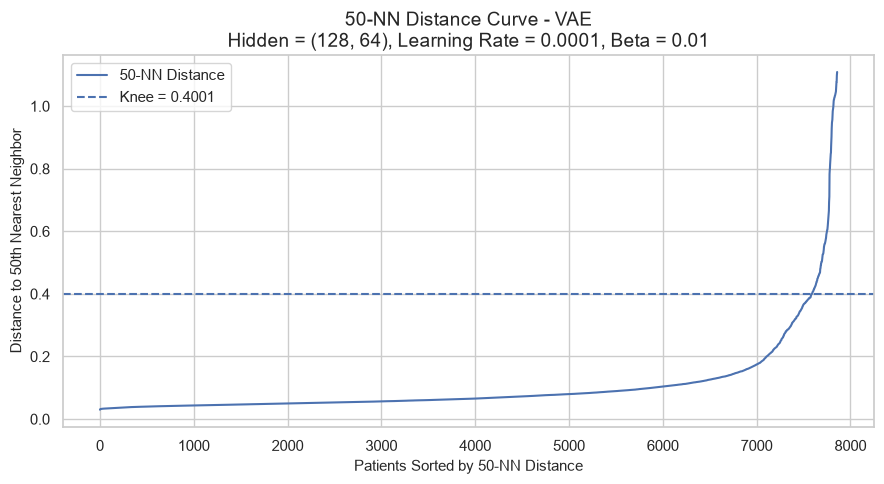

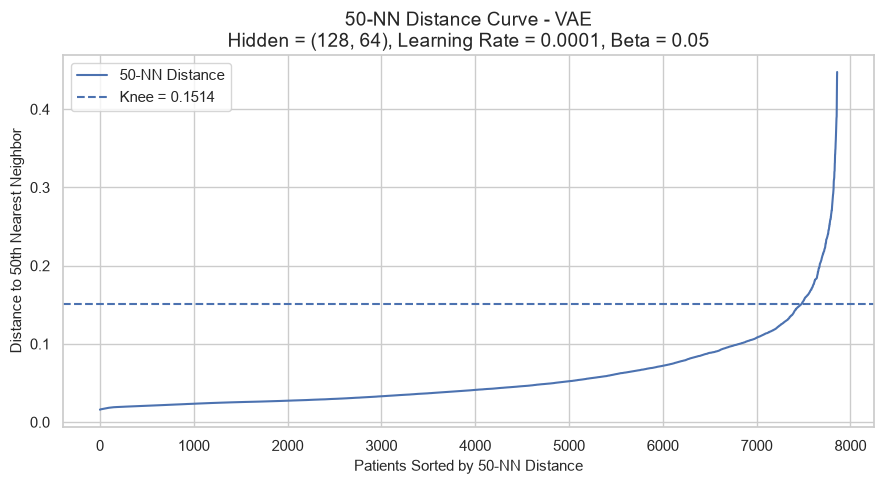

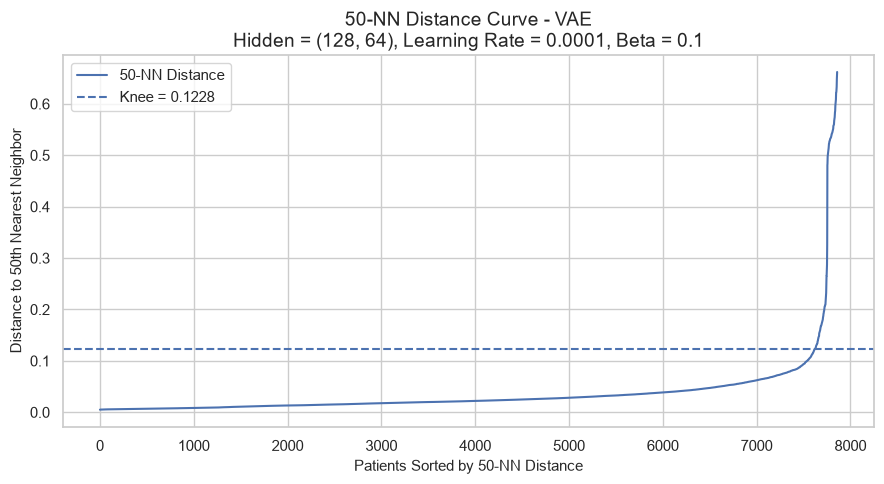

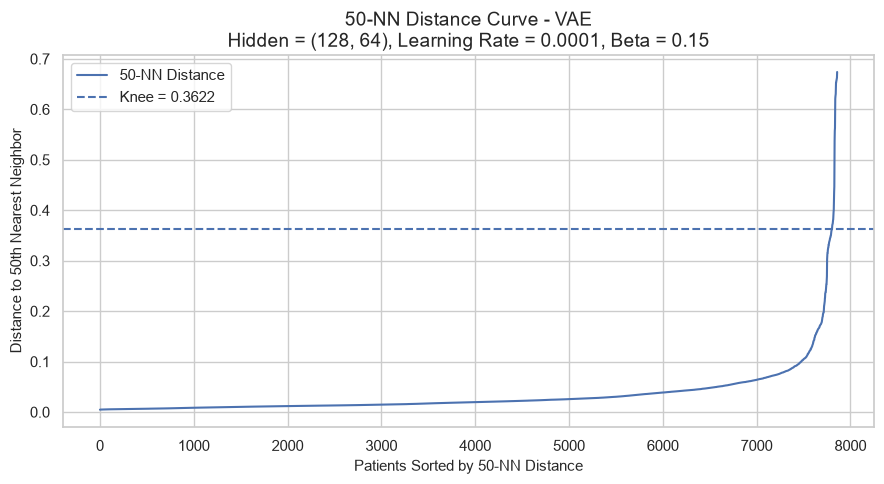

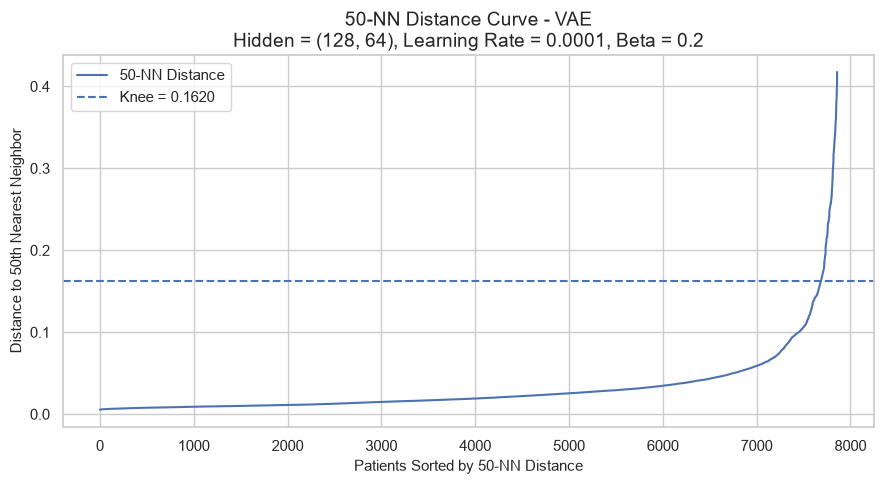

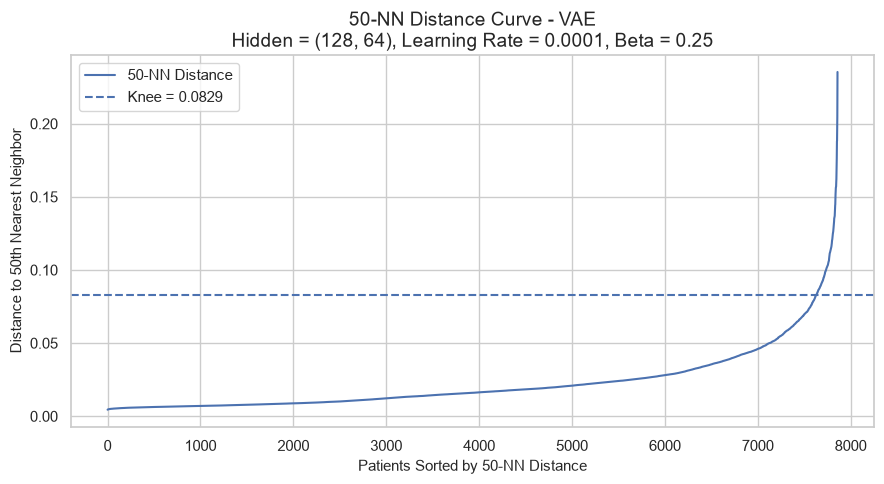

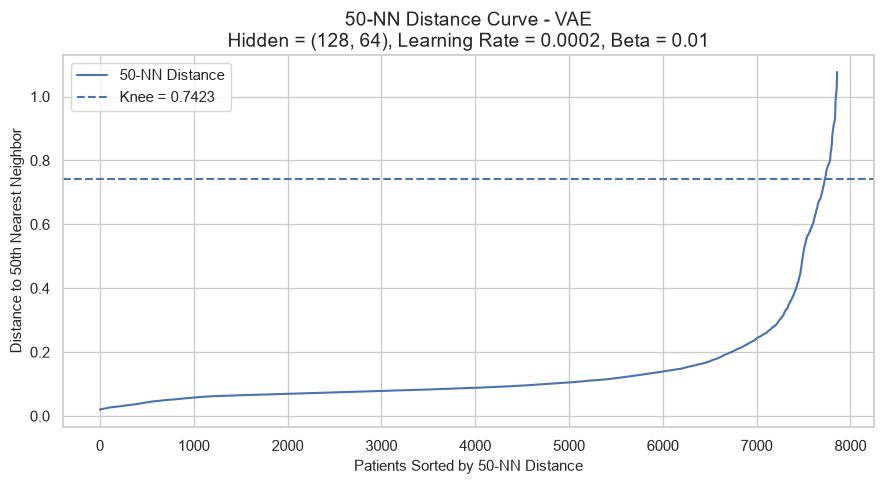

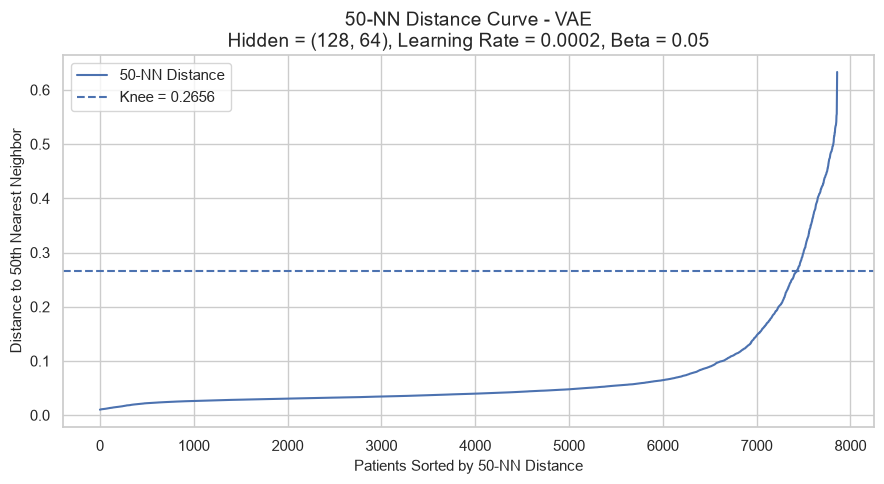

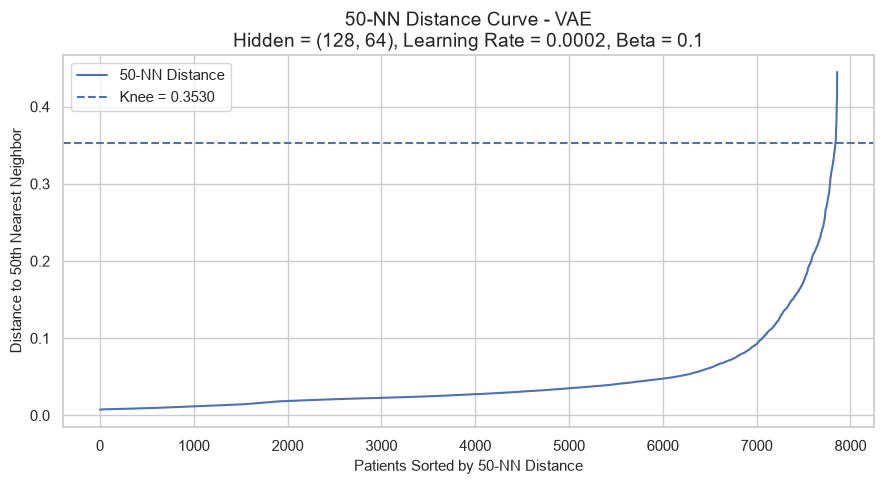

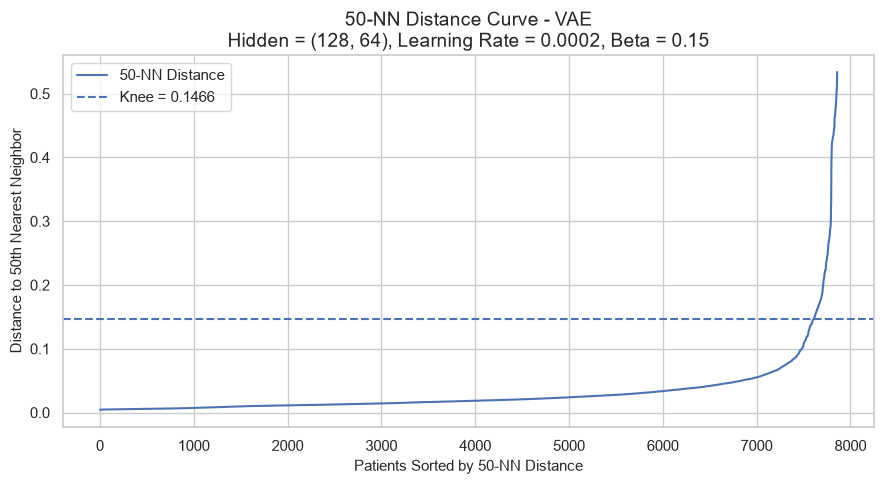

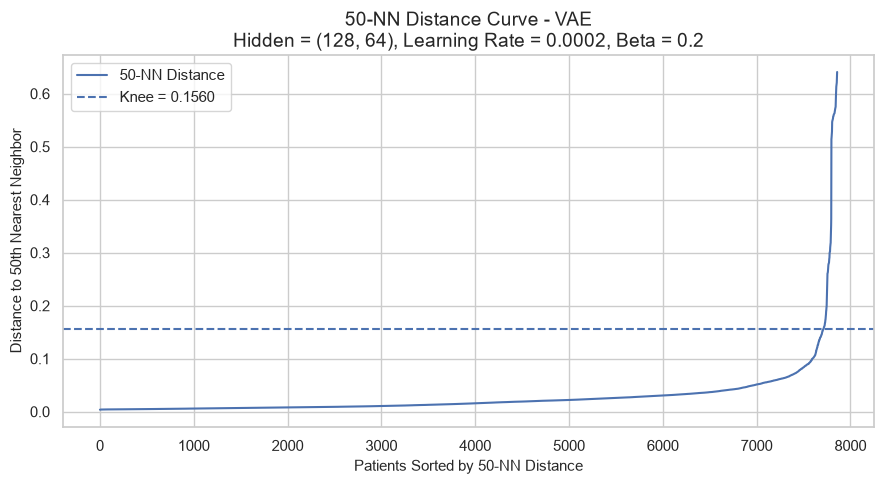

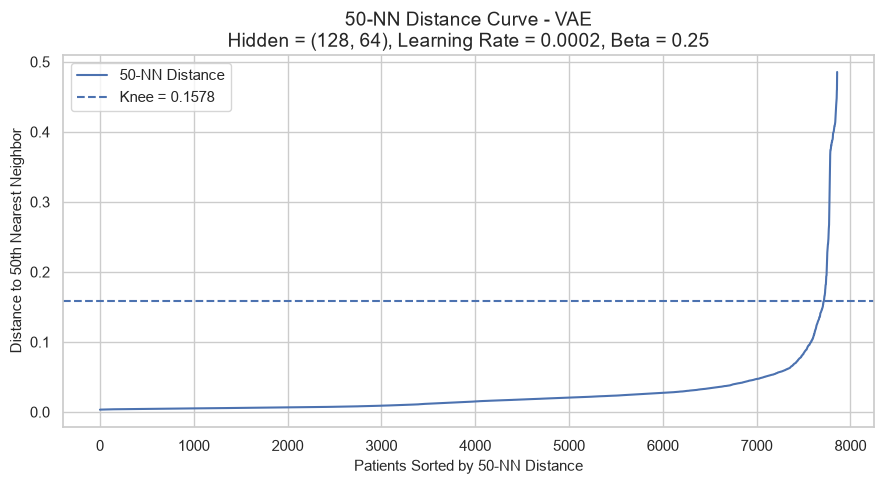

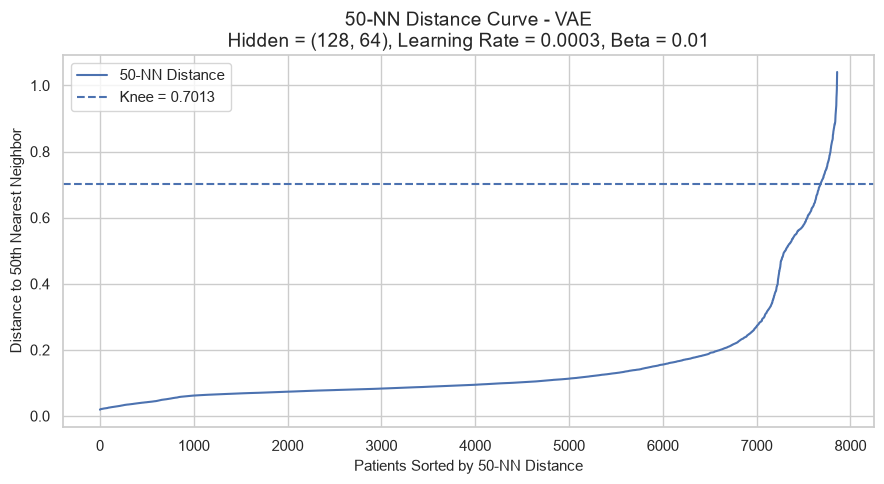

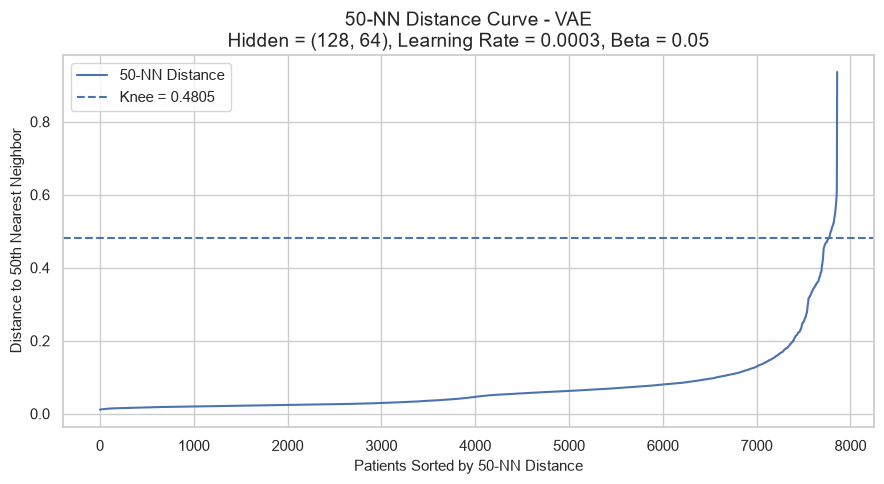

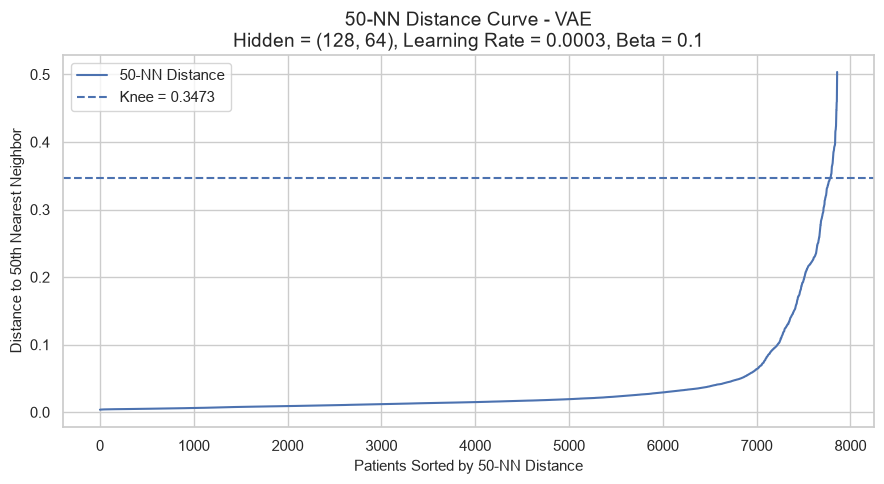

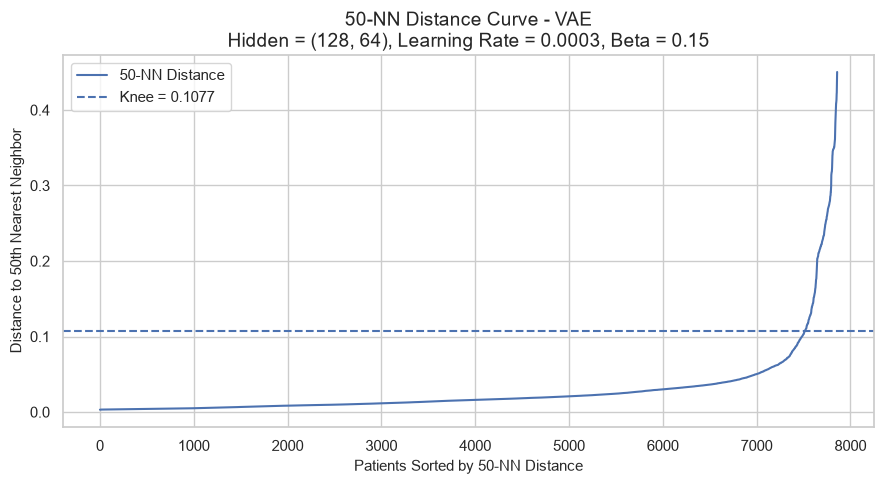

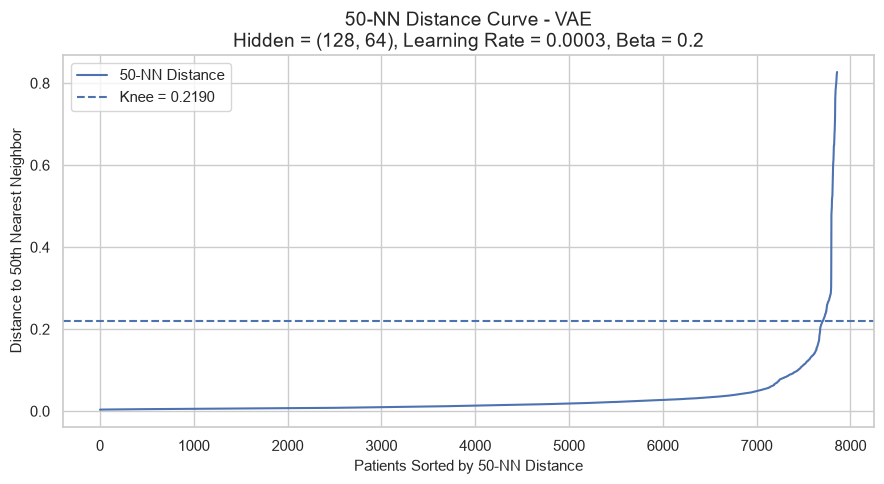

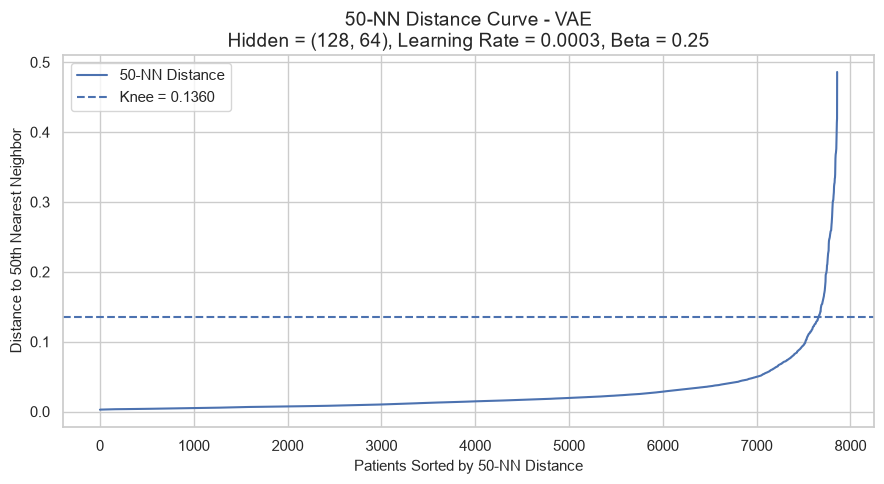

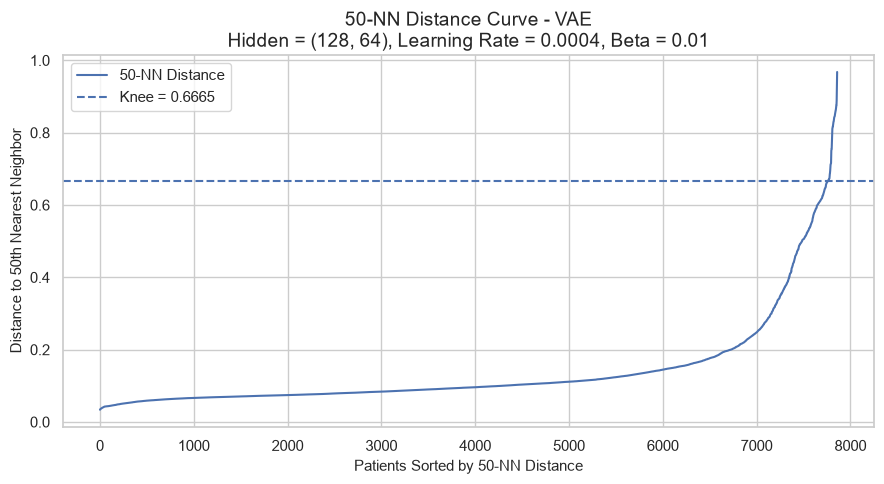

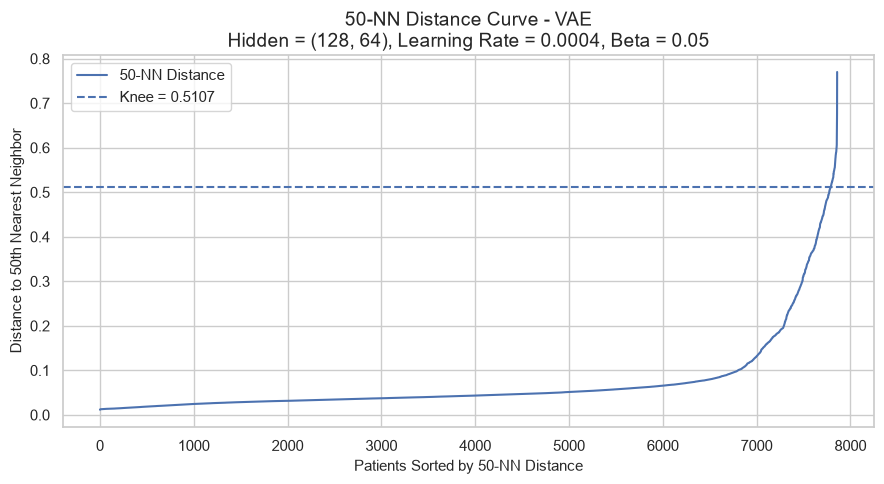

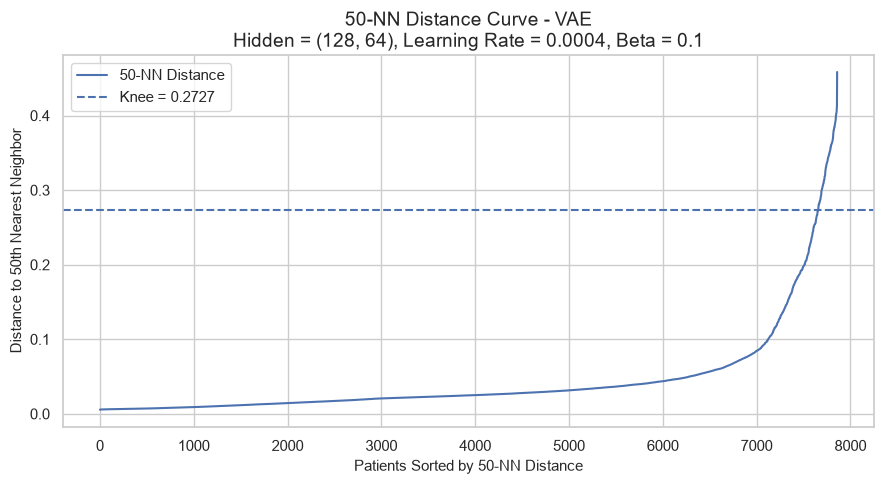

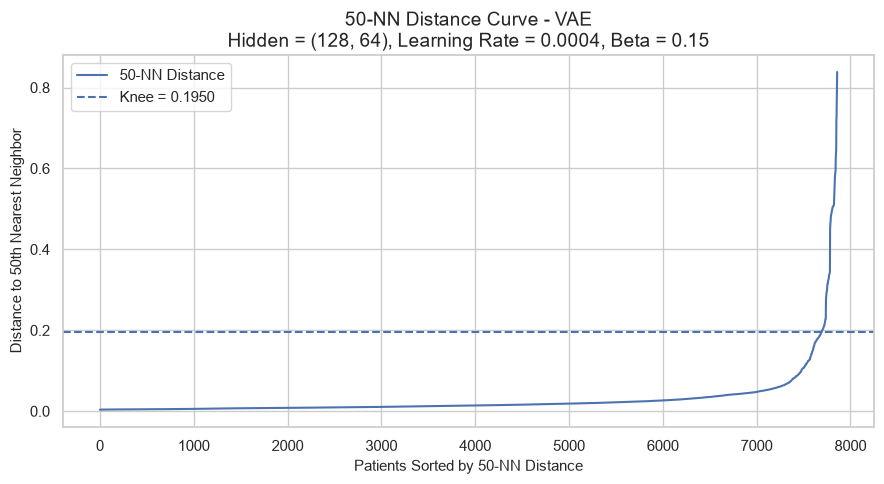

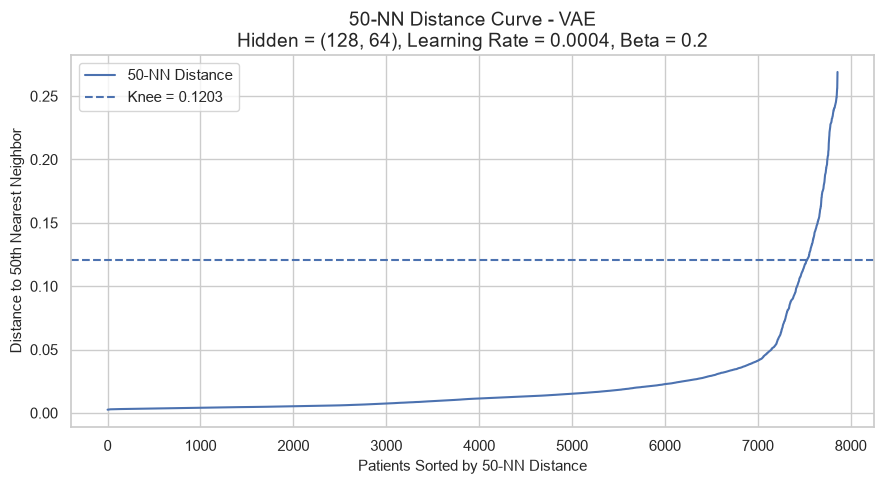

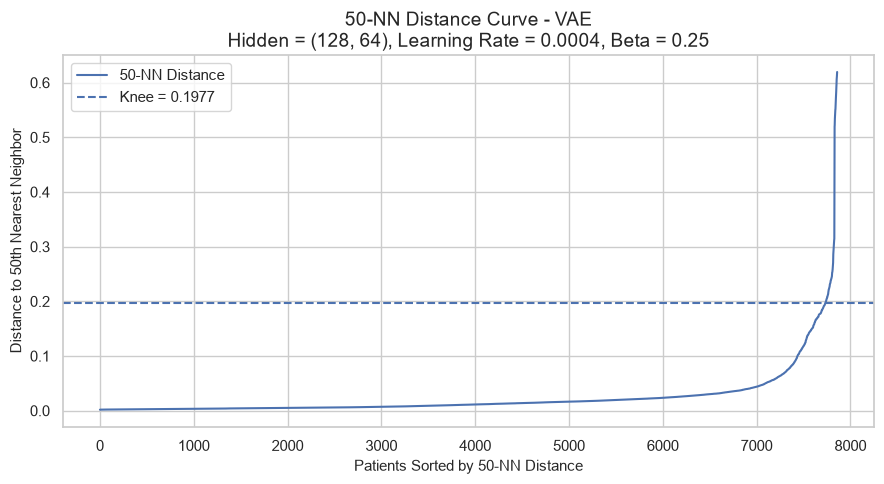

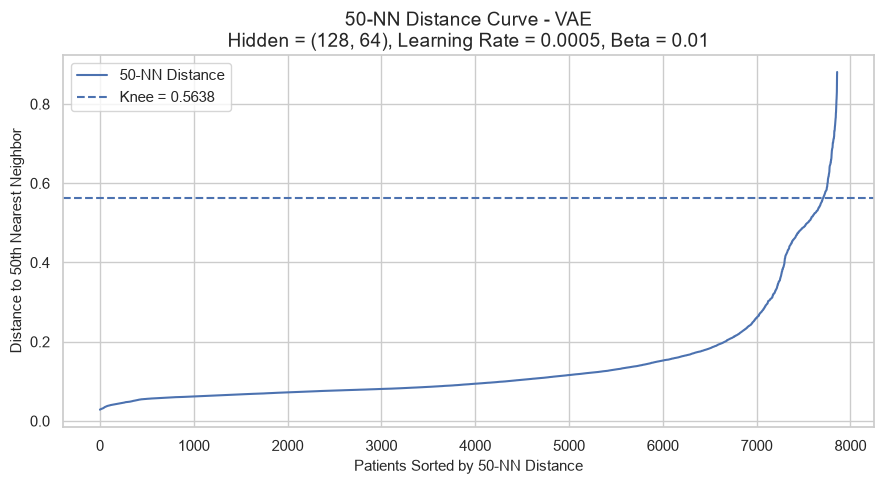

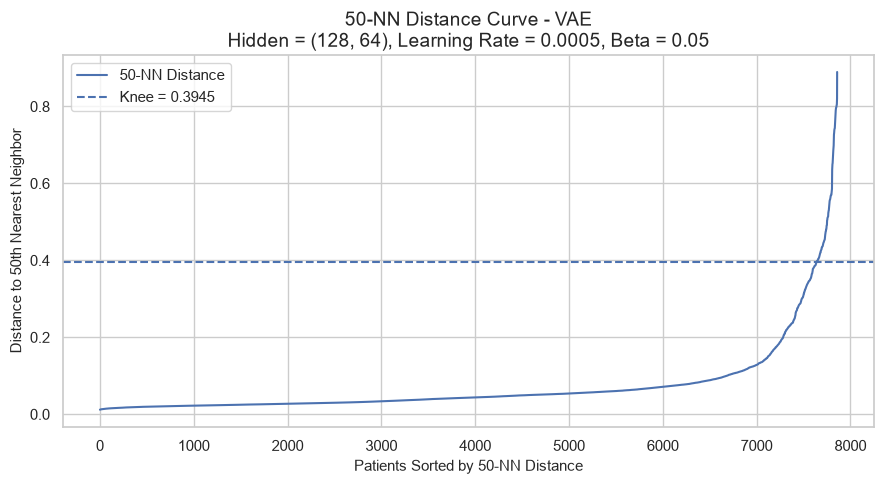

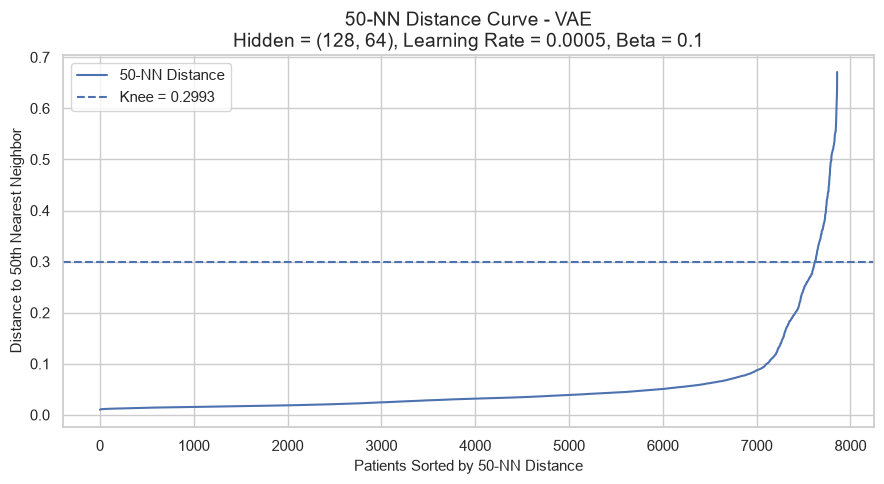

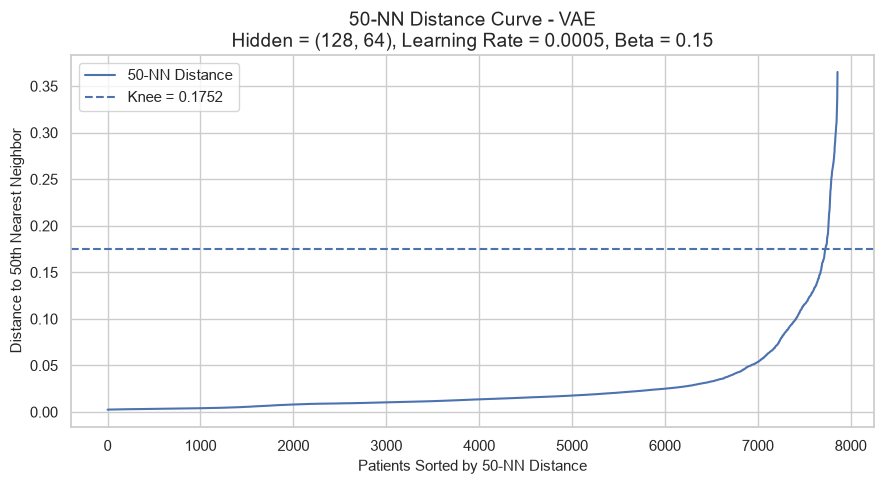

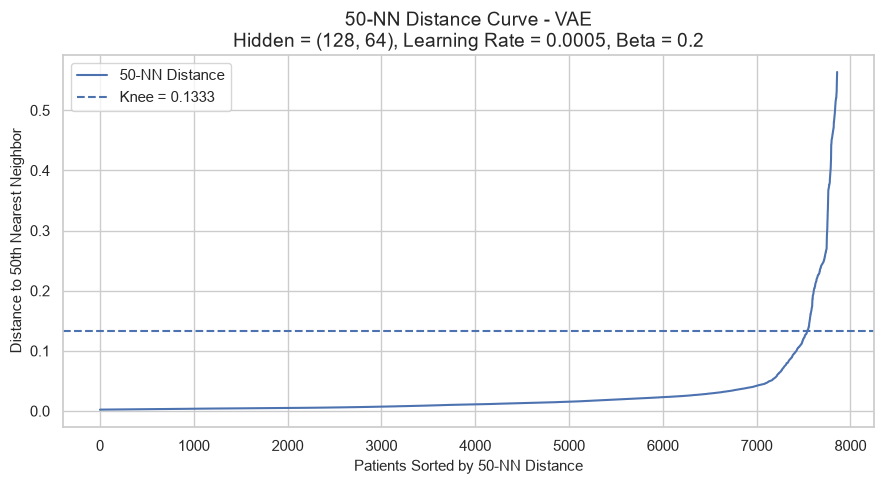

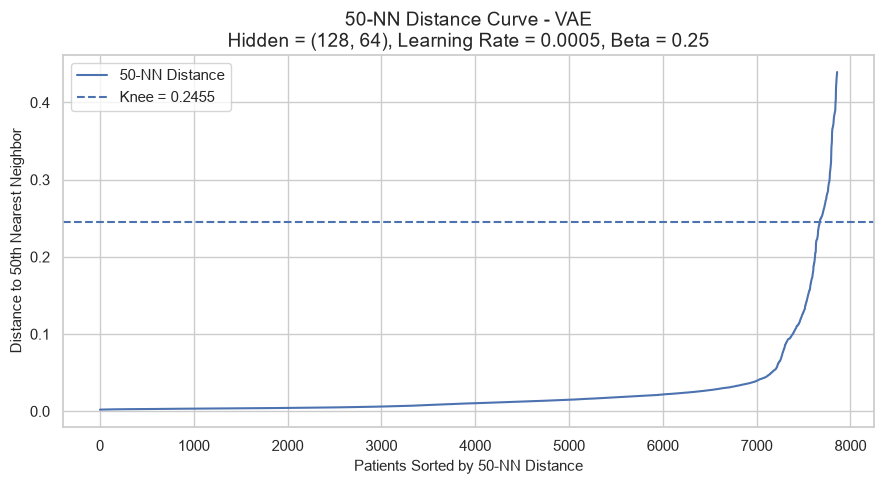

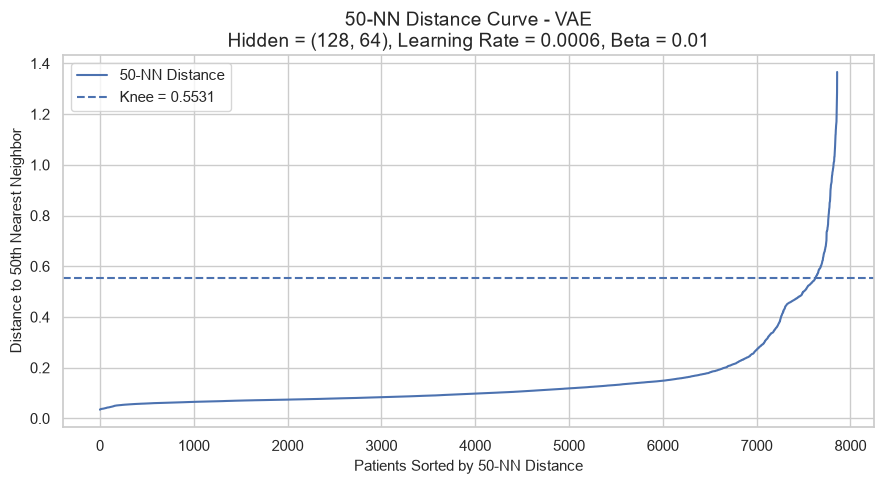

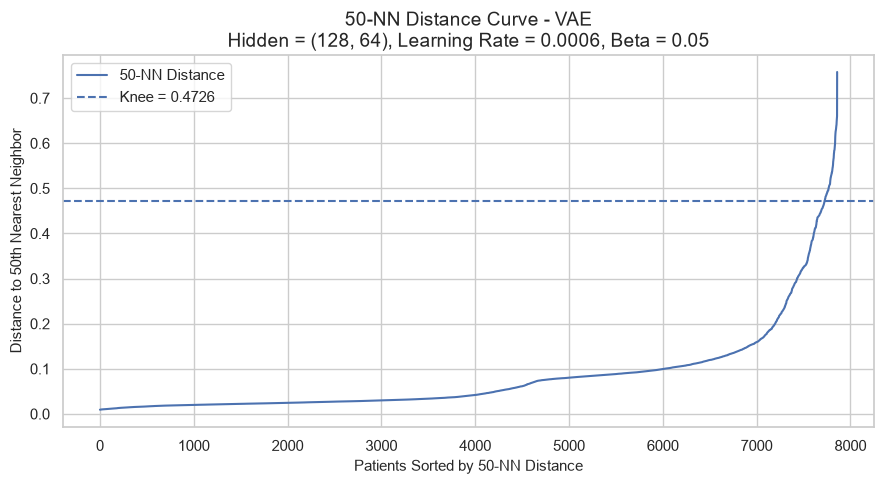

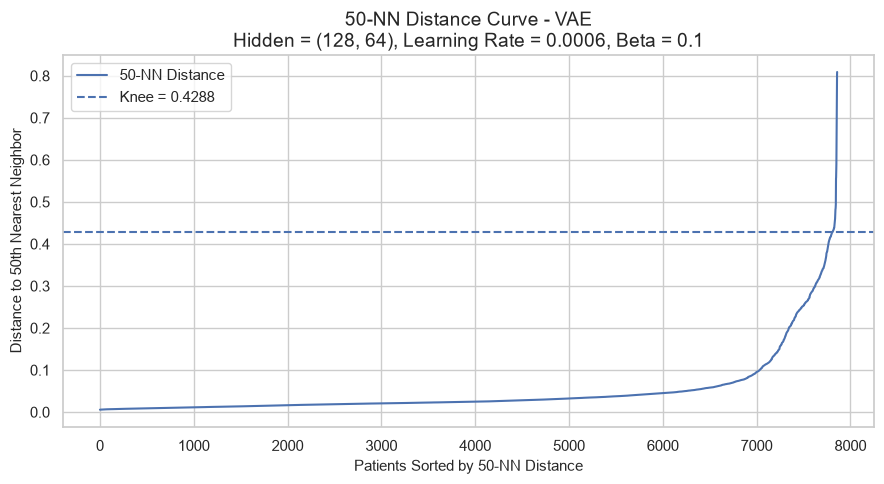

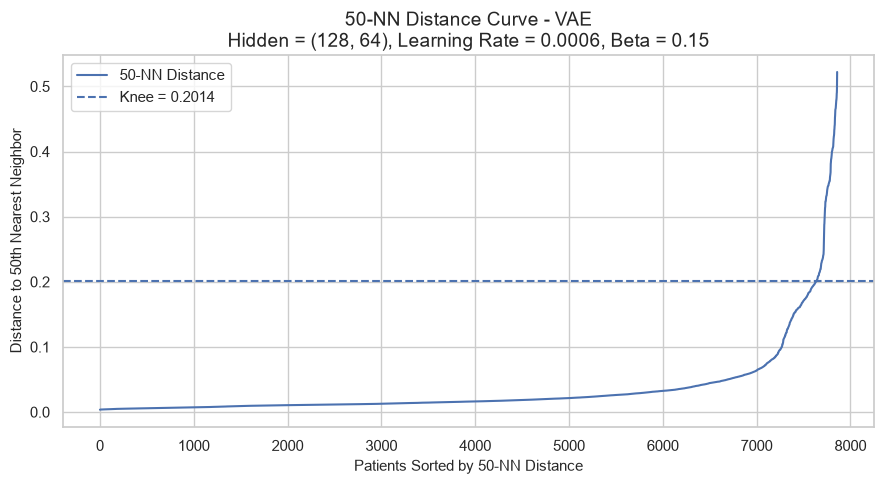

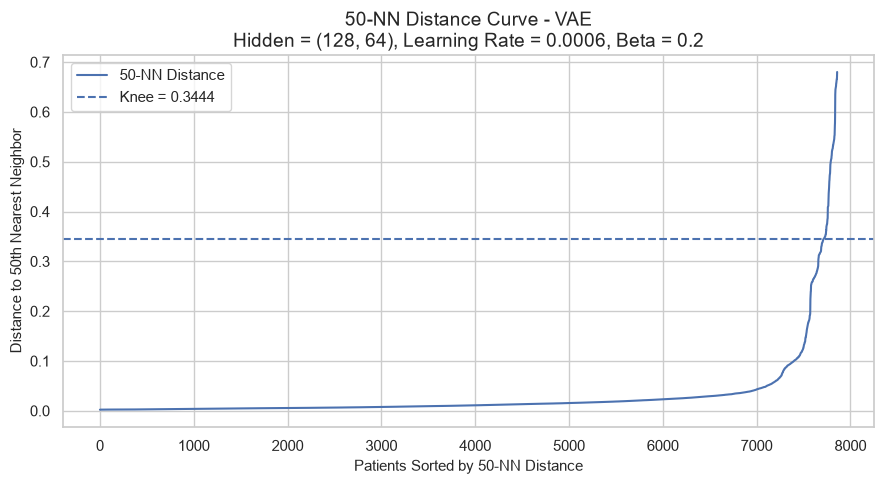

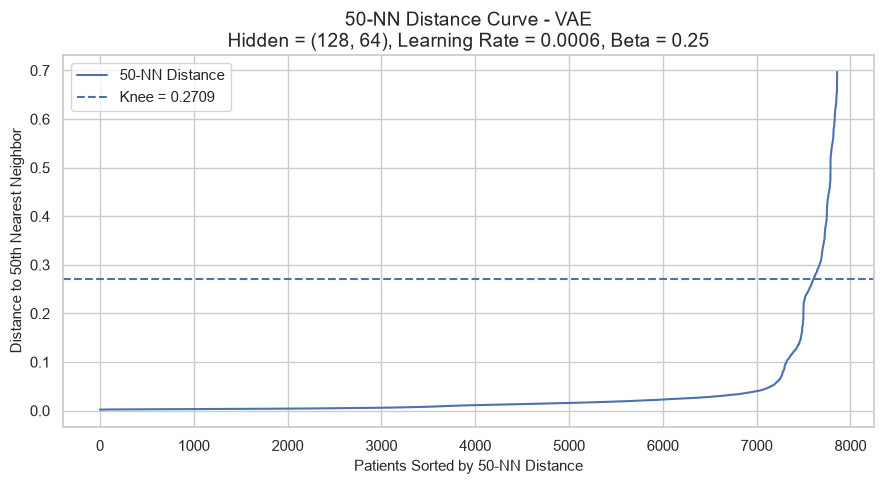

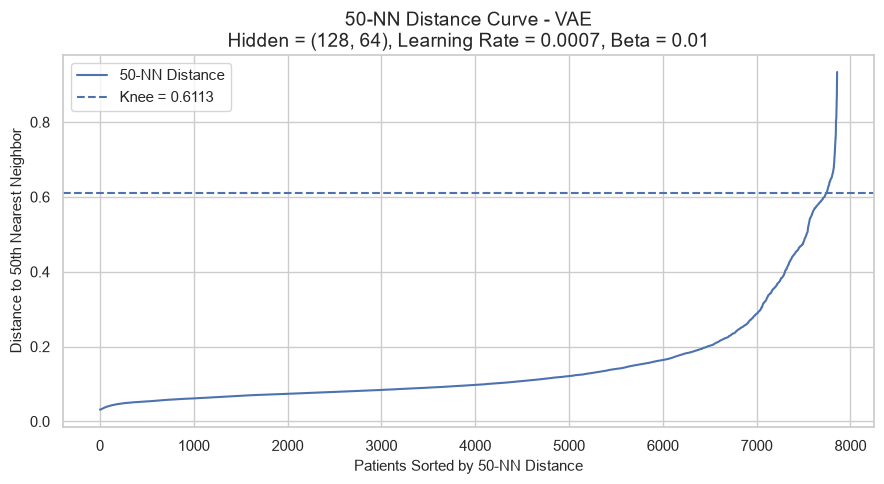

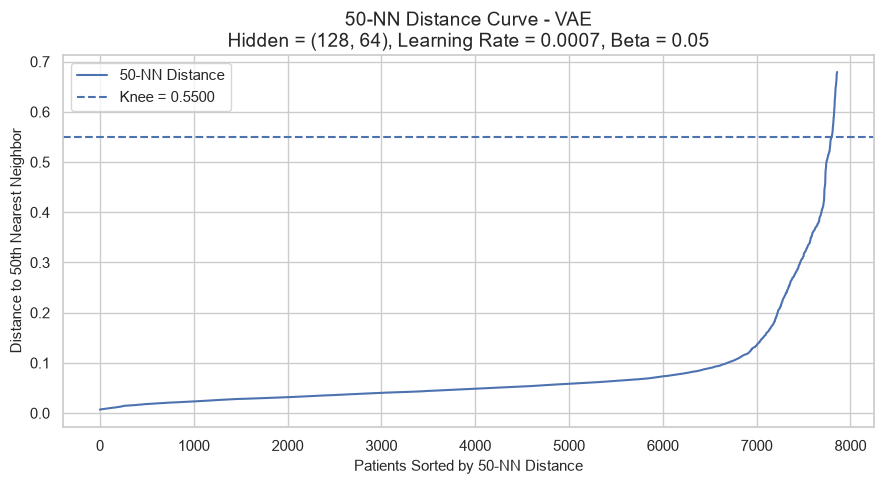

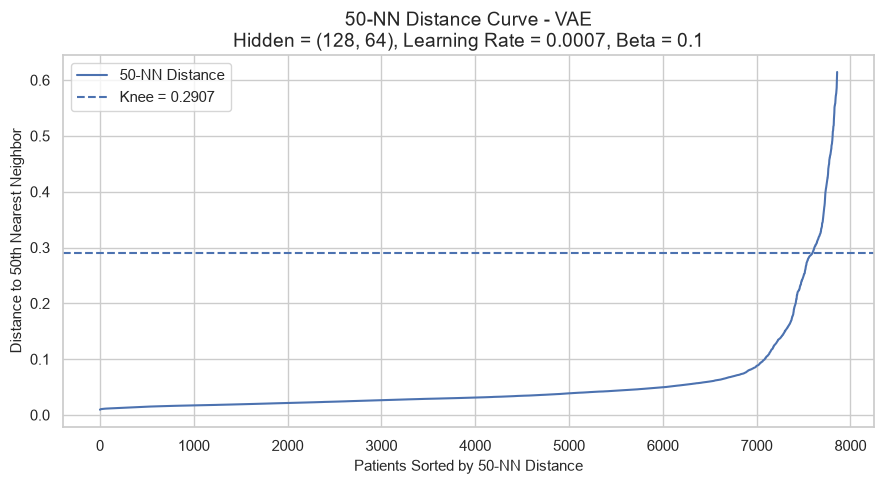

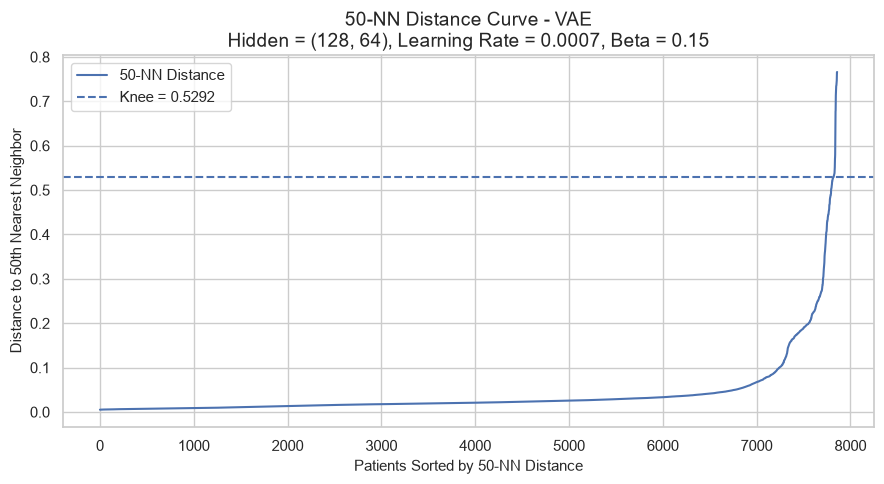

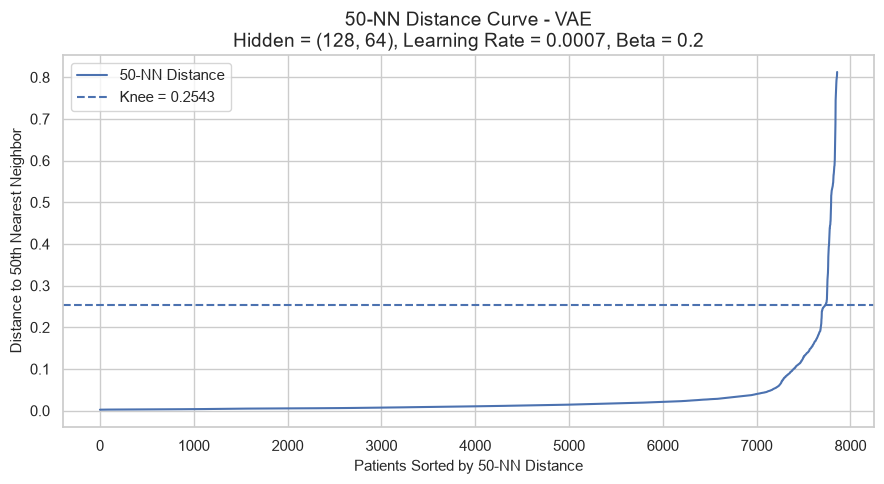

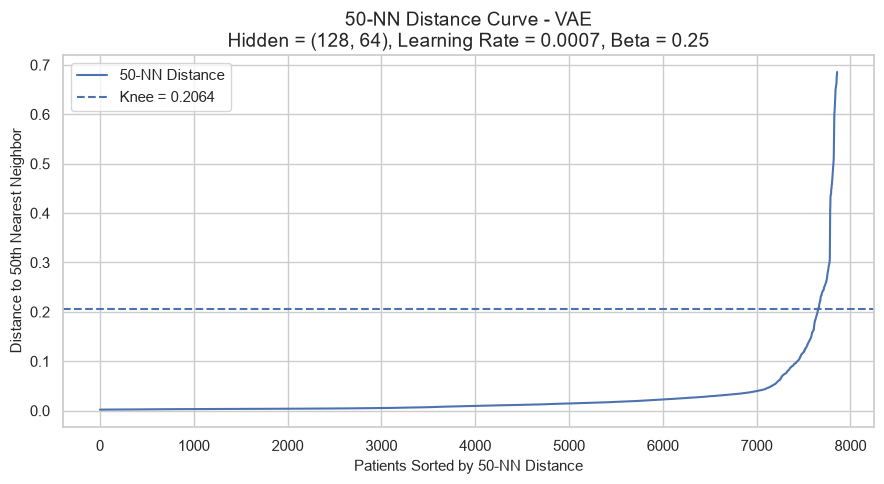

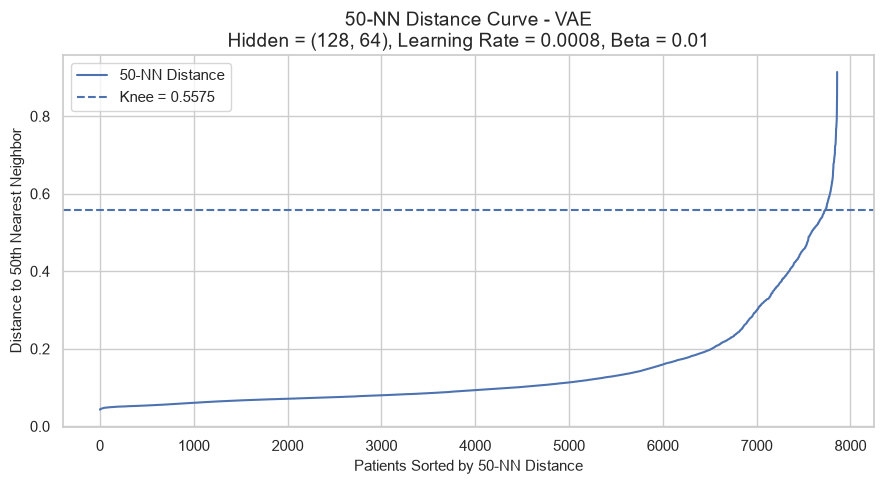

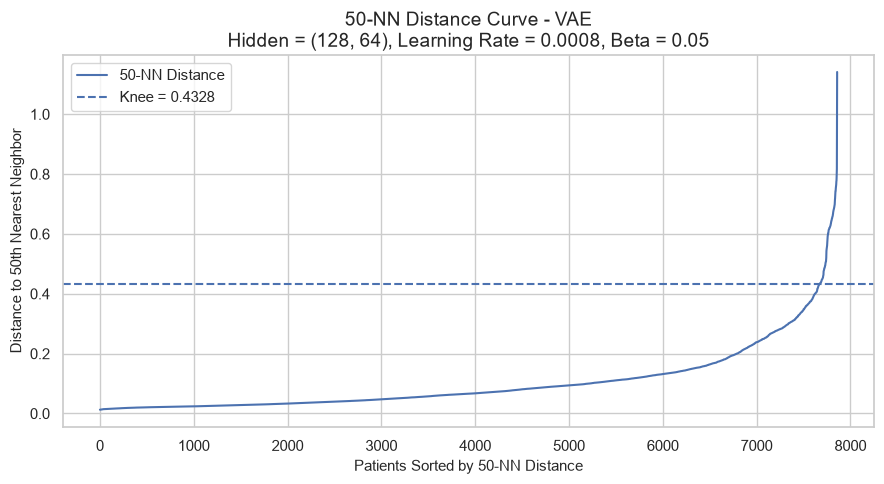

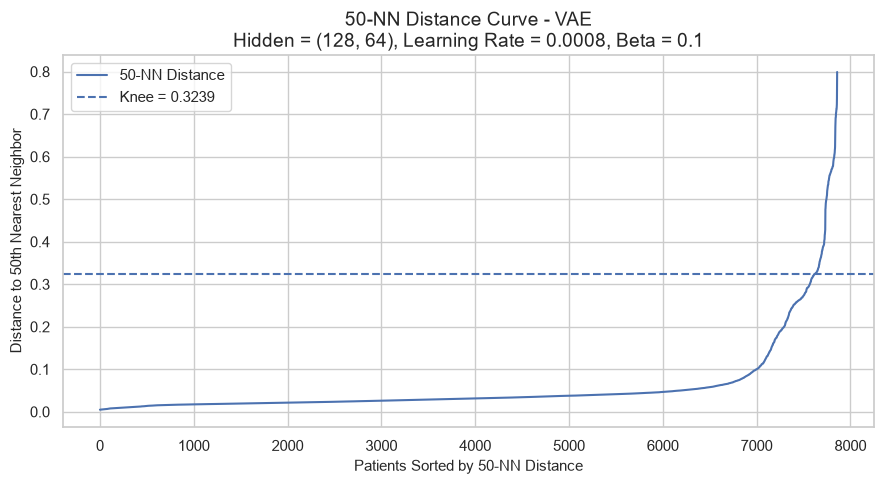

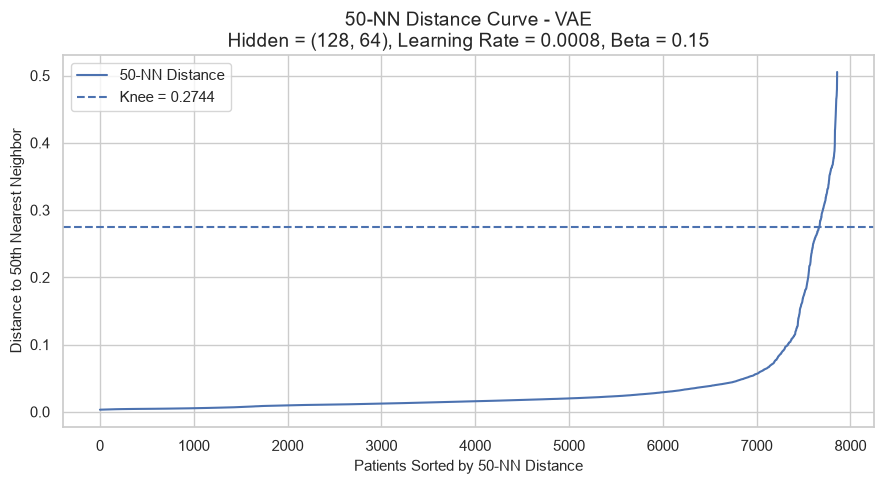

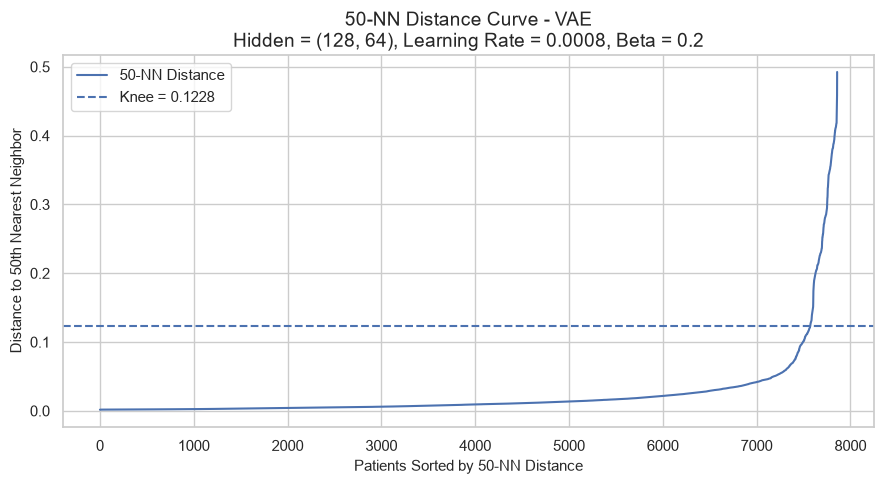

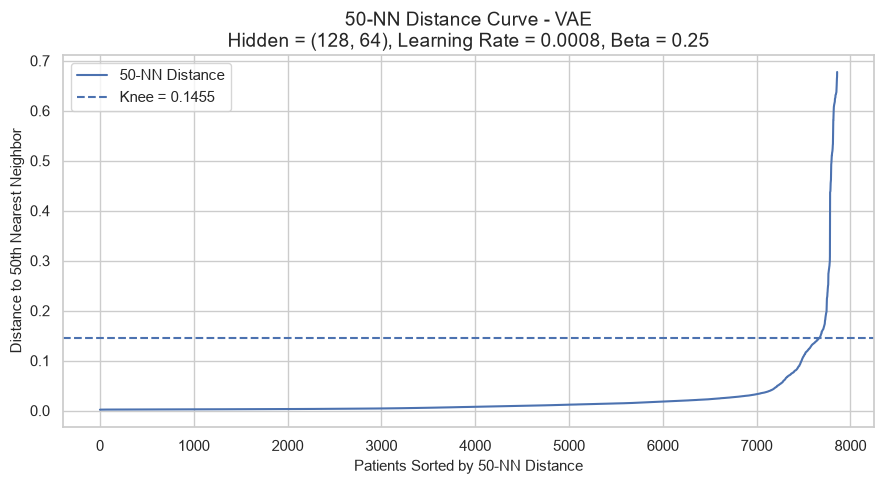

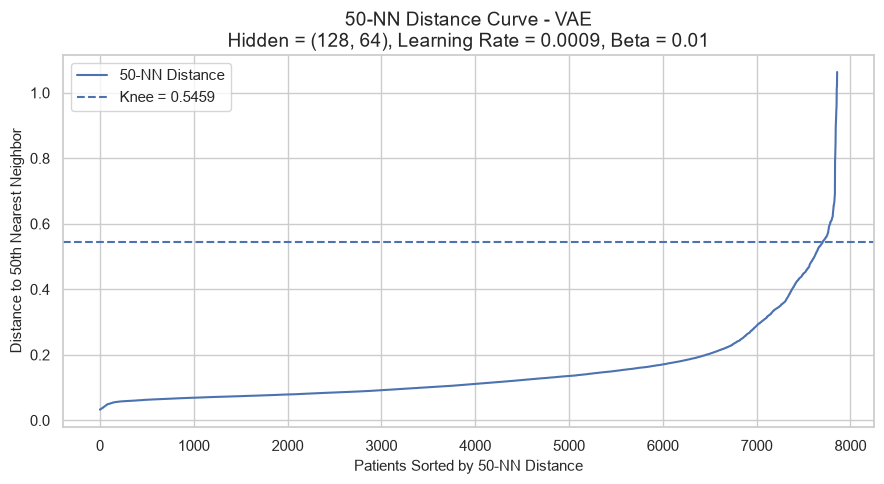

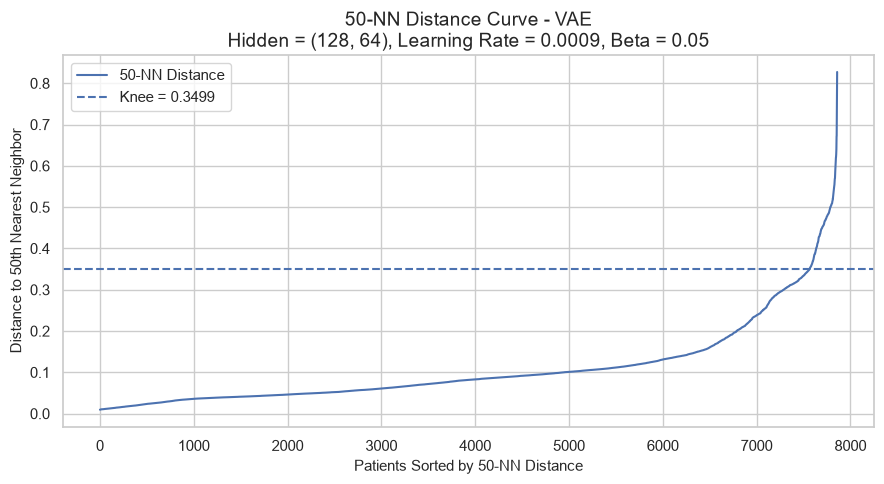

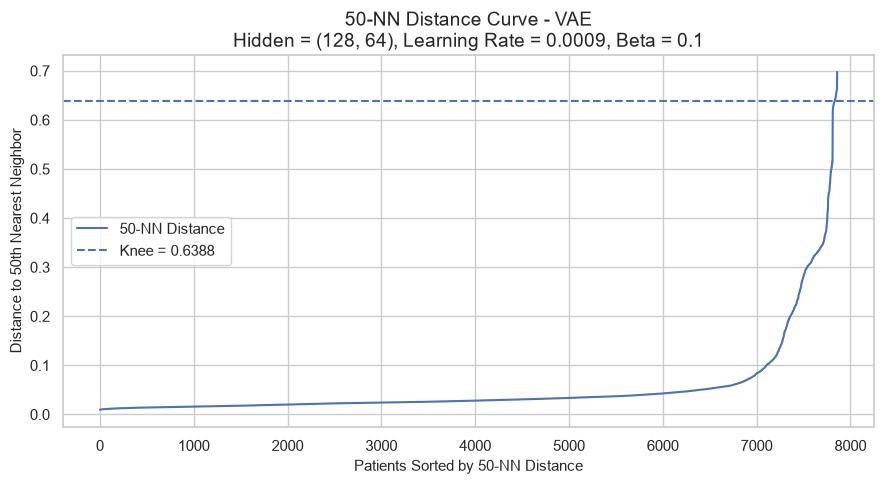

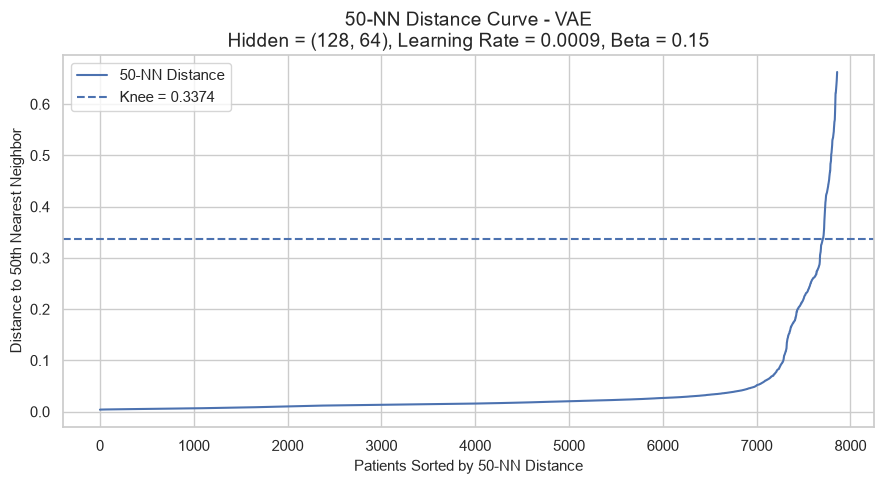

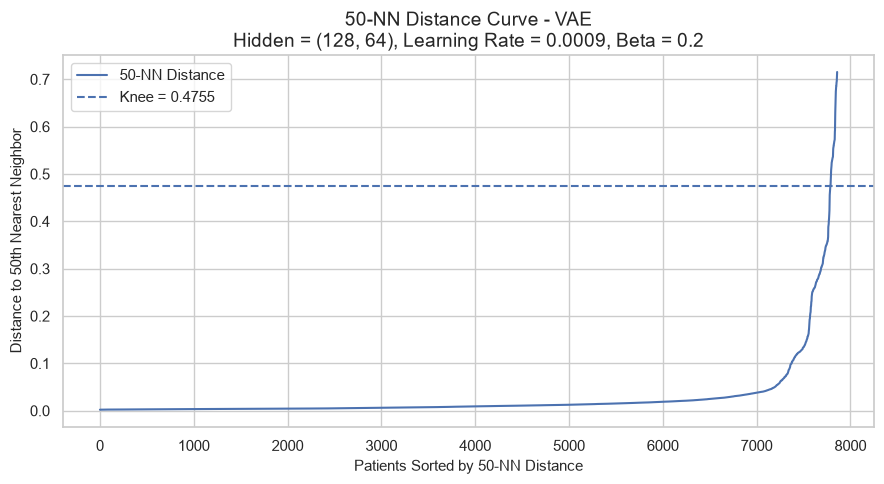

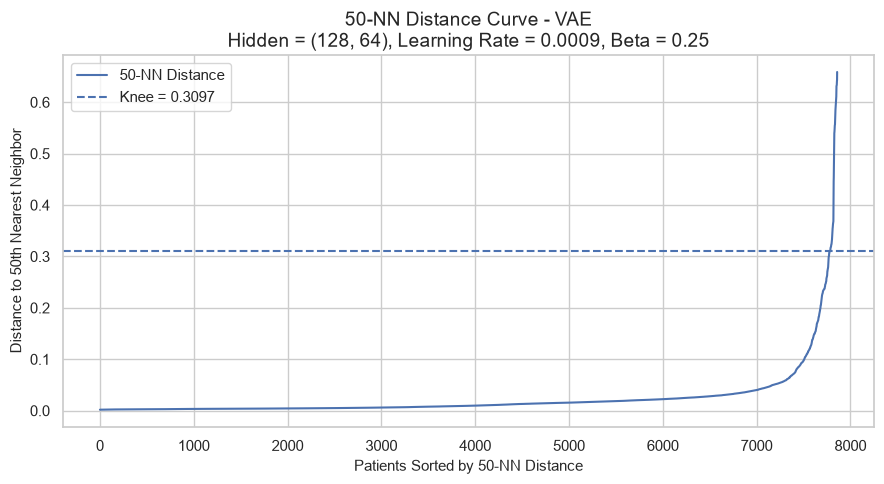

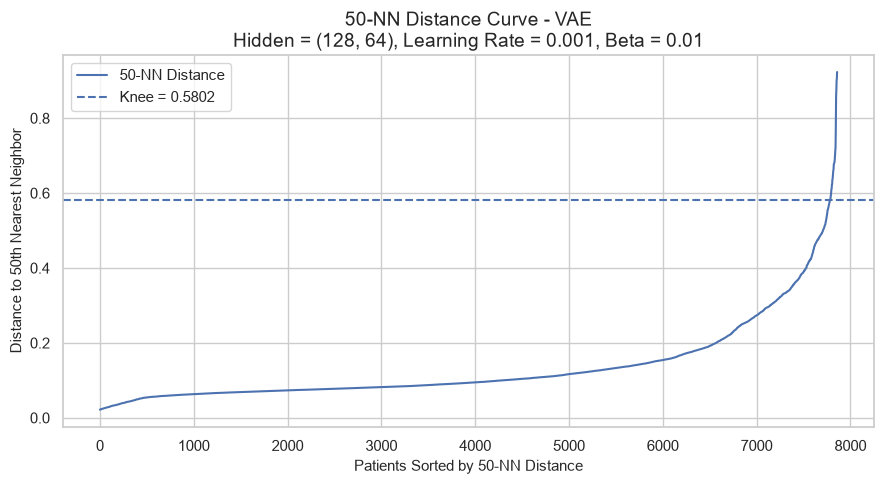

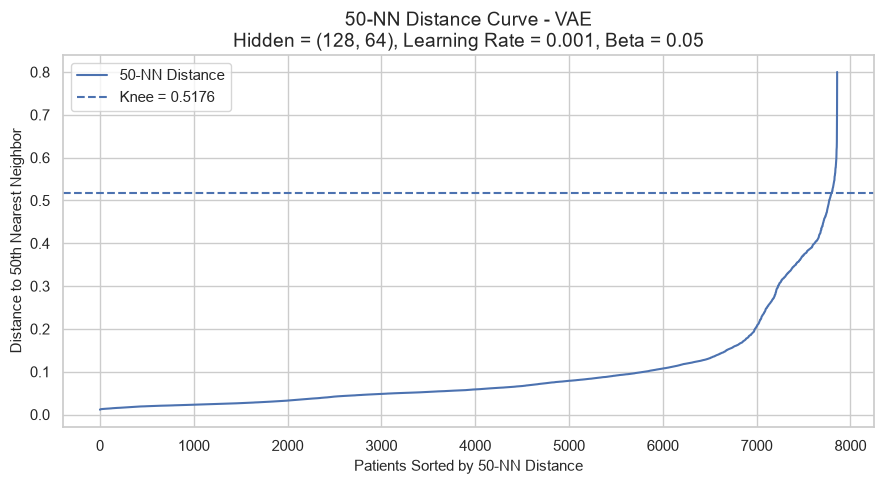

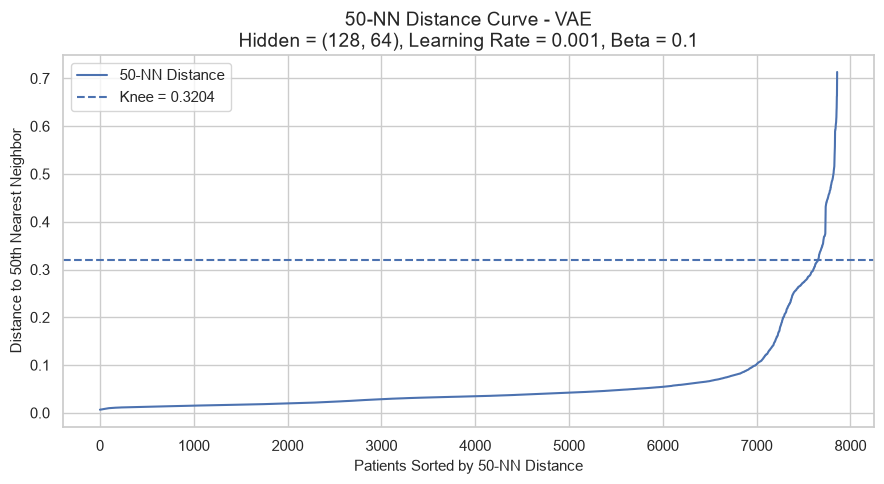

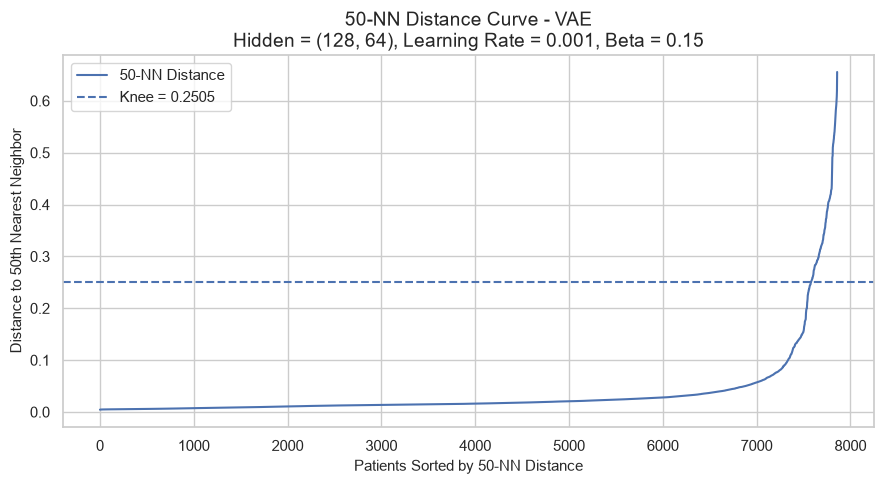

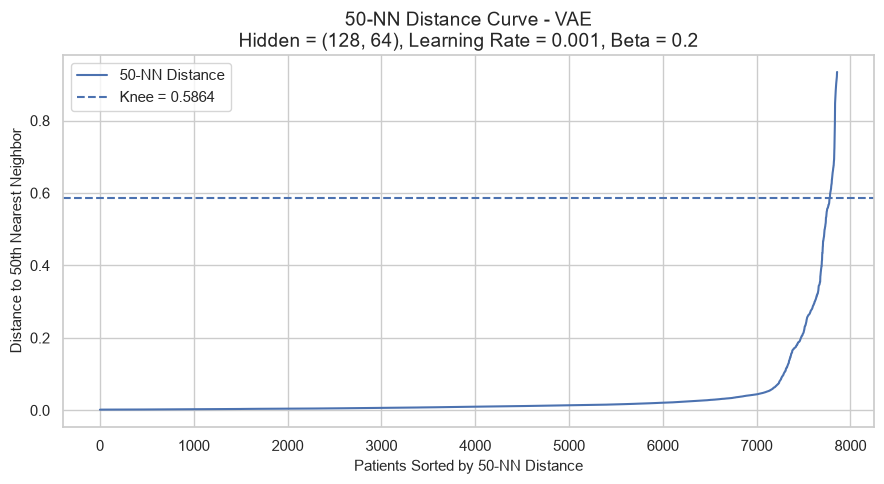

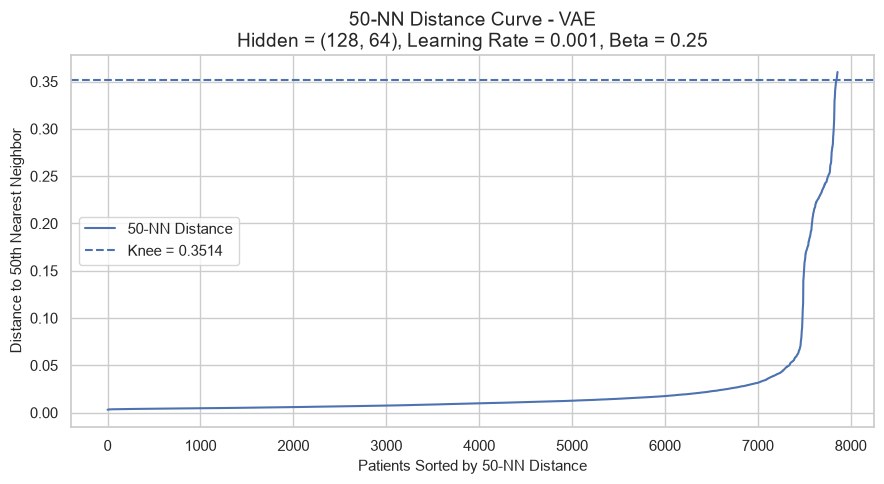

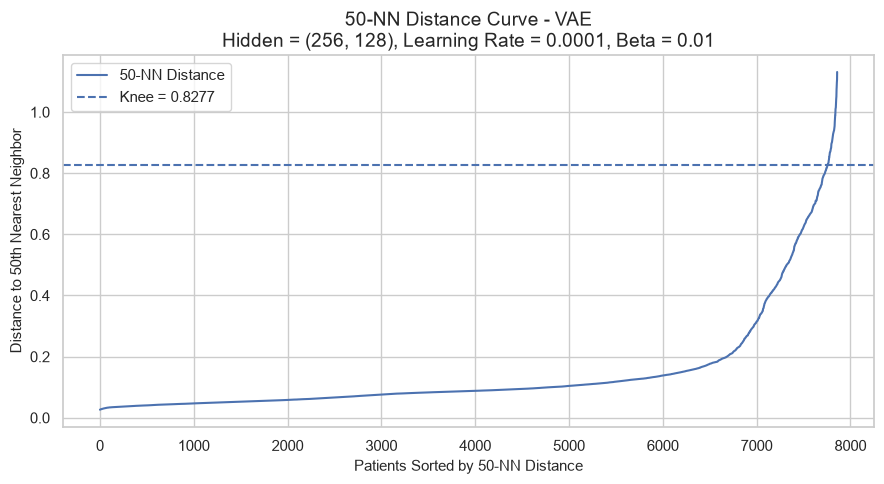

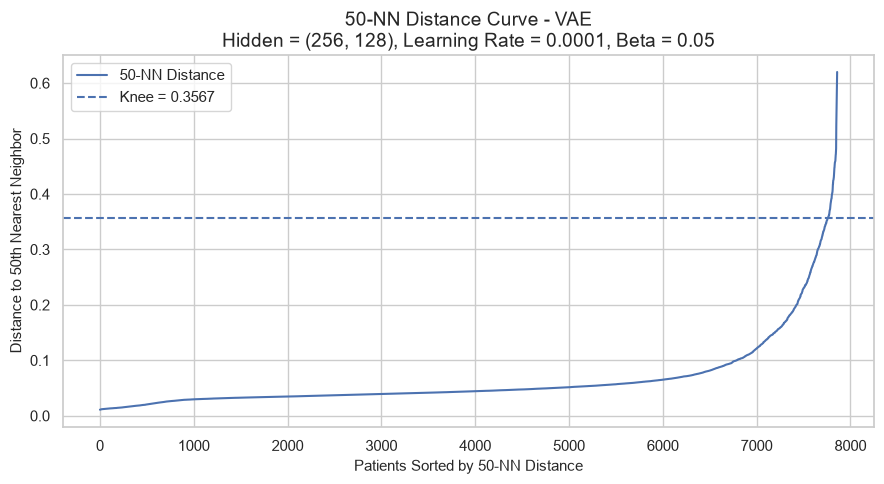

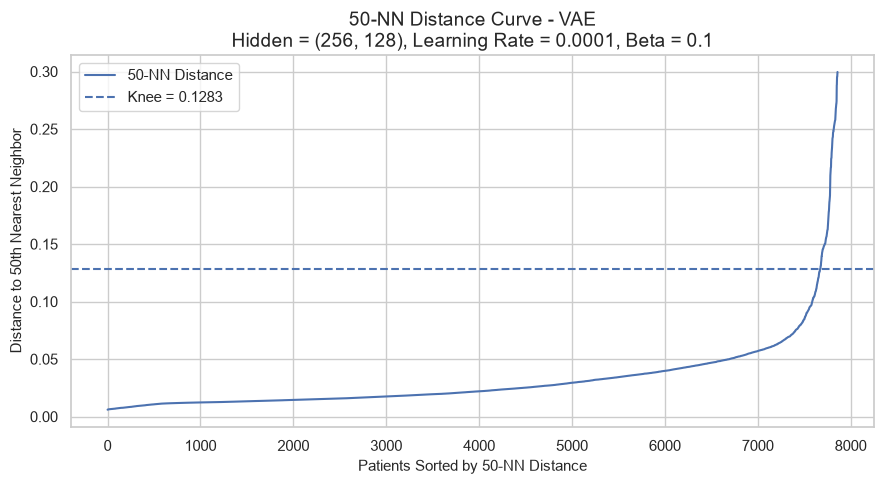

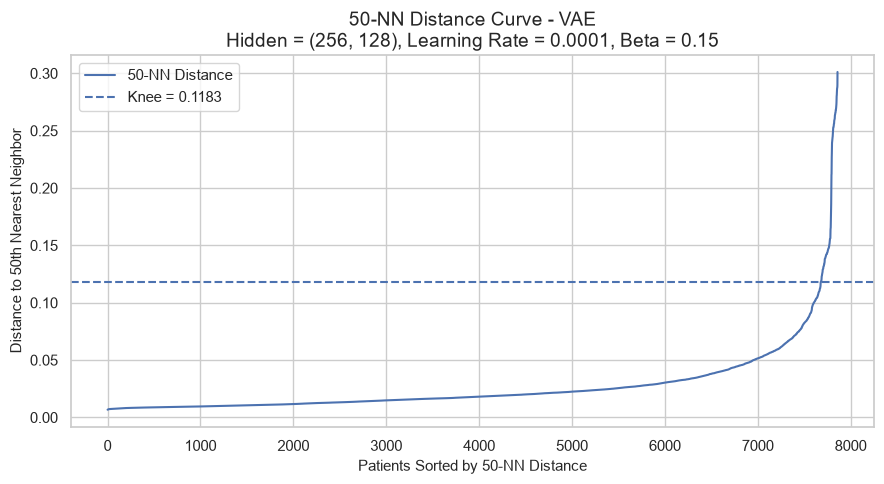

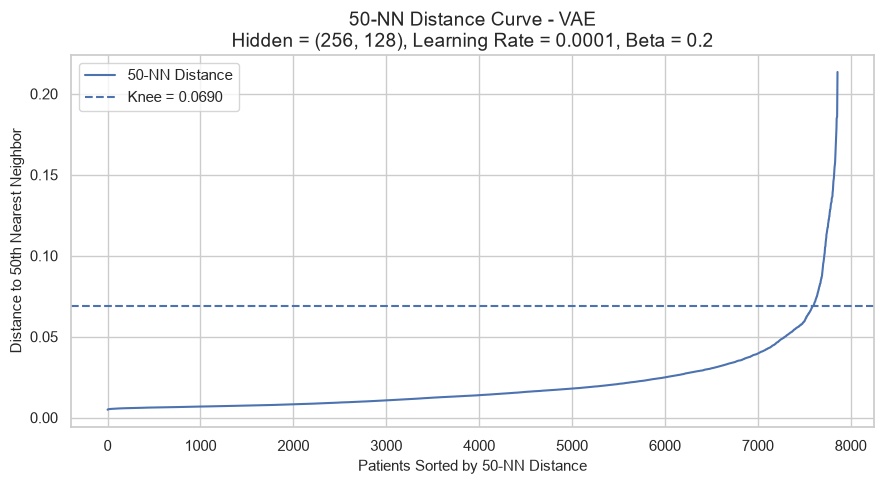

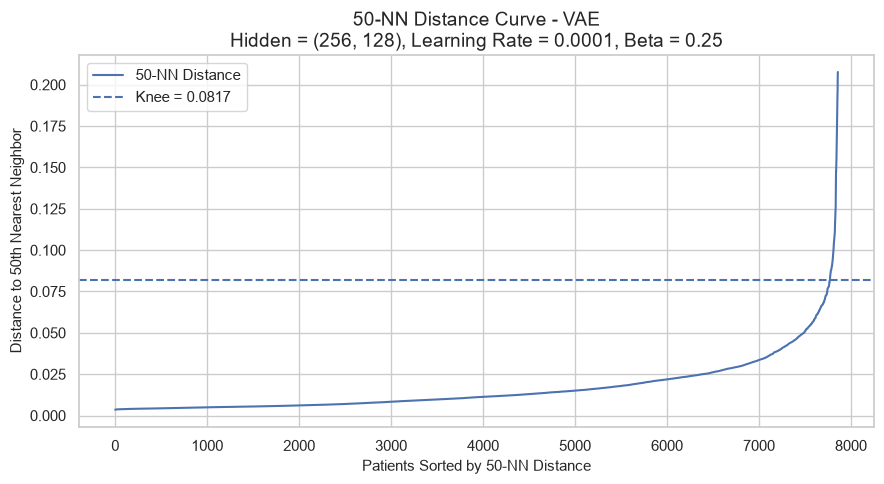

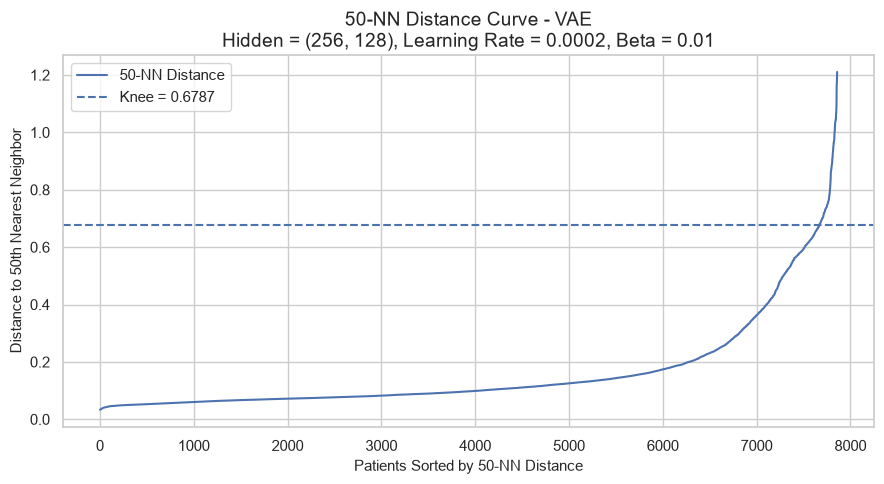

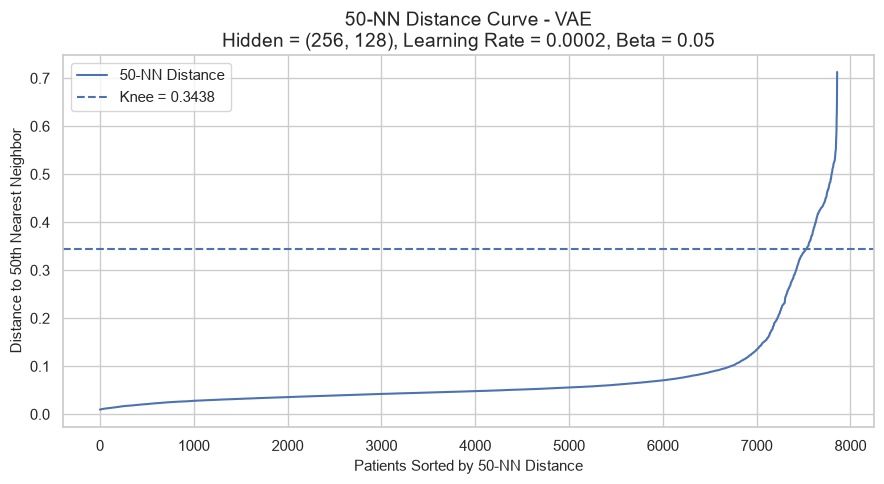

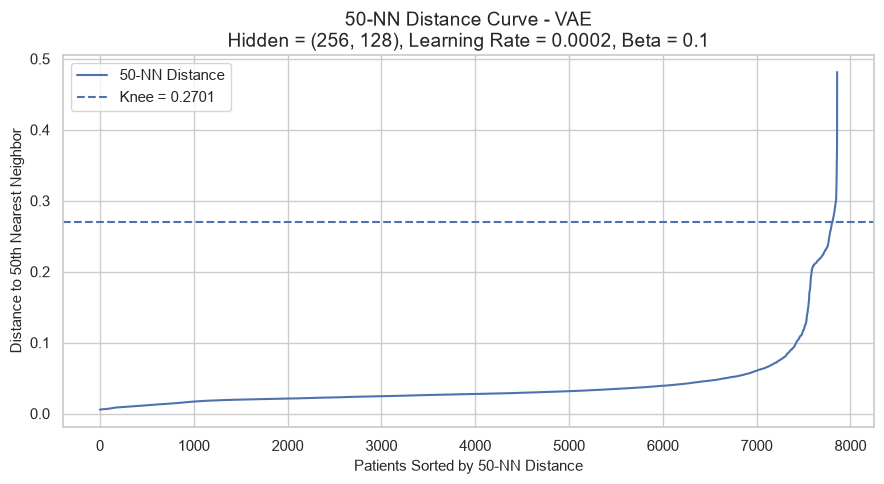

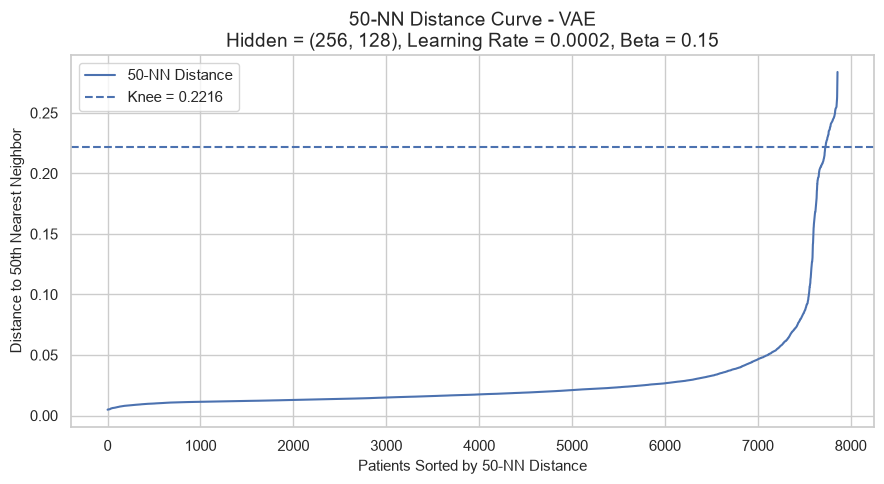

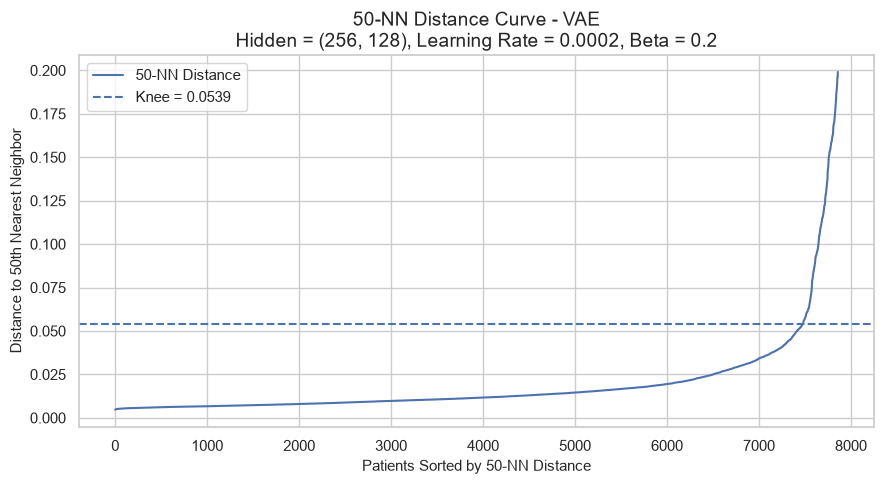

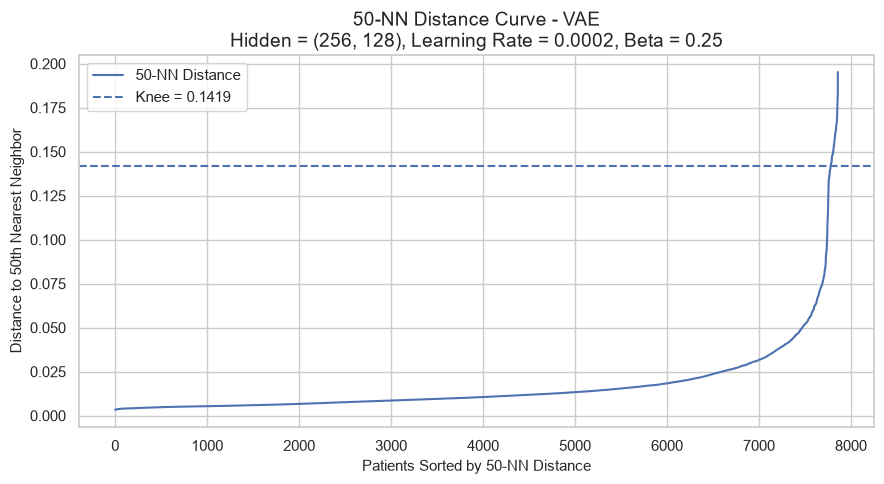

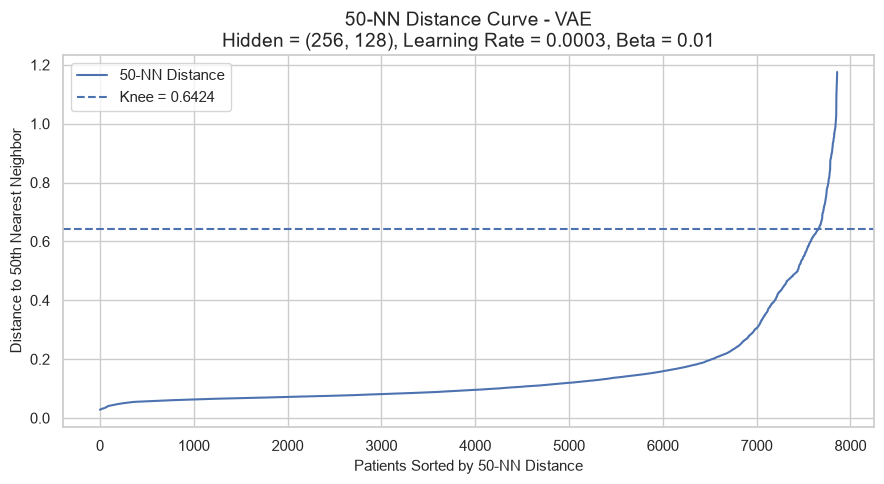

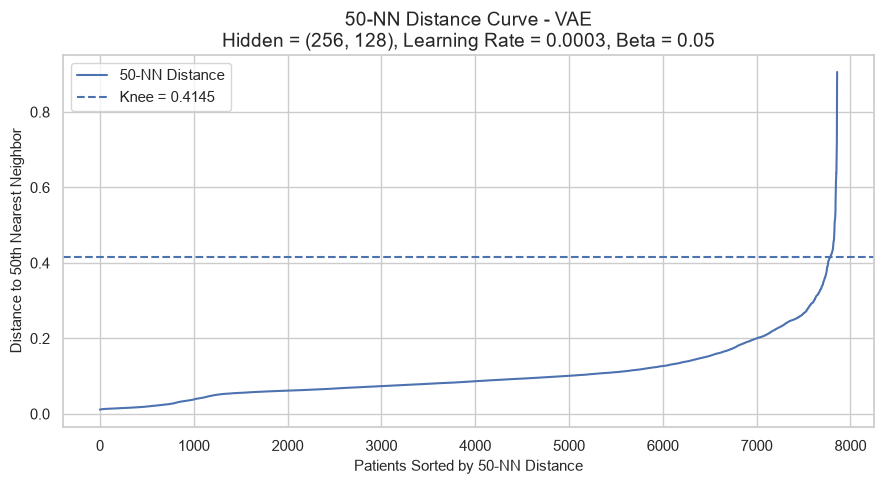

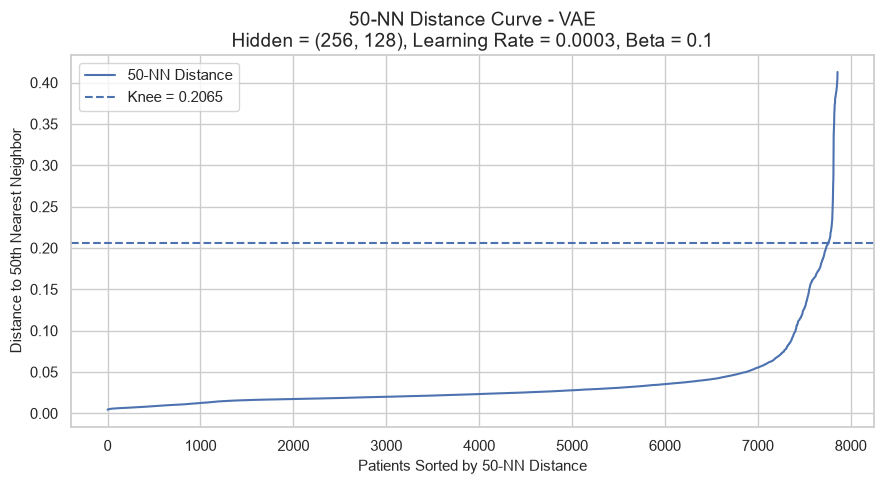

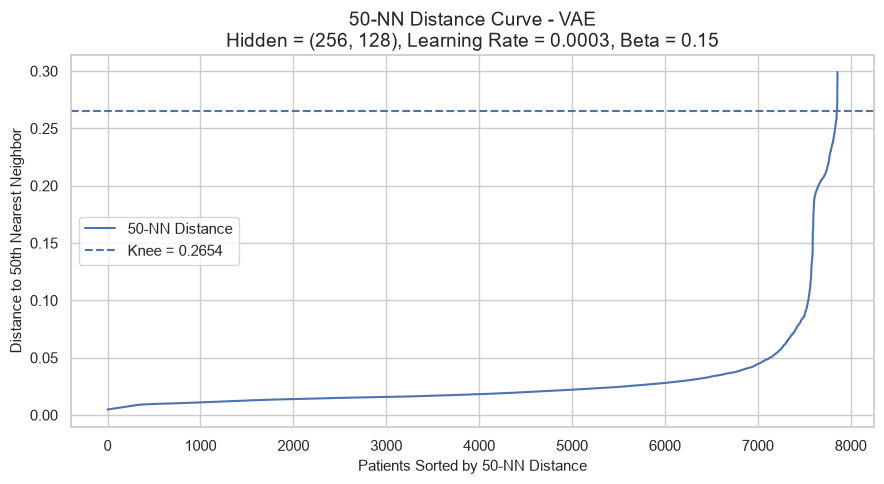

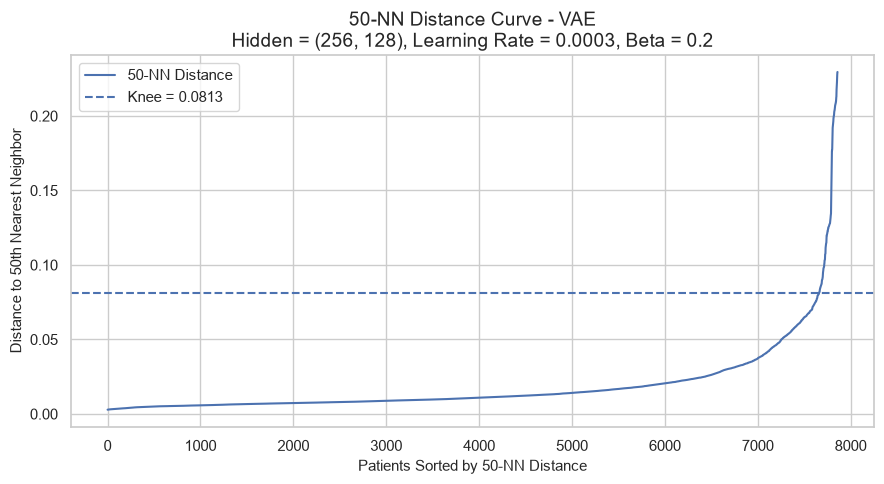

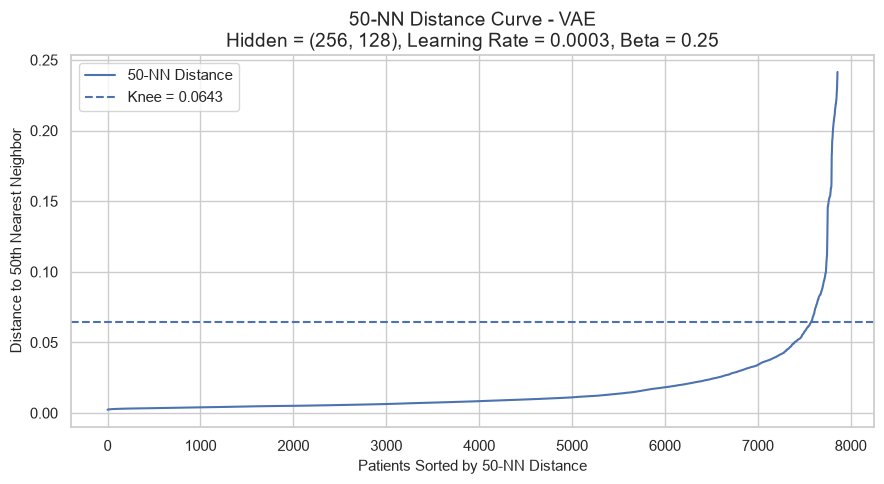

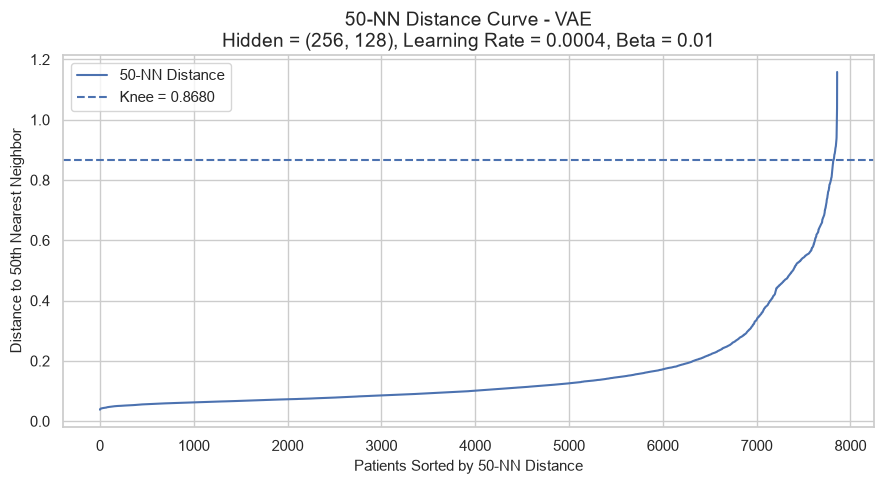

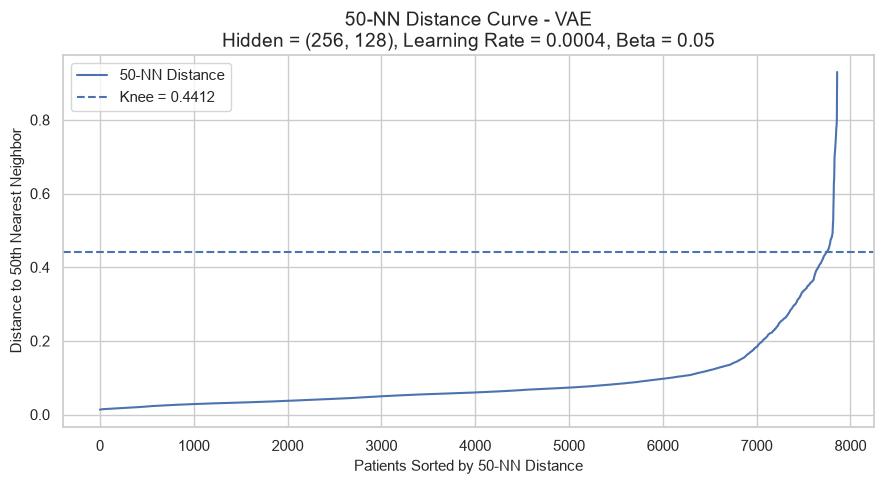

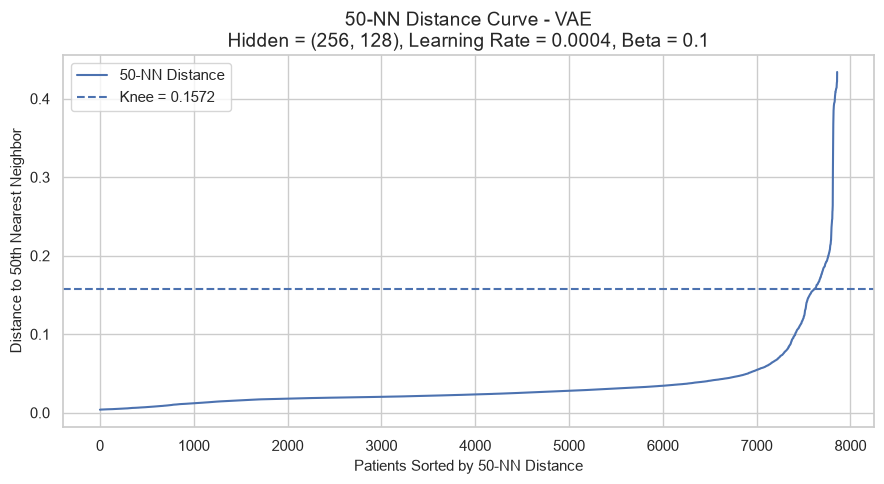

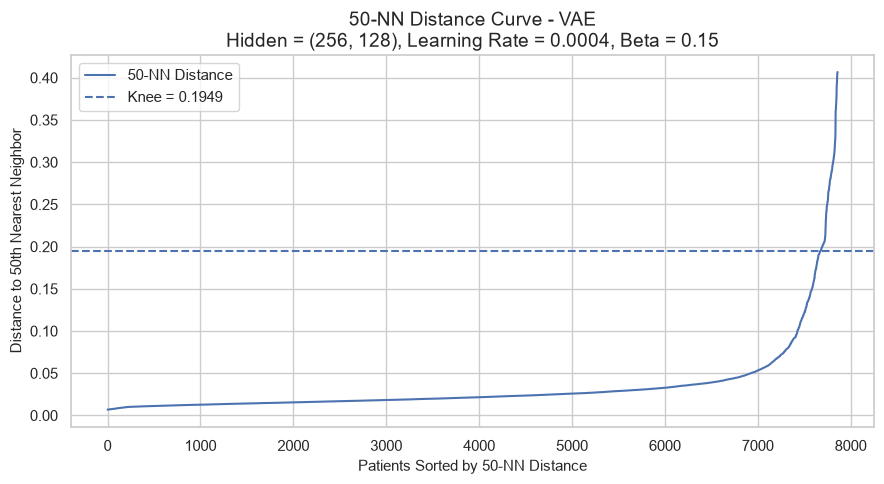

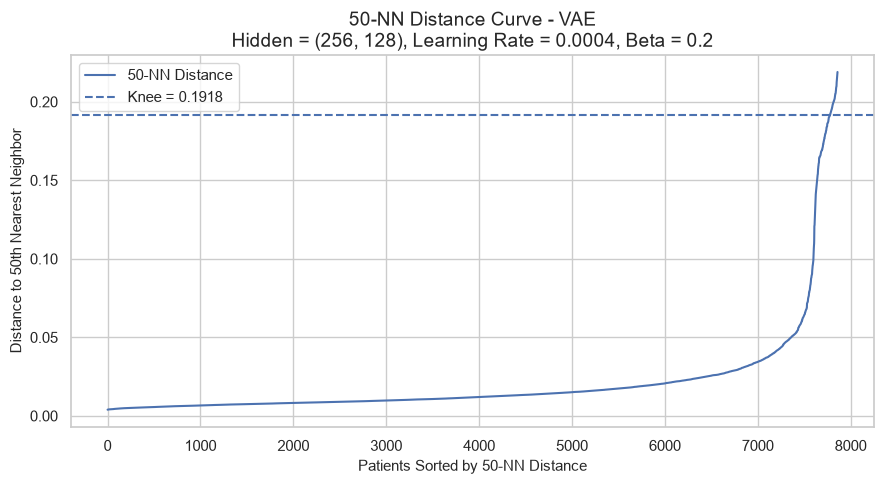

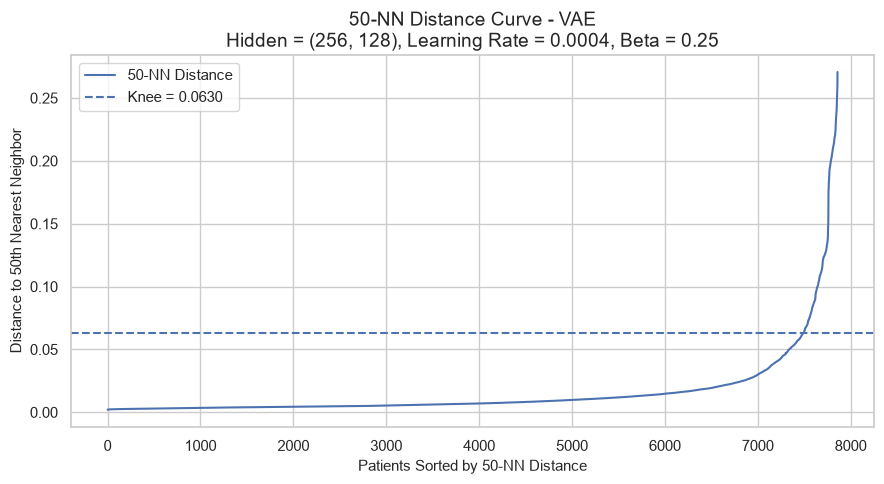

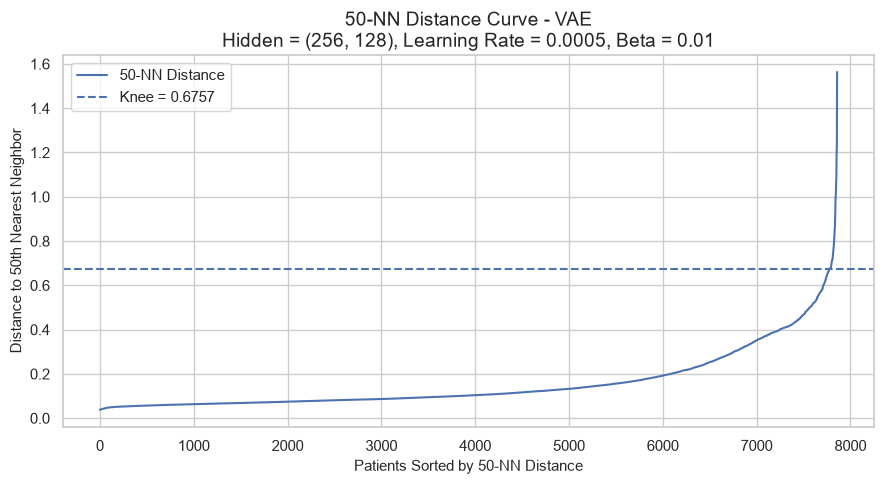

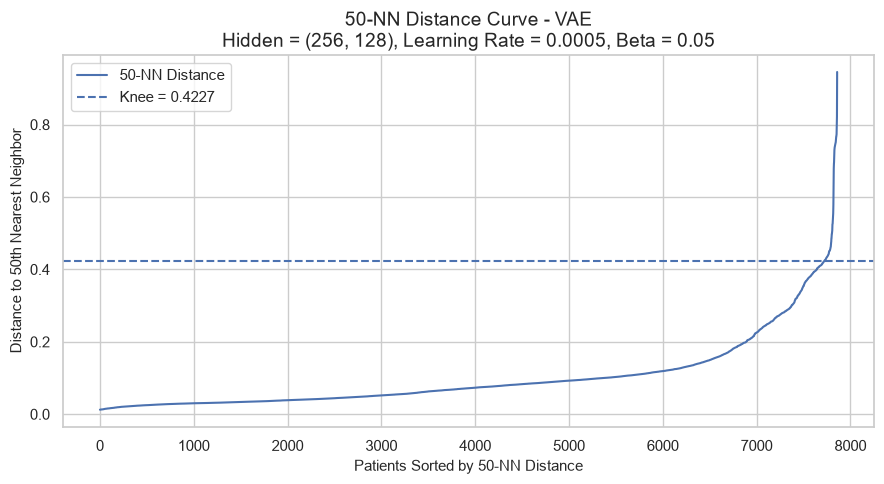

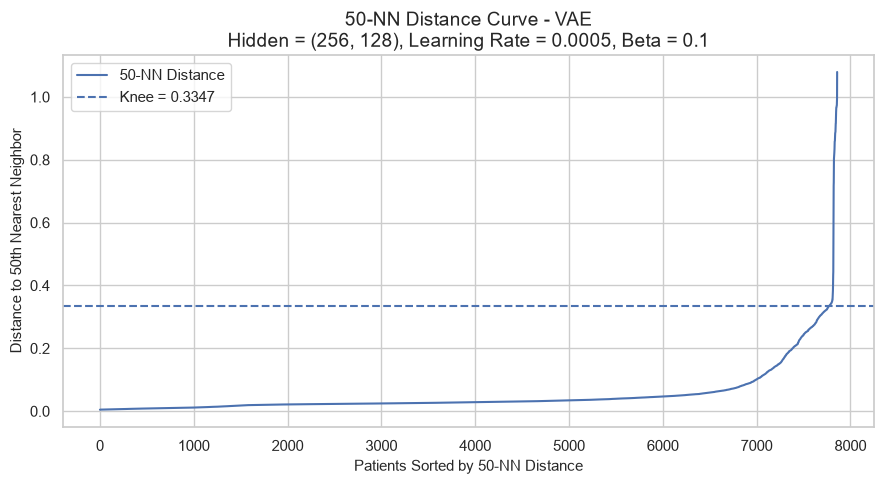

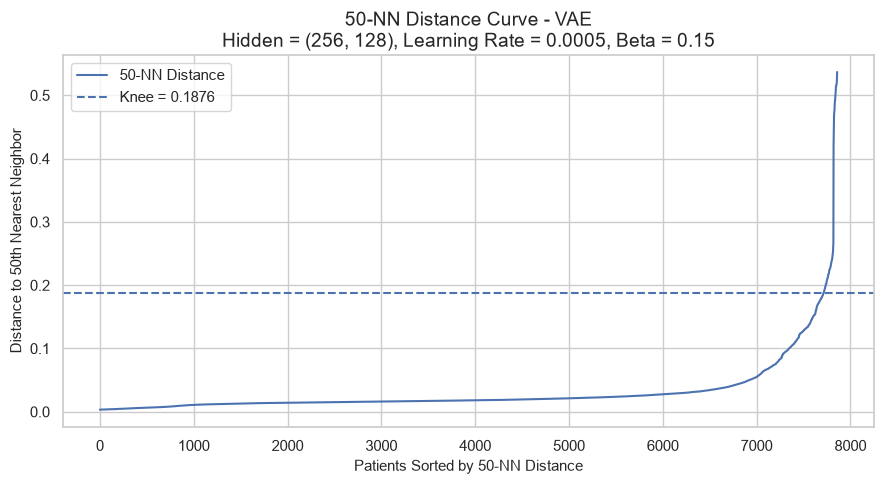

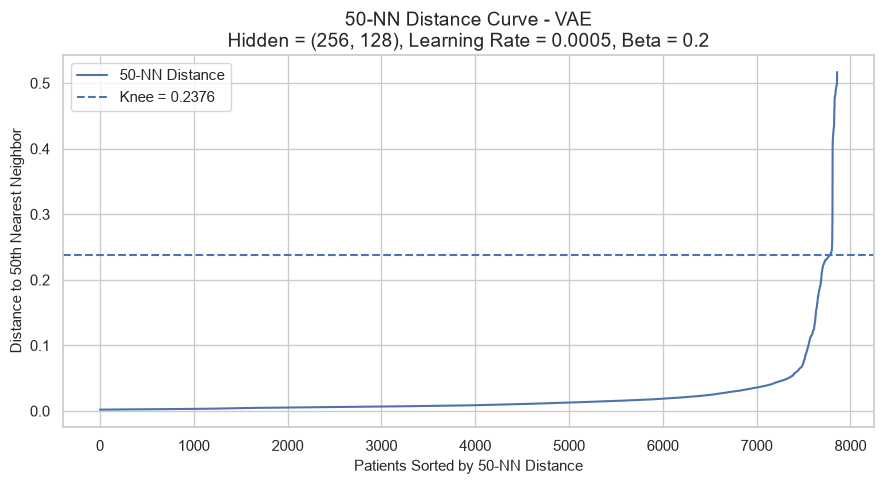

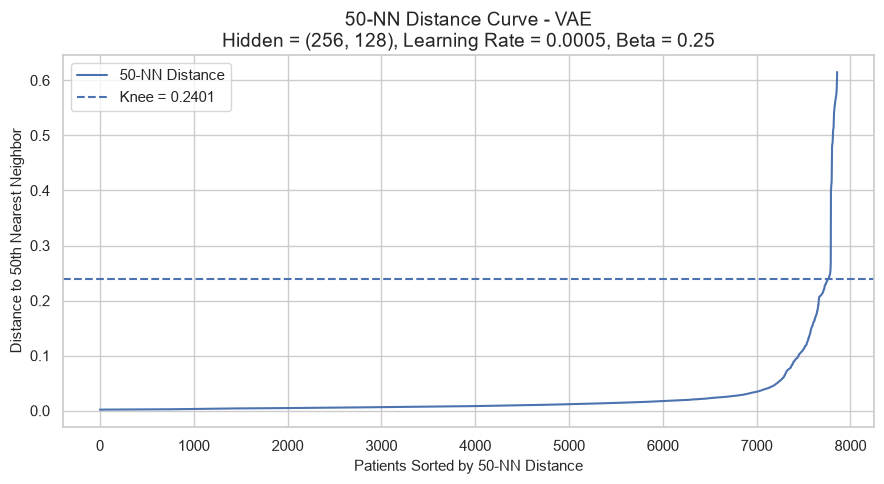

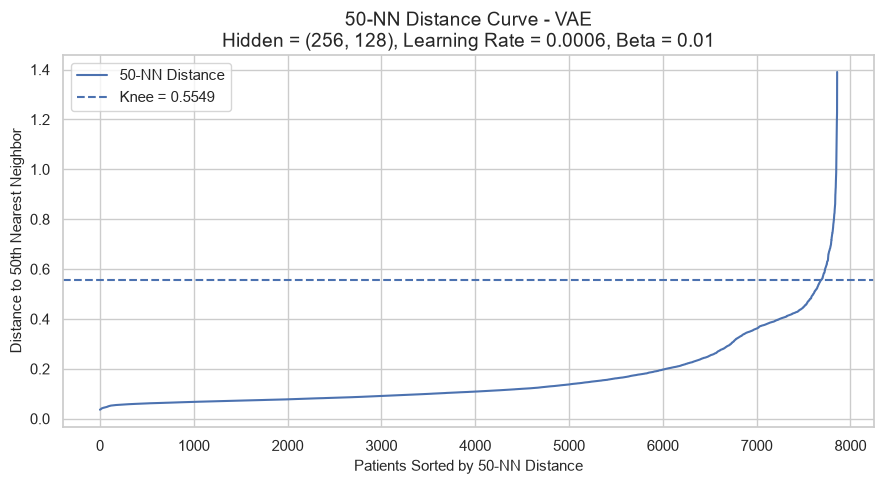

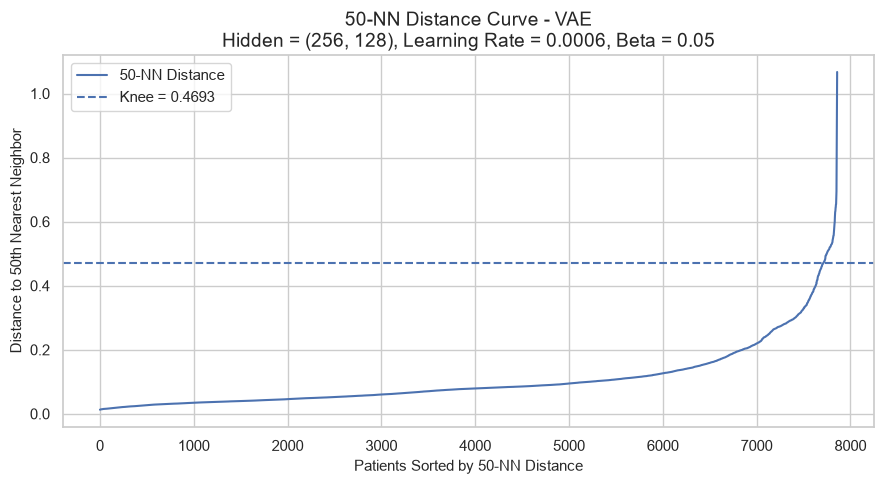

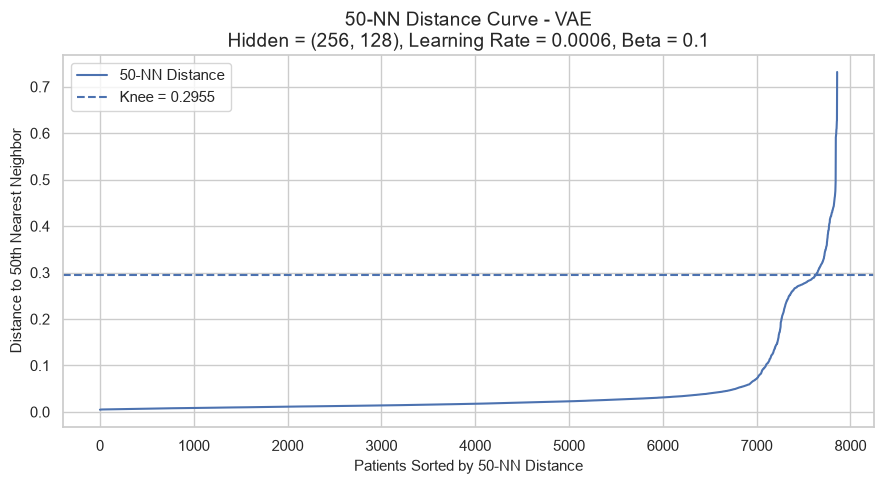

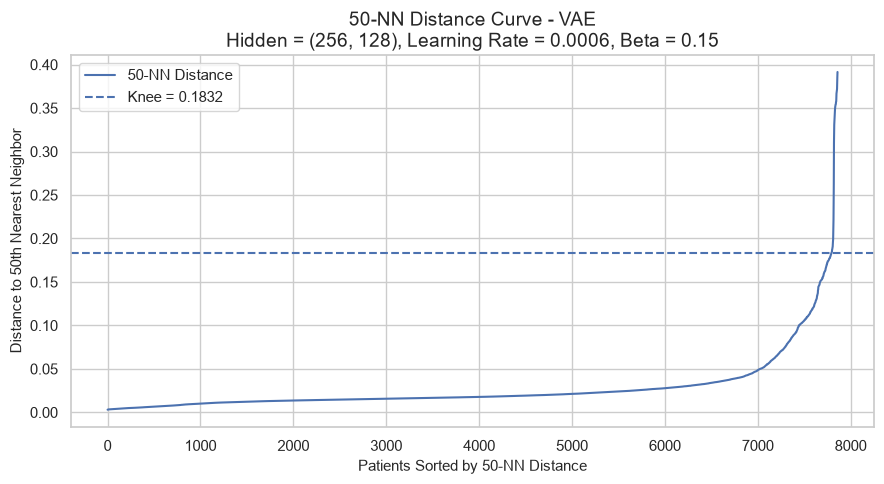

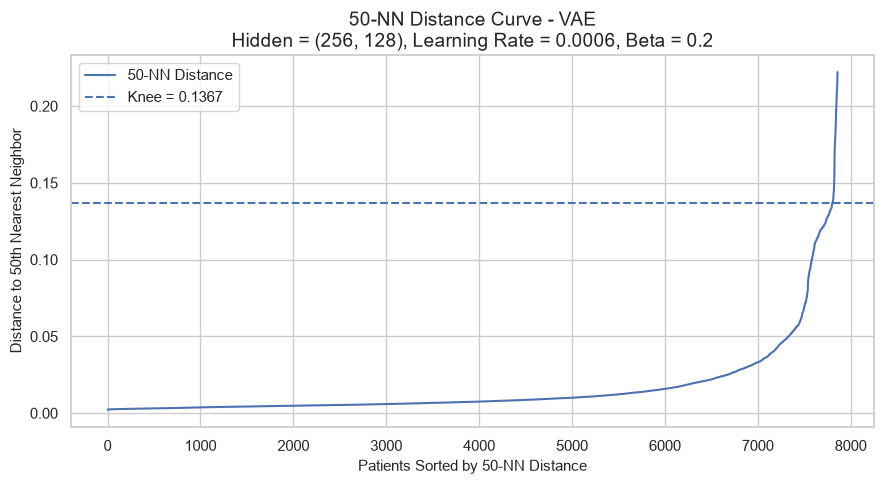

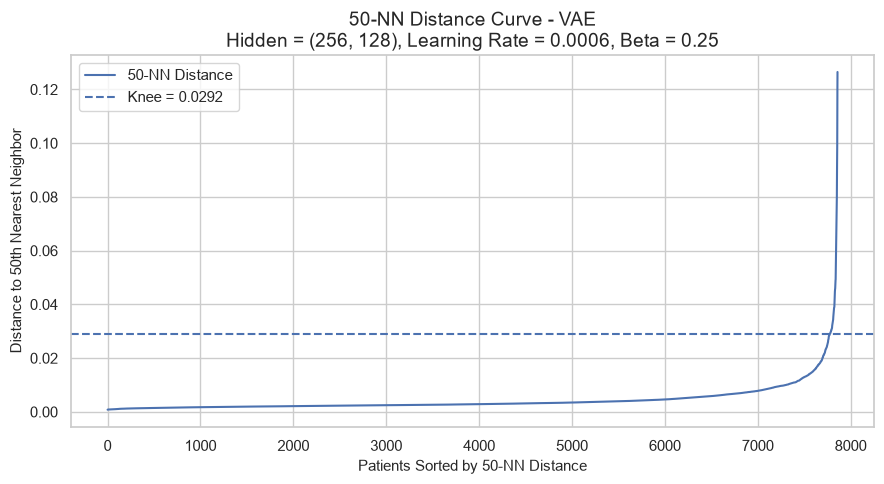

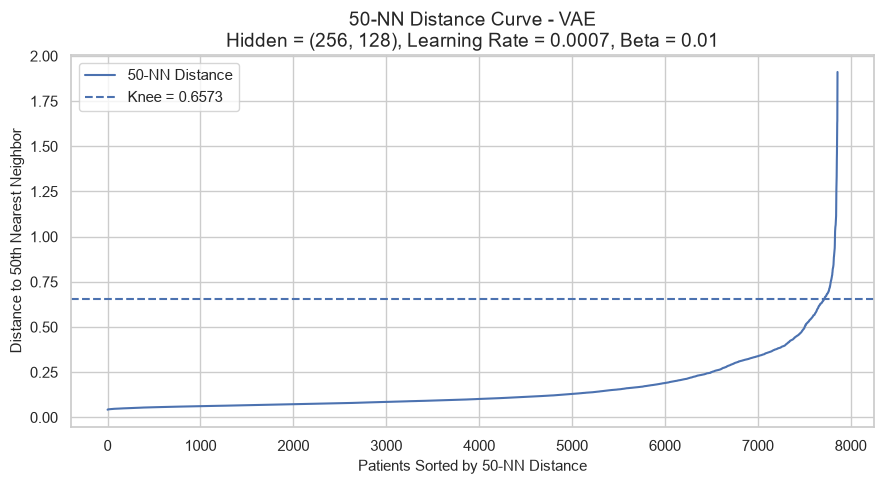

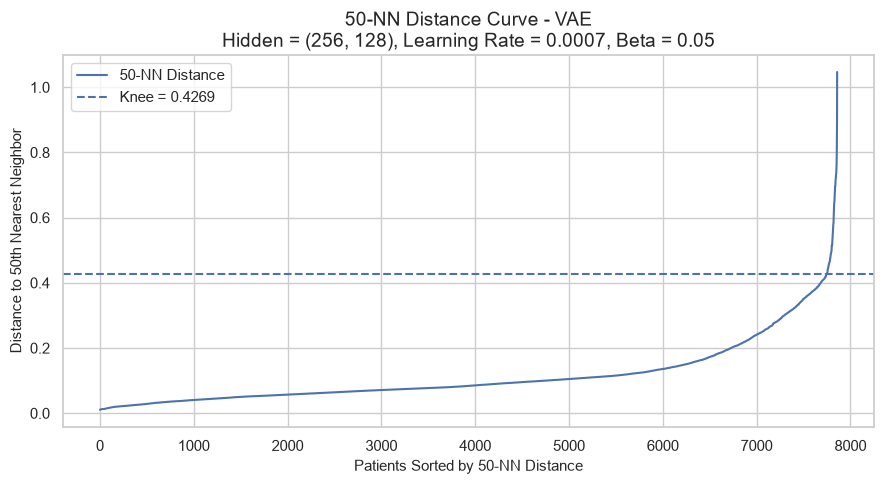

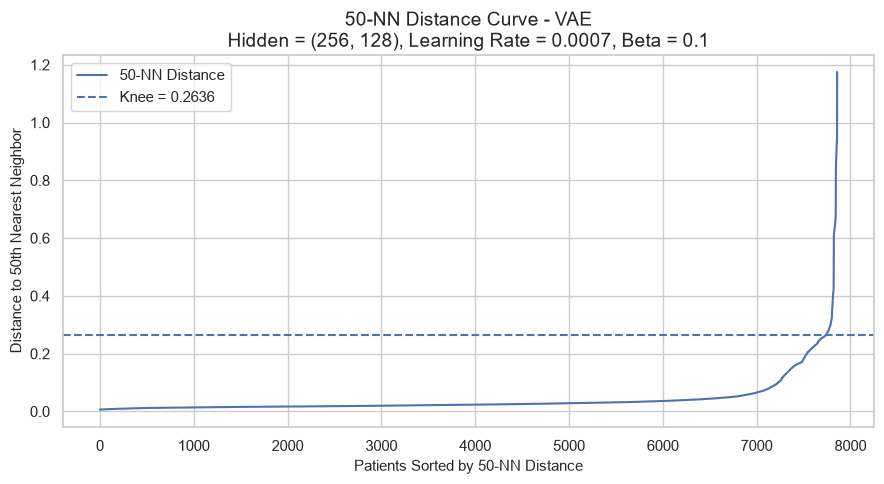

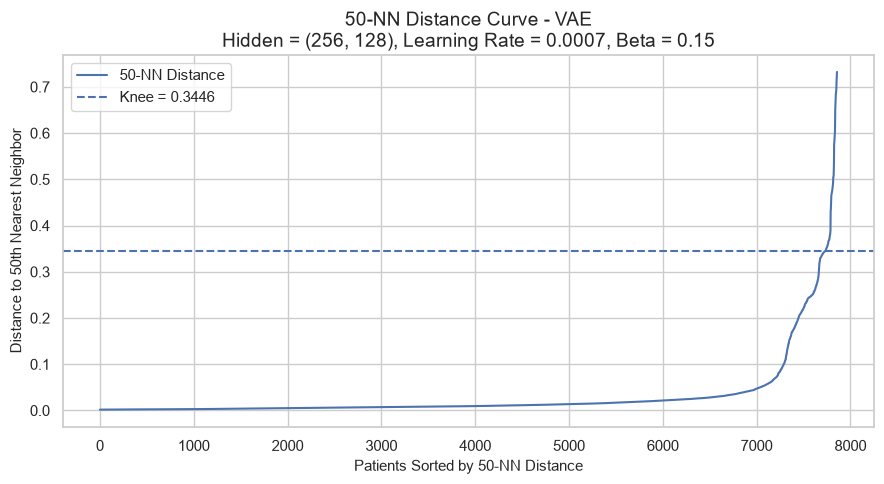

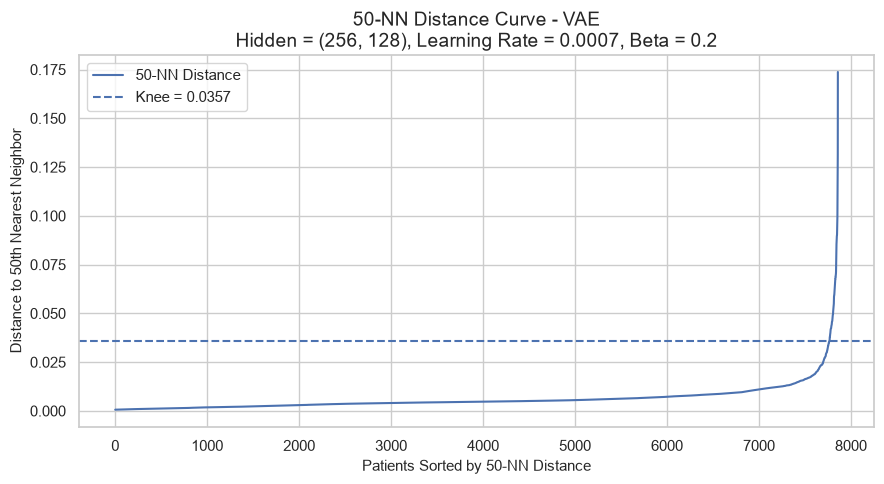

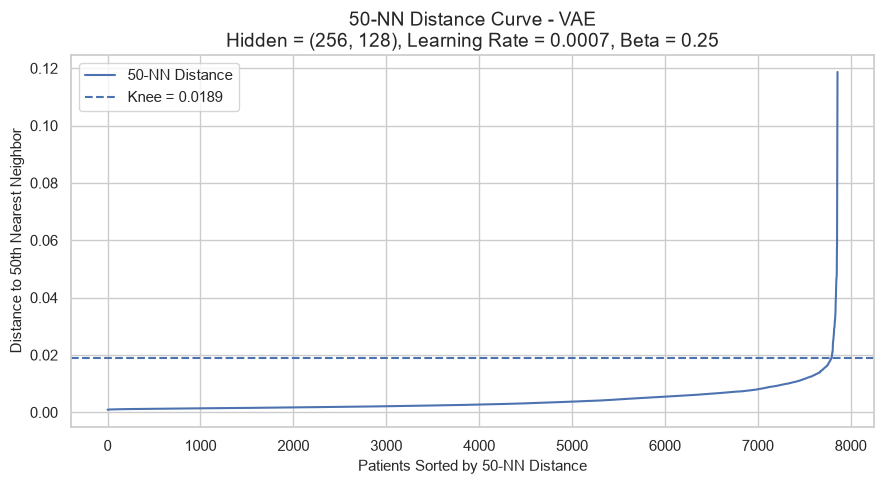

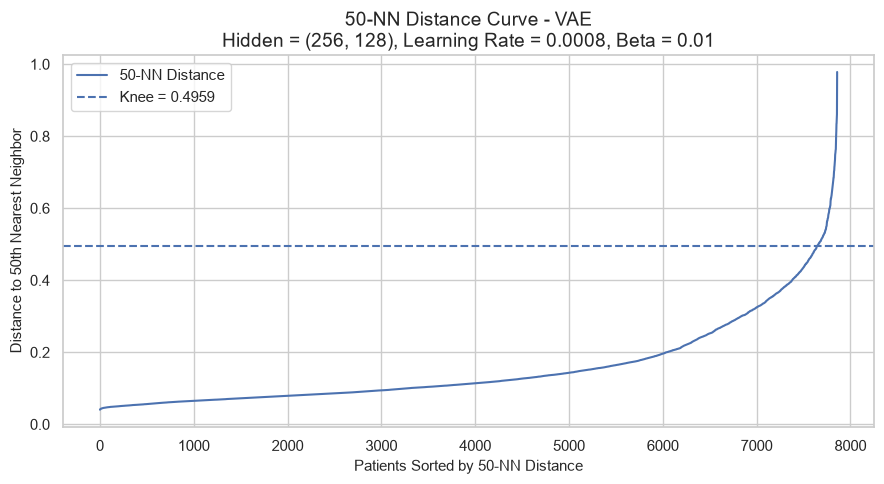

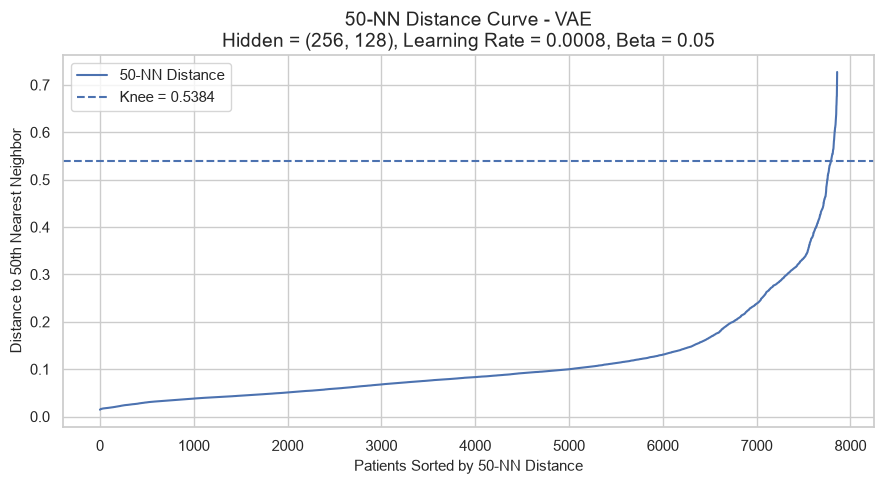

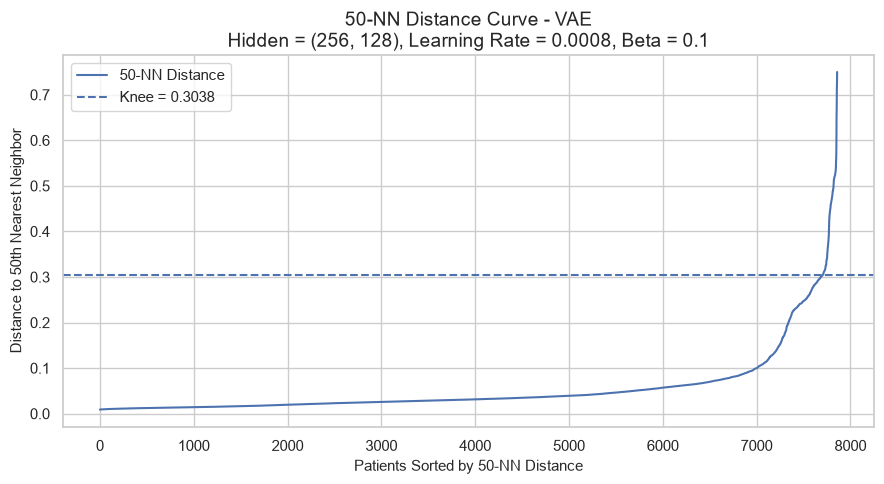

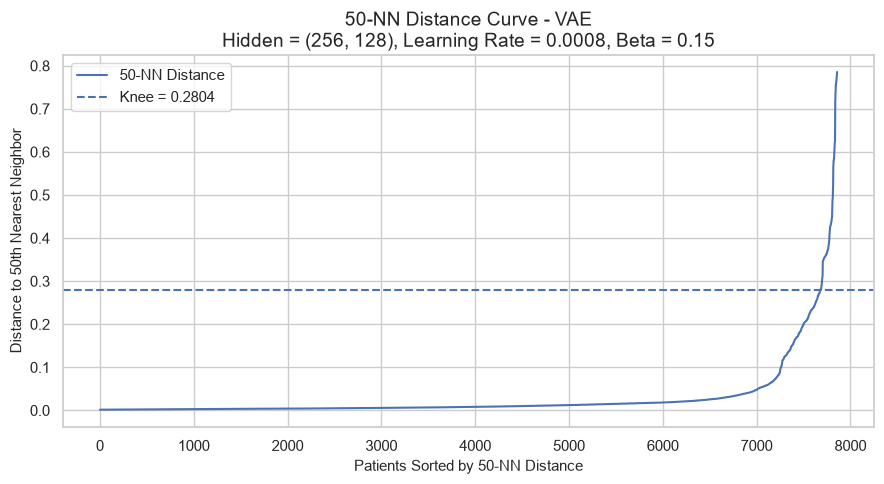

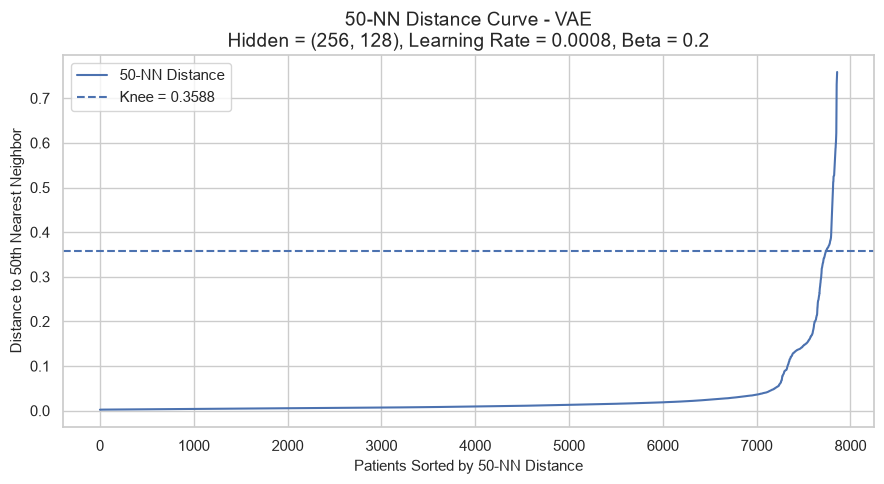

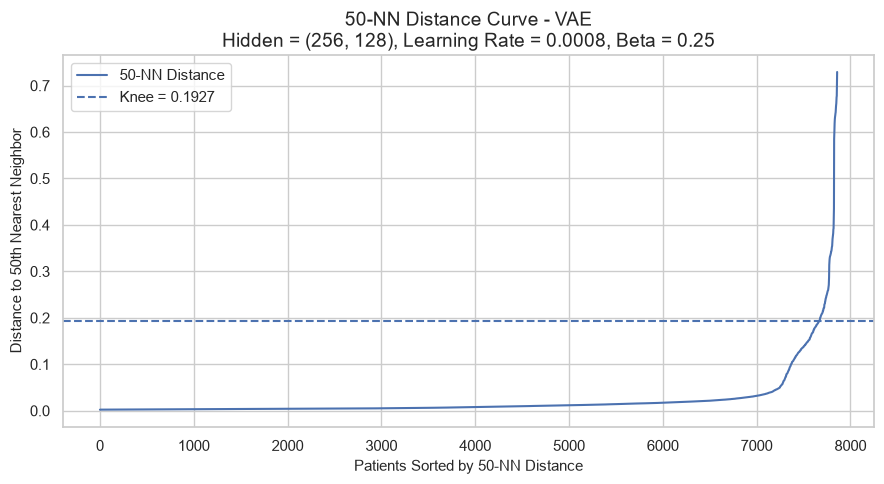

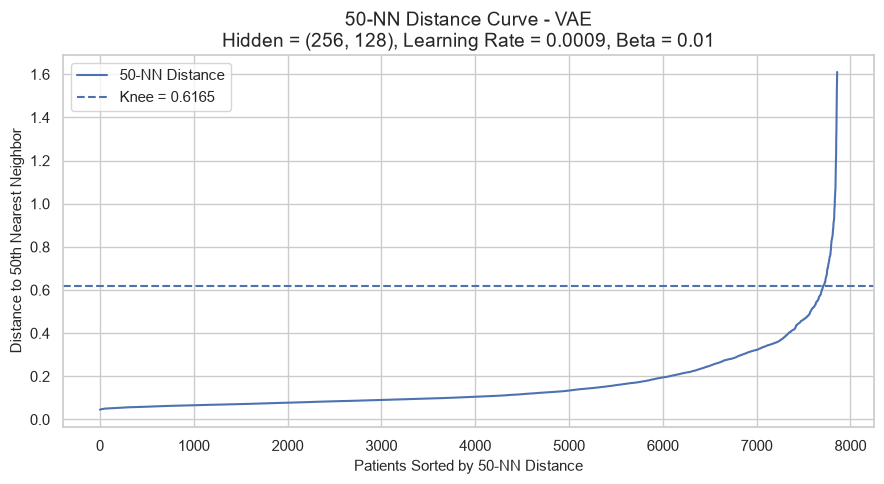

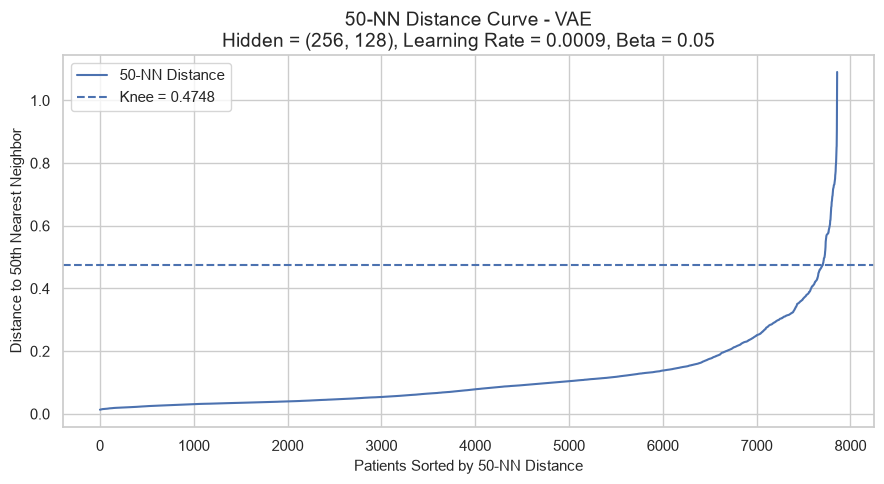

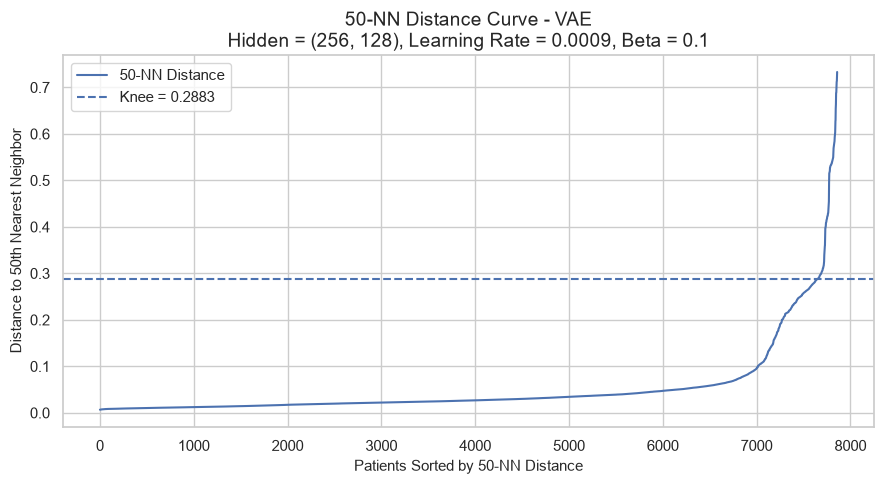

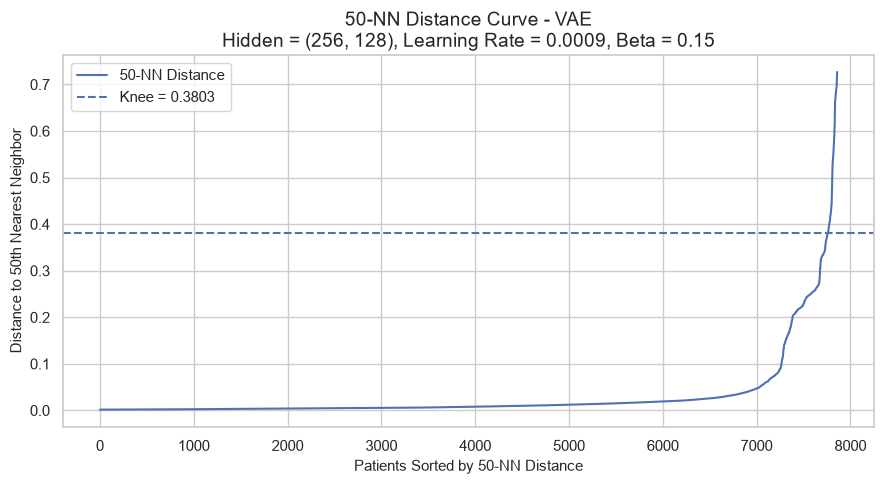

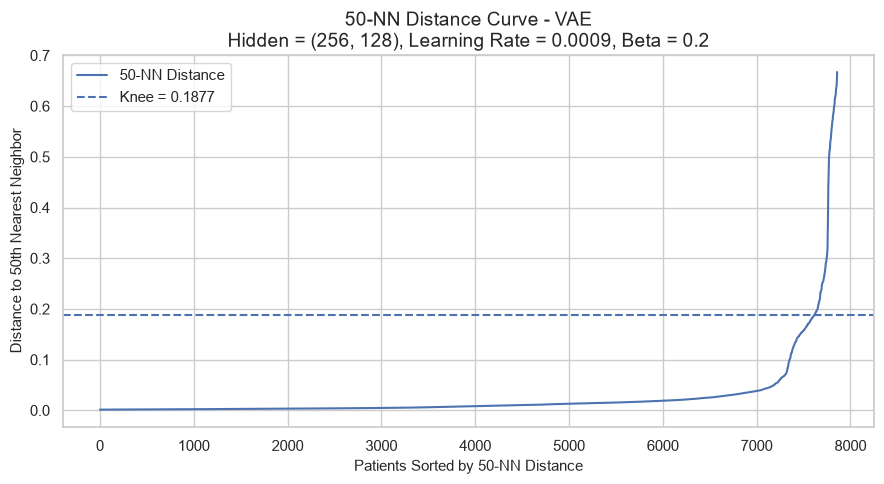

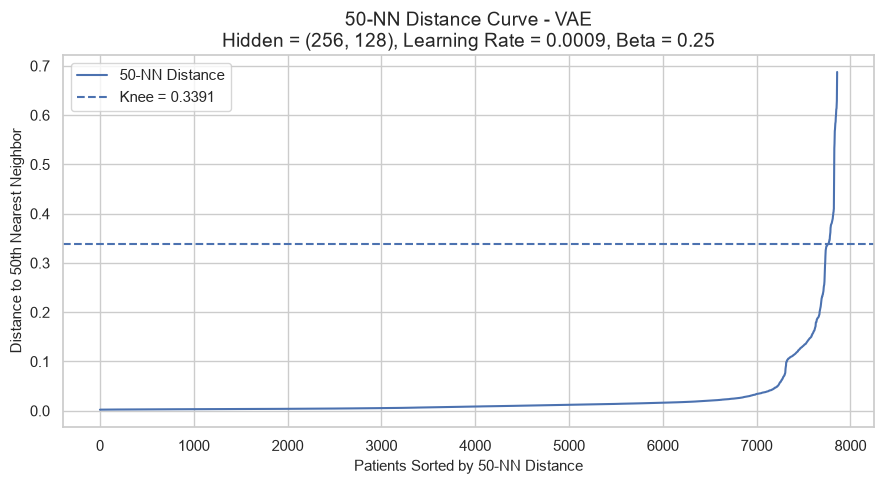

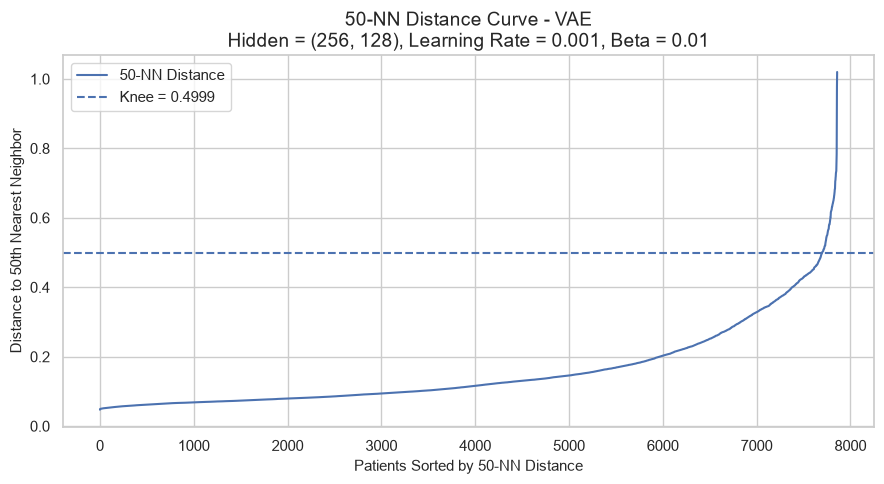

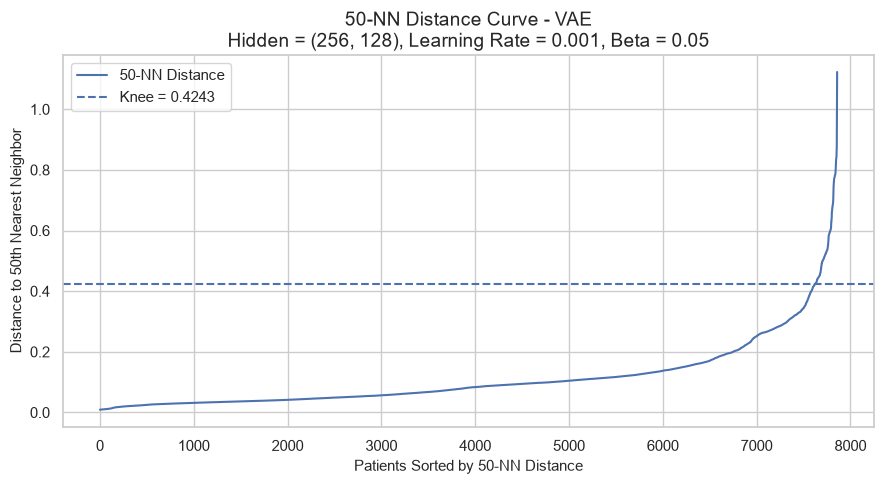

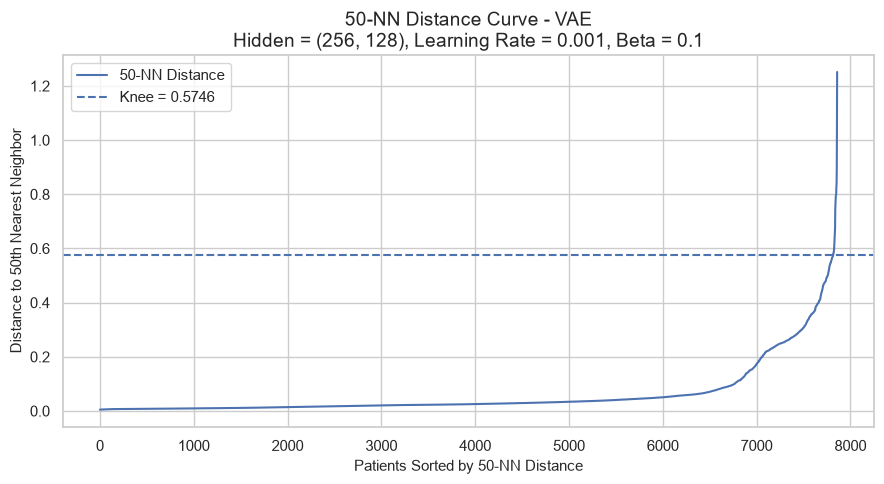

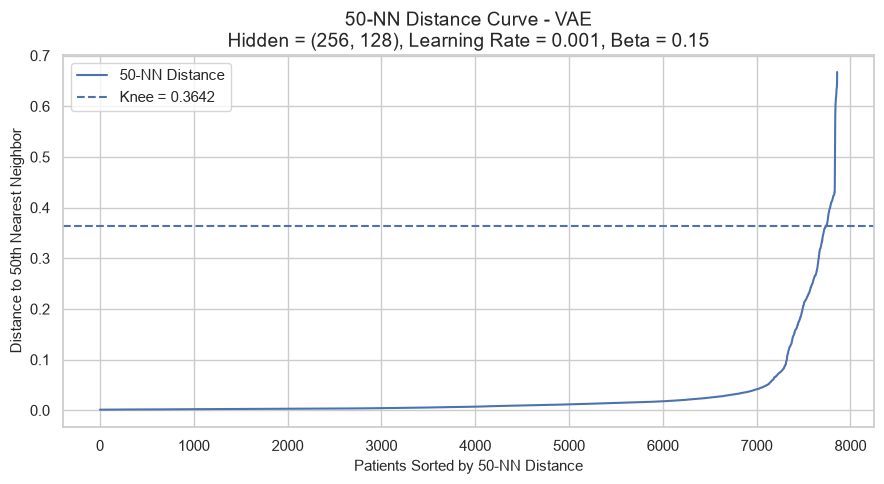

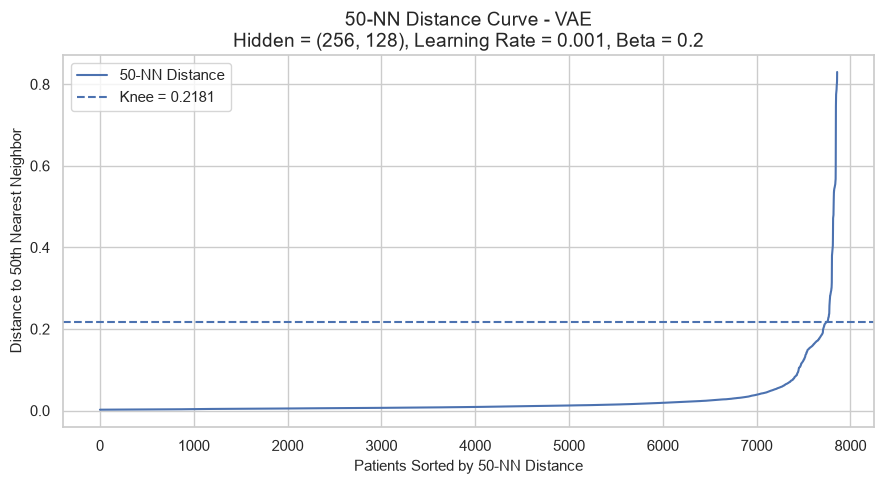

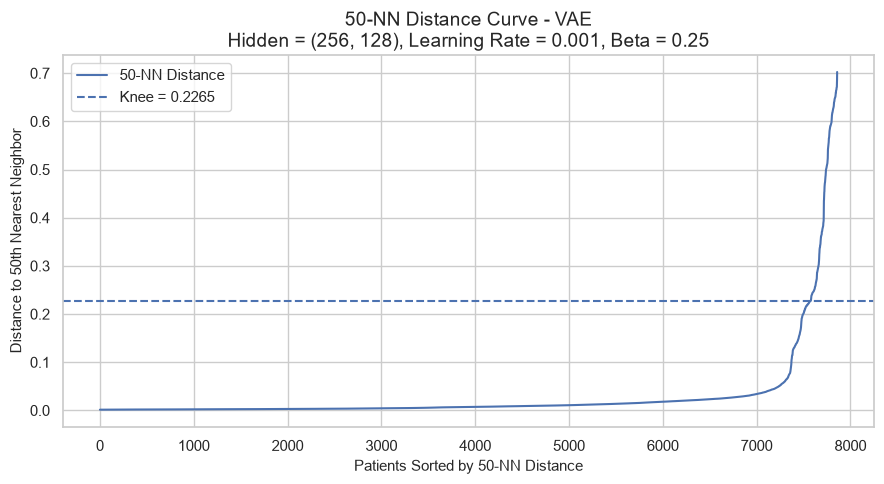

In [40]:
# ---------------------------------------------------------
# Plot 50-NN distance curve for each VAE configuration
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            # Configuration key
            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            # Get sorted 50-NN distances
            k_distances = vae_knn_distances[
                config_key
            ]

            # Get detected knee value
            knee_value = vae_knee_values[
                config_key
            ]

            # X-axis values
            x_values = np.arange(len(k_distances))


            # -------------------------------------------------
            # Create plot
            # -------------------------------------------------

            plt.figure(figsize=(9, 5))

            sns.lineplot(
                x=x_values,
                y=k_distances,
                label="50-NN Distance"
            )


            # -------------------------------------------------
            # Add detected knee line
            # -------------------------------------------------

            if not np.isnan(knee_value):

                plt.axhline(
                    y=knee_value,
                    linestyle="--",
                    label=f"Knee = {knee_value:.4f}"
                )


            # -------------------------------------------------
            # Plot formatting
            # -------------------------------------------------

            plt.title(
                f"50-NN Distance Curve - VAE\n"
                f"Hidden = {hidden_dims}, "
                f"Learning Rate = {learning_rate}, "
                f"Beta = {beta}",
                fontsize=14
            )

            plt.xlabel(
                "Patients Sorted by 50-NN Distance",
                fontsize=11
            )

            plt.ylabel(
                "Distance to 50th Nearest Neighbor",
                fontsize=11
            )

            plt.legend()
            plt.tight_layout()


            # -------------------------------------------------
            # Prepare file name
            # -------------------------------------------------

            hidden_name = (
                f"{hidden_dims[0]}_{hidden_dims[1]}"
            )

            lr_name = str(learning_rate).replace(".", "_")
            beta_name = str(beta).replace(".", "_")


            # -------------------------------------------------
            # Save plot
            # -------------------------------------------------

            plot_file = (
                VAE_PLOTS_DIR
                / (
                    f"knn_curve_hidden_{hidden_name}"
                    f"_lr_{lr_name}"
                    f"_beta_{beta_name}.png"
                )
            )

            plt.savefig(
                plot_file,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()

## Create DBSCAN Epsilon Candidates from the VAE Knee Values

In [41]:
# ---------------------------------------------------------
# Store epsilon candidates for each VAE configuration
# ---------------------------------------------------------

vae_epsilon_candidates = {}


# ---------------------------------------------------------
# Create epsilon values from each knee
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            # Configuration key
            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            # Get knee value
            knee_value = vae_knee_values[
                config_key
            ]

            # Skip if no knee was detected
            if np.isnan(knee_value):

                print(
                    f"Hidden = {hidden_dims}, "
                    f"Learning rate = {learning_rate}, "
                    f"Beta = {beta}: No knee detected"
                )

                continue


            # -------------------------------------------------
            # Calculate epsilon candidates
            # -------------------------------------------------

            epsilon_values = [
                0.80 * knee_value,
                0.90 * knee_value,
                1.00 * knee_value
            ]


            # -------------------------------------------------
            # Store epsilon values
            # -------------------------------------------------

            vae_epsilon_candidates[
                config_key
            ] = epsilon_values


            # -------------------------------------------------
            # Display values
            # -------------------------------------------------

            print(
                f"\nHidden = {hidden_dims}, "
                f"Learning rate = {learning_rate}, "
                f"Beta = {beta}"
            )

            print(f"Knee value = {knee_value:.4f}")

            print("Epsilon candidates:")

            for epsilon in epsilon_values:
                print(f"- {epsilon:.4f}")


Hidden = (128, 64), Learning rate = 0.0001, Beta = 0.01
Knee value = 0.4001
Epsilon candidates:
- 0.3200
- 0.3601
- 0.4001

Hidden = (128, 64), Learning rate = 0.0001, Beta = 0.05
Knee value = 0.1514
Epsilon candidates:
- 0.1211
- 0.1363
- 0.1514

Hidden = (128, 64), Learning rate = 0.0001, Beta = 0.1
Knee value = 0.1228
Epsilon candidates:
- 0.0982
- 0.1105
- 0.1228

Hidden = (128, 64), Learning rate = 0.0001, Beta = 0.15
Knee value = 0.3622
Epsilon candidates:
- 0.2898
- 0.3260
- 0.3622

Hidden = (128, 64), Learning rate = 0.0001, Beta = 0.2
Knee value = 0.1620
Epsilon candidates:
- 0.1296
- 0.1458
- 0.1620

Hidden = (128, 64), Learning rate = 0.0001, Beta = 0.25
Knee value = 0.0829
Epsilon candidates:
- 0.0663
- 0.0746
- 0.0829

Hidden = (128, 64), Learning rate = 0.0002, Beta = 0.01
Knee value = 0.7423
Epsilon candidates:
- 0.5938
- 0.6681
- 0.7423

Hidden = (128, 64), Learning rate = 0.0002, Beta = 0.05
Knee value = 0.2656
Epsilon candidates:
- 0.2125
- 0.2391
- 0.2656

Hidden = 

## Run DBSCAN for Every VAE and Epsilon Combination

In [42]:
# ---------------------------------------------------------
# Store DBSCAN cluster labels
# ---------------------------------------------------------

vae_cluster_labels = {}


# ---------------------------------------------------------
# Run DBSCAN for every VAE configuration
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            # Configuration key
            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            # Skip if no knee was detected
            if config_key not in vae_epsilon_candidates:
                continue

            # Get VAE embedding
            embedding = vae_embeddings[
                config_key
            ]

            # Get epsilon candidates
            epsilon_values = vae_epsilon_candidates[
                config_key
            ]


            # -------------------------------------------------
            # Test each epsilon value
            # -------------------------------------------------

            for multiplier, epsilon in zip(
                EPSILON_MULTIPLIERS,
                epsilon_values
            ):

                print(
                    f"Running DBSCAN: "
                    f"hidden = {hidden_dims}, "
                    f"learning rate = {learning_rate}, "
                    f"beta = {beta}, "
                    f"epsilon = {epsilon:.4f}"
                )


                # -------------------------------------------------
                # Create DBSCAN model
                # -------------------------------------------------

                dbscan_model = DBSCAN(
                    eps=epsilon,
                    min_samples=DBSCAN_MIN_SAMPLES,
                    metric="euclidean"
                )


                # -------------------------------------------------
                # Run clustering
                # -------------------------------------------------

                labels = dbscan_model.fit_predict(
                    embedding
                )


                # -------------------------------------------------
                # Store cluster labels
                # -------------------------------------------------

                vae_cluster_labels[
                    (
                        hidden_dims,
                        learning_rate,
                        beta,
                        multiplier
                    )
                ] = labels


                # -------------------------------------------------
                # Create cluster assignment DataFrame
                # -------------------------------------------------

                cluster_df = pd.DataFrame({
                    "patientunitstayid": patient_ids.values,
                    "cluster": labels
                })


                # -------------------------------------------------
                # Prepare file name
                # -------------------------------------------------

                hidden_name = (
                    f"{hidden_dims[0]}_{hidden_dims[1]}"
                )

                lr_name = str(learning_rate).replace(".", "_")
                beta_name = str(beta).replace(".", "_")

                multiplier_name = int(
                    multiplier * 100
                )


                # -------------------------------------------------
                # Save cluster assignments
                # -------------------------------------------------

                output_file = (
                    VAE_CLUSTER_DIR
                    / (
                        f"vae_hidden_{hidden_name}"
                        f"_lr_{lr_name}"
                        f"_beta_{beta_name}"
                        f"_eps_{multiplier_name}_percent_knee.csv"
                    )
                )

                cluster_df.to_csv(
                    output_file,
                    index=False
                )

                print(f"Saved: {output_file.name}\n")


print("All VAE + DBSCAN configurations completed.")

Running DBSCAN: hidden = (128, 64), learning rate = 0.0001, beta = 0.01, epsilon = 0.3200
Saved: vae_hidden_128_64_lr_0_0001_beta_0_01_eps_80_percent_knee.csv

Running DBSCAN: hidden = (128, 64), learning rate = 0.0001, beta = 0.01, epsilon = 0.3601
Saved: vae_hidden_128_64_lr_0_0001_beta_0_01_eps_90_percent_knee.csv

Running DBSCAN: hidden = (128, 64), learning rate = 0.0001, beta = 0.01, epsilon = 0.4001
Saved: vae_hidden_128_64_lr_0_0001_beta_0_01_eps_100_percent_knee.csv

Running DBSCAN: hidden = (128, 64), learning rate = 0.0001, beta = 0.05, epsilon = 0.1211
Saved: vae_hidden_128_64_lr_0_0001_beta_0_05_eps_80_percent_knee.csv

Running DBSCAN: hidden = (128, 64), learning rate = 0.0001, beta = 0.05, epsilon = 0.1363
Saved: vae_hidden_128_64_lr_0_0001_beta_0_05_eps_90_percent_knee.csv

Running DBSCAN: hidden = (128, 64), learning rate = 0.0001, beta = 0.05, epsilon = 0.1514
Saved: vae_hidden_128_64_lr_0_0001_beta_0_05_eps_100_percent_knee.csv

Running DBSCAN: hidden = (128, 64), le

## Calculate and Save Cluster Statistics for Every VAE Configuration

In [43]:
# ---------------------------------------------------------
# Store cluster statistics
# ---------------------------------------------------------

vae_cluster_statistics = []


# ---------------------------------------------------------
# Calculate statistics for every configuration
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            # Configuration key
            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            # Skip if no knee was detected
            if config_key not in vae_epsilon_candidates:
                continue

            # Get epsilon candidates
            epsilon_values = vae_epsilon_candidates[
                config_key
            ]


            # -------------------------------------------------
            # Evaluate each epsilon value
            # -------------------------------------------------

            for multiplier, epsilon in zip(
                EPSILON_MULTIPLIERS,
                epsilon_values
            ):

                # Get DBSCAN cluster labels
                labels = vae_cluster_labels[
                    (
                        hidden_dims,
                        learning_rate,
                        beta,
                        multiplier
                    )
                ]


                # -------------------------------------------------
                # Number of clusters
                # -------------------------------------------------

                unique_labels = np.unique(labels)

                # Exclude -1 because it represents outliers
                cluster_labels = unique_labels[
                    unique_labels != -1
                ]

                number_of_clusters = len(
                    cluster_labels
                )


                # -------------------------------------------------
                # Outlier information
                # -------------------------------------------------

                number_of_outliers = np.sum(
                    labels == -1
                )

                outlier_percentage = (
                    number_of_outliers / len(labels)
                ) * 100


                # -------------------------------------------------
                # Smallest cluster size
                # -------------------------------------------------

                if number_of_clusters > 0:

                    cluster_sizes = [
                        np.sum(labels == cluster)
                        for cluster in cluster_labels
                    ]

                    smallest_cluster_size = min(
                        cluster_sizes
                    )

                else:

                    smallest_cluster_size = 0


                # -------------------------------------------------
                # Store results
                # -------------------------------------------------

                vae_cluster_statistics.append({
                    "hidden_layer_1": hidden_dims[0],
                    "hidden_layer_2": hidden_dims[1],
                    "learning_rate": learning_rate,
                    "beta": beta,
                    "epsilon_multiplier": multiplier,
                    "epsilon": epsilon,
                    "number_of_clusters": number_of_clusters,
                    "number_of_outliers": number_of_outliers,
                    "outlier_percentage": outlier_percentage,
                    "smallest_cluster_size": smallest_cluster_size
                })


# ---------------------------------------------------------
# Convert results to DataFrame
# ---------------------------------------------------------

vae_cluster_statistics_df = pd.DataFrame(
    vae_cluster_statistics
)


# ---------------------------------------------------------
# Save cluster statistics table
# ---------------------------------------------------------

cluster_statistics_file = (
    VAE_CLUSTER_DIR
    / "vae_cluster_statistics.csv"
)

vae_cluster_statistics_df.to_csv(
    cluster_statistics_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("VAE cluster statistics saved to:")
print(cluster_statistics_file)

display(vae_cluster_statistics_df)

VAE cluster statistics saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\vae\vae_cluster_statistics.csv


,hidden_layer_1,hidden_layer_2,learning_rate,beta,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size
0,128,64,0.0001,0.01,0.8,0.320047,18,161,2.048607,58
1,128,64,0.0001,0.01,0.9,0.360053,14,158,2.010434,58
2,128,64,0.0001,0.01,1.0,0.400059,14,100,1.272427,55
3,128,64,0.0001,0.05,0.8,0.121129,17,162,2.061331,58
4,128,64,0.0001,0.05,0.9,0.136270,17,131,1.666879,59
...,...,...,...,...,...,...,...,...,...,...
355,256,128,0.0010,0.20,0.9,0.196297,16,122,1.552360,70
356,256,128,0.0010,0.20,1.0,0.218108,15,57,0.725283,80
357,256,128,0.0010,0.25,0.8,0.181237,16,331,4.211732,51
358,256,128,0.0010,0.25,0.9,0.203892,17,249,3.168342,51


## Calculate and Save Internal Clustering Metrics

In [44]:
# ---------------------------------------------------------
# Store internal metric results
# ---------------------------------------------------------

vae_metric_results = []


# ---------------------------------------------------------
# Calculate metrics for every configuration
# ---------------------------------------------------------

for hidden_dims in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            # Configuration key
            config_key = (
                hidden_dims,
                learning_rate,
                beta
            )

            # Skip if no knee was detected
            if config_key not in vae_epsilon_candidates:
                continue

            # Get epsilon candidates
            epsilon_values = vae_epsilon_candidates[
                config_key
            ]


            # -------------------------------------------------
            # Evaluate each epsilon value
            # -------------------------------------------------

            for multiplier, epsilon in zip(
                EPSILON_MULTIPLIERS,
                epsilon_values
            ):

                # Get VAE embedding
                embedding = vae_embeddings[
                    config_key
                ]

                # Get DBSCAN cluster labels
                labels = vae_cluster_labels[
                    (
                        hidden_dims,
                        learning_rate,
                        beta,
                        multiplier
                    )
                ]


                # -------------------------------------------------
                # Remove DBSCAN outliers
                # -------------------------------------------------

                non_outlier_mask = labels != -1

                embedding_clean = embedding[
                    non_outlier_mask
                ]

                labels_clean = labels[
                    non_outlier_mask
                ]


                # -------------------------------------------------
                # Count remaining clusters
                # -------------------------------------------------

                number_of_clusters = len(
                    np.unique(labels_clean)
                )


                # -------------------------------------------------
                # Calculate internal metrics
                # -------------------------------------------------

                if number_of_clusters >= 2:

                    silhouette = silhouette_score(
                        embedding_clean,
                        labels_clean
                    )

                    davies_bouldin = davies_bouldin_score(
                        embedding_clean,
                        labels_clean
                    )

                    calinski_harabasz = calinski_harabasz_score(
                        embedding_clean,
                        labels_clean
                    )

                else:

                    silhouette = np.nan
                    davies_bouldin = np.nan
                    calinski_harabasz = np.nan


                # -------------------------------------------------
                # Store results
                # -------------------------------------------------

                vae_metric_results.append({
                    "hidden_layer_1": hidden_dims[0],
                    "hidden_layer_2": hidden_dims[1],
                    "learning_rate": learning_rate,
                    "beta": beta,
                    "epsilon_multiplier": multiplier,
                    "epsilon": epsilon,
                    "silhouette_score": silhouette,
                    "davies_bouldin_index": davies_bouldin,
                    "calinski_harabasz_index": calinski_harabasz
                })


# ---------------------------------------------------------
# Convert results to DataFrame
# ---------------------------------------------------------

vae_metric_results_df = pd.DataFrame(
    vae_metric_results
)


# ---------------------------------------------------------
# Save internal metrics table
# ---------------------------------------------------------

metric_results_file = (
    VAE_CLUSTER_DIR
    / "vae_internal_metrics.csv"
)

vae_metric_results_df.to_csv(
    metric_results_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("VAE internal metrics saved to:")
print(metric_results_file)

display(vae_metric_results_df)

VAE internal metrics saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\vae\vae_internal_metrics.csv


,hidden_layer_1,hidden_layer_2,learning_rate,beta,epsilon_multiplier,epsilon,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,128,64,0.0001,0.01,0.8,0.320047,0.690365,0.338956,18464.249382
1,128,64,0.0001,0.01,0.9,0.360053,0.560519,0.481130,8194.045168
2,128,64,0.0001,0.01,1.0,0.400059,0.531063,0.516812,7736.005753
3,128,64,0.0001,0.05,0.8,0.121129,0.754592,0.320715,21135.547971
4,128,64,0.0001,0.05,0.9,0.136270,0.753258,0.324246,21101.293782
...,...,...,...,...,...,...,...,...,...
355,256,128,0.0010,0.20,0.9,0.196297,0.875834,0.375919,76329.574264
356,256,128,0.0010,0.20,1.0,0.218108,0.863416,0.405670,56549.446927
357,256,128,0.0010,0.25,0.8,0.181237,0.951768,0.165151,567286.989475
358,256,128,0.0010,0.25,0.9,0.203892,0.944259,0.256055,430141.298949


## Combine Cluster Statistics and Internal Metrics

In [45]:
# ---------------------------------------------------------
# Combine cluster statistics and internal metrics
# ---------------------------------------------------------

vae_tuning_results = pd.merge(
    vae_cluster_statistics_df,
    vae_metric_results_df,
    on=[
        "hidden_layer_1",
        "hidden_layer_2",
        "learning_rate",
        "beta",
        "epsilon_multiplier",
        "epsilon"
    ]
)


# ---------------------------------------------------------
# Save complete VAE tuning results
# ---------------------------------------------------------

tuning_results_file = (
    VAE_RESULTS_DIR
    / "vae_hyperparameter_tuning_results.csv"
)

vae_tuning_results.to_csv(
    tuning_results_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("Complete VAE tuning results saved to:")
print(tuning_results_file)

display(vae_tuning_results)

Complete VAE tuning results saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\vae\vae_hyperparameter_tuning_results.csv


,hidden_layer_1,hidden_layer_2,learning_rate,beta,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,128,64,0.0001,0.01,0.8,0.320047,18,161,2.048607,58,0.690365,0.338956,18464.249382
1,128,64,0.0001,0.01,0.9,0.360053,14,158,2.010434,58,0.560519,0.481130,8194.045168
2,128,64,0.0001,0.01,1.0,0.400059,14,100,1.272427,55,0.531063,0.516812,7736.005753
3,128,64,0.0001,0.05,0.8,0.121129,17,162,2.061331,58,0.754592,0.320715,21135.547971
4,128,64,0.0001,0.05,0.9,0.136270,17,131,1.666879,59,0.753258,0.324246,21101.293782
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,256,128,0.0010,0.20,0.9,0.196297,16,122,1.552360,70,0.875834,0.375919,76329.574264
356,256,128,0.0010,0.20,1.0,0.218108,15,57,0.725283,80,0.863416,0.405670,56549.446927
357,256,128,0.0010,0.25,0.8,0.181237,16,331,4.211732,51,0.951768,0.165151,567286.989475
358,256,128,0.0010,0.25,0.9,0.203892,17,249,3.168342,51,0.944259,0.256055,430141.298949


## Apply Validity Conditions

In [46]:
# ---------------------------------------------------------
# Apply validity conditions
# ---------------------------------------------------------

vae_tuning_results["valid_model"] = (

    # At least 2 clusters
    (vae_tuning_results["number_of_clusters"] >= 2)

    &

    # Outlier percentage must be 5% or less
    (vae_tuning_results["outlier_percentage"] <= 5)

    &

    # Smallest cluster must contain at least 50 patients
    (vae_tuning_results["smallest_cluster_size"] >= 50)

    &

    # Internal metrics must be available
    (vae_tuning_results["silhouette_score"].notna())

    &

    (vae_tuning_results["davies_bouldin_index"].notna())

    &

    (vae_tuning_results["calinski_harabasz_index"].notna())
)


# ---------------------------------------------------------
# Keep only valid models
# ---------------------------------------------------------

vae_valid_models = vae_tuning_results[
    vae_tuning_results["valid_model"]
].copy()


# ---------------------------------------------------------
# Display summary
# ---------------------------------------------------------

print("Total configurations:",
      len(vae_tuning_results))

print("Valid configurations:",
      len(vae_valid_models))

print("Invalid configurations:",
      len(vae_tuning_results) - len(vae_valid_models))


print("\nValid VAE + DBSCAN configurations:")

display(vae_valid_models)

Total configurations: 360
Valid configurations: 313
Invalid configurations: 47

Valid VAE + DBSCAN configurations:


,hidden_layer_1,hidden_layer_2,learning_rate,beta,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,valid_model
0,128,64,0.0001,0.01,0.8,0.320047,18,161,2.048607,58,0.690365,0.338956,18464.249382,True
1,128,64,0.0001,0.01,0.9,0.360053,14,158,2.010434,58,0.560519,0.481130,8194.045168,True
2,128,64,0.0001,0.01,1.0,0.400059,14,100,1.272427,55,0.531063,0.516812,7736.005753,True
3,128,64,0.0001,0.05,0.8,0.121129,17,162,2.061331,58,0.754592,0.320715,21135.547971,True
4,128,64,0.0001,0.05,0.9,0.136270,17,131,1.666879,59,0.753258,0.324246,21101.293782,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,256,128,0.0010,0.20,0.9,0.196297,16,122,1.552360,70,0.875834,0.375919,76329.574264,True
356,256,128,0.0010,0.20,1.0,0.218108,15,57,0.725283,80,0.863416,0.405670,56549.446927,True
357,256,128,0.0010,0.25,0.8,0.181237,16,331,4.211732,51,0.951768,0.165151,567286.989475,True
358,256,128,0.0010,0.25,0.9,0.203892,17,249,3.168342,51,0.944259,0.256055,430141.298949,True


## Rank the Valid VAE + DBSCAN Models

In [47]:
# ---------------------------------------------------------
# Rank valid models using the three internal metrics
# ---------------------------------------------------------

vae_valid_models["silhouette_rank"] = (
    vae_valid_models["silhouette_score"]
    .rank(ascending=False, method="min")
)

vae_valid_models["davies_bouldin_rank"] = (
    vae_valid_models["davies_bouldin_index"]
    .rank(ascending=True, method="min")
)

vae_valid_models["calinski_harabasz_rank"] = (
    vae_valid_models["calinski_harabasz_index"]
    .rank(ascending=False, method="min")
)


# ---------------------------------------------------------
# Calculate combined rank
# ---------------------------------------------------------

vae_valid_models["combined_rank"] = (
    vae_valid_models["silhouette_rank"]
    + vae_valid_models["davies_bouldin_rank"]
    + vae_valid_models["calinski_harabasz_rank"]
)


# ---------------------------------------------------------
# Sort models from best to worst
# ---------------------------------------------------------

vae_ranked_models = vae_valid_models.sort_values(
    by=[
        "combined_rank",
        "outlier_percentage",
        "silhouette_score"
    ],
    ascending=[
        True,   # Lower combined rank is better
        True,   # Lower outlier percentage is better
        False   # Higher silhouette is better
    ]
).reset_index(drop=True)


# ---------------------------------------------------------
# Display ranked models
# ---------------------------------------------------------

display(
    vae_ranked_models[
        [
            "hidden_layer_1",
            "hidden_layer_2",
            "learning_rate",
            "beta",
            "epsilon_multiplier",
            "epsilon",
            "number_of_clusters",
            "outlier_percentage",
            "smallest_cluster_size",
            "silhouette_score",
            "davies_bouldin_index",
            "calinski_harabasz_index",
            "silhouette_rank",
            "davies_bouldin_rank",
            "calinski_harabasz_rank",
            "combined_rank"
        ]
    ]
)

,hidden_layer_1,hidden_layer_2,learning_rate,beta,epsilon_multiplier,epsilon,number_of_clusters,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,silhouette_rank,davies_bouldin_rank,calinski_harabasz_rank,combined_rank
0,256,128,0.0004,0.25,0.9,0.056688,21,3.066548,51,0.938488,0.144631,635372.705302,10.0,7.0,2.0,19.0
1,256,128,0.0004,0.25,0.8,0.050389,22,3.740934,51,0.936704,0.145726,775076.804969,12.0,8.0,1.0,21.0
2,128,64,0.0008,0.25,0.8,0.116401,19,2.672096,51,0.946949,0.162750,623995.924325,2.0,19.0,4.0,25.0
3,256,128,0.0004,0.25,1.0,0.062987,21,2.913857,51,0.937746,0.150581,628250.329637,11.0,11.0,3.0,25.0
4,256,128,0.0010,0.25,0.8,0.181237,16,4.211732,51,0.951768,0.165151,567286.989475,1.0,25.0,7.0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,256,128,0.0003,0.05,0.9,0.373083,3,0.292658,70,0.149097,0.590970,270.429432,304.0,275.0,303.0,882.0
309,128,64,0.0008,0.01,0.8,0.446000,4,1.883191,60,0.122061,0.587083,241.463234,308.0,268.0,309.0,885.0
310,128,64,0.0007,0.05,0.9,0.494983,4,0.623489,55,0.065140,0.606281,390.349487,313.0,282.0,297.0,892.0
311,128,64,0.0008,0.05,0.9,0.389536,6,1.348772,97,0.089801,0.691813,759.275375,311.0,303.0,282.0,896.0


## Save Ranked Models and Select the Best VAE + DBSCAN Configuration

In [48]:
# ---------------------------------------------------------
# Save ranked VAE models
# ---------------------------------------------------------

ranked_results_file = (
    VAE_RESULTS_DIR
    / "vae_ranked_models.csv"
)

vae_ranked_models.to_csv(
    ranked_results_file,
    index=False
)


# ---------------------------------------------------------
# Select the best model
# ---------------------------------------------------------

best_vae_model = vae_ranked_models.iloc[0]


# ---------------------------------------------------------
# Display the best configuration
# ---------------------------------------------------------

print("Best VAE + DBSCAN Configuration")
print("=" * 50)

print(
    "Hidden layers:",
    (
        int(best_vae_model["hidden_layer_1"]),
        int(best_vae_model["hidden_layer_2"])
    )
)

print(
    "Learning rate:",
    best_vae_model["learning_rate"]
)

print(
    "Beta:",
    best_vae_model["beta"]
)

print(
    "Epsilon multiplier:",
    best_vae_model["epsilon_multiplier"]
)

print(
    "Epsilon:",
    round(best_vae_model["epsilon"], 4)
)

print(
    "Number of clusters:",
    int(best_vae_model["number_of_clusters"])
)

print(
    "Number of outliers:",
    int(best_vae_model["number_of_outliers"])
)

print(
    "Outlier percentage:",
    round(best_vae_model["outlier_percentage"], 4)
)

print(
    "Smallest cluster size:",
    int(best_vae_model["smallest_cluster_size"])
)


print("\nInternal metrics:")

print(
    "Silhouette Score:",
    round(best_vae_model["silhouette_score"], 4)
)

print(
    "Davies-Bouldin Index:",
    round(best_vae_model["davies_bouldin_index"], 4)
)

print(
    "Calinski-Harabasz Index:",
    round(best_vae_model["calinski_harabasz_index"], 4)
)

print(
    "\nCombined Rank:",
    best_vae_model["combined_rank"]
)

print("\nRanked models saved to:")
print(ranked_results_file)

Best VAE + DBSCAN Configuration
Hidden layers: (256, 128)
Learning rate: 0.0004
Beta: 0.25
Epsilon multiplier: 0.9
Epsilon: 0.0567
Number of clusters: 21
Number of outliers: 241
Outlier percentage: 3.0665
Smallest cluster size: 51

Internal metrics:
Silhouette Score: 0.9385
Davies-Bouldin Index: 0.1446
Calinski-Harabasz Index: 635372.7053

Combined Rank: 19.0

Ranked models saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\vae\vae_ranked_models.csv


# Final Hyperparameter Tuning Summary

## Compare the Best t-SNE, UMAP, and VAE Configurations

In [49]:
# ---------------------------------------------------------
# Create final summary table
# ---------------------------------------------------------

final_model_summary = pd.DataFrame([
    
    # t-SNE + DBSCAN
    {
        "method": "t-SNE + DBSCAN",
        "main_parameters": (
            f"perplexity={int(best_tsne_model['perplexity'])}"
        ),
        "epsilon_multiplier": best_tsne_model["epsilon_multiplier"],
        "epsilon": best_tsne_model["epsilon"],
        "number_of_clusters": int(best_tsne_model["number_of_clusters"]),
        "number_of_outliers": int(best_tsne_model["number_of_outliers"]),
        "outlier_percentage": best_tsne_model["outlier_percentage"],
        "smallest_cluster_size": int(best_tsne_model["smallest_cluster_size"]),
        "silhouette_score": best_tsne_model["silhouette_score"],
        "davies_bouldin_index": best_tsne_model["davies_bouldin_index"],
        "calinski_harabasz_index": best_tsne_model["calinski_harabasz_index"],
        "combined_rank": best_tsne_model["combined_rank"]
    },

    
    # UMAP + DBSCAN
    {
        "method": "UMAP + DBSCAN",
        "main_parameters": (
            f"n_neighbors={int(best_umap_model['n_neighbors'])}, "
            f"min_dist={best_umap_model['min_dist']}"
        ),
        "epsilon_multiplier": best_umap_model["epsilon_multiplier"],
        "epsilon": best_umap_model["epsilon"],
        "number_of_clusters": int(best_umap_model["number_of_clusters"]),
        "number_of_outliers": int(best_umap_model["number_of_outliers"]),
        "outlier_percentage": best_umap_model["outlier_percentage"],
        "smallest_cluster_size": int(best_umap_model["smallest_cluster_size"]),
        "silhouette_score": best_umap_model["silhouette_score"],
        "davies_bouldin_index": best_umap_model["davies_bouldin_index"],
        "calinski_harabasz_index": best_umap_model["calinski_harabasz_index"],
        "combined_rank": best_umap_model["combined_rank"]
    },

    
    # VAE + DBSCAN
    {
        "method": "VAE + DBSCAN",
        "main_parameters": (
            f"hidden=({int(best_vae_model['hidden_layer_1'])}, "
            f"{int(best_vae_model['hidden_layer_2'])}), "
            f"lr={best_vae_model['learning_rate']}, "
            f"beta={best_vae_model['beta']}"
        ),
        "epsilon_multiplier": best_vae_model["epsilon_multiplier"],
        "epsilon": best_vae_model["epsilon"],
        "number_of_clusters": int(best_vae_model["number_of_clusters"]),
        "number_of_outliers": int(best_vae_model["number_of_outliers"]),
        "outlier_percentage": best_vae_model["outlier_percentage"],
        "smallest_cluster_size": int(best_vae_model["smallest_cluster_size"]),
        "silhouette_score": best_vae_model["silhouette_score"],
        "davies_bouldin_index": best_vae_model["davies_bouldin_index"],
        "calinski_harabasz_index": best_vae_model["calinski_harabasz_index"],
        "combined_rank": best_vae_model["combined_rank"]
    }
])


# ---------------------------------------------------------
# Display final summary
# ---------------------------------------------------------

display(final_model_summary)

,method,main_parameters,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,combined_rank
0,t-SNE + DBSCAN,perplexity=70,0.8,7.152357,13,56,0.712559,95,0.543774,0.549291,10800.525614,6.0
1,UMAP + DBSCAN,"n_neighbors=60, min_dist=0.0",0.9,2.651944,17,76,0.967044,58,0.897240,0.241929,204514.361714,5.0
2,VAE + DBSCAN,"hidden=(256, 128), lr=0.0004, beta=0.25",0.9,0.056688,21,241,3.066548,51,0.938488,0.144631,635372.705302,19.0


## Save the Final Best-Model Summary

In [50]:
# ---------------------------------------------------------
# Define final summary file
# ---------------------------------------------------------

final_summary_file = (
    RESULTS_DIR
    / "hyperparameter_results"
    / "final_best_model_summary.csv"
)


# ---------------------------------------------------------
# Save final summary
# ---------------------------------------------------------

final_model_summary.to_csv(
    final_summary_file,
    index=False
)


# ---------------------------------------------------------
# Confirm saved file
# ---------------------------------------------------------

print("Final best-model summary saved to:")
print(final_summary_file)

print("\nFinal Hyperparameter Tuning Summary")
print("=" * 50)

display(final_model_summary)

Final best-model summary saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\final_best_model_summary.csv

Final Hyperparameter Tuning Summary


,method,main_parameters,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index,combined_rank
0,t-SNE + DBSCAN,perplexity=70,0.8,7.152357,13,56,0.712559,95,0.543774,0.549291,10800.525614,6.0
1,UMAP + DBSCAN,"n_neighbors=60, min_dist=0.0",0.9,2.651944,17,76,0.967044,58,0.897240,0.241929,204514.361714,5.0
2,VAE + DBSCAN,"hidden=(256, 128), lr=0.0004, beta=0.25",0.9,0.056688,21,241,3.066548,51,0.938488,0.144631,635372.705302,19.0


## Save the Cluster Assignments for the Three Best Models

In [51]:
# ---------------------------------------------------------
# Best t-SNE cluster assignments
# ---------------------------------------------------------

best_tsne_perplexity = int(
    best_tsne_model["perplexity"]
)

best_tsne_multiplier = (
    best_tsne_model["epsilon_multiplier"]
)

best_tsne_labels = tsne_cluster_labels[
    (
        best_tsne_perplexity,
        best_tsne_multiplier
    )
]

best_tsne_clusters = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "cluster": best_tsne_labels
})

best_tsne_clusters.to_csv(
    TSNE_CLUSTER_DIR / "best_tsne_clusters.csv",
    index=False
)


# ---------------------------------------------------------
# Best UMAP cluster assignments
# ---------------------------------------------------------

best_umap_neighbors = int(
    best_umap_model["n_neighbors"]
)

best_umap_min_dist = (
    best_umap_model["min_dist"]
)

best_umap_multiplier = (
    best_umap_model["epsilon_multiplier"]
)

best_umap_labels = umap_cluster_labels[
    (
        best_umap_neighbors,
        best_umap_min_dist,
        best_umap_multiplier
    )
]

best_umap_clusters = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "cluster": best_umap_labels
})

best_umap_clusters.to_csv(
    UMAP_CLUSTER_DIR / "best_umap_clusters.csv",
    index=False
)


# ---------------------------------------------------------
# Best VAE cluster assignments
# ---------------------------------------------------------

best_vae_hidden = (
    int(best_vae_model["hidden_layer_1"]),
    int(best_vae_model["hidden_layer_2"])
)

best_vae_lr = (
    best_vae_model["learning_rate"]
)

best_vae_beta = (
    best_vae_model["beta"]
)

best_vae_multiplier = (
    best_vae_model["epsilon_multiplier"]
)

best_vae_labels = vae_cluster_labels[
    (
        best_vae_hidden,
        best_vae_lr,
        best_vae_beta,
        best_vae_multiplier
    )
]

best_vae_clusters = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "cluster": best_vae_labels
})

best_vae_clusters.to_csv(
    VAE_CLUSTER_DIR / "best_vae_clusters.csv",
    index=False
)


# ---------------------------------------------------------
# Confirmation
# ---------------------------------------------------------

print("Best cluster assignments saved successfully.")

print("\nt-SNE:")
print(TSNE_CLUSTER_DIR / "best_tsne_clusters.csv")

print("\nUMAP:")
print(UMAP_CLUSTER_DIR / "best_umap_clusters.csv")

print("\nVAE:")
print(VAE_CLUSTER_DIR / "best_vae_clusters.csv")

Best cluster assignments saved successfully.

t-SNE:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\tsne\best_tsne_clusters.csv

UMAP:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\umap\best_umap_clusters.csv

VAE:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\vae\best_vae_clusters.csv


## Plot the Three Best Selected Clustering Solutions

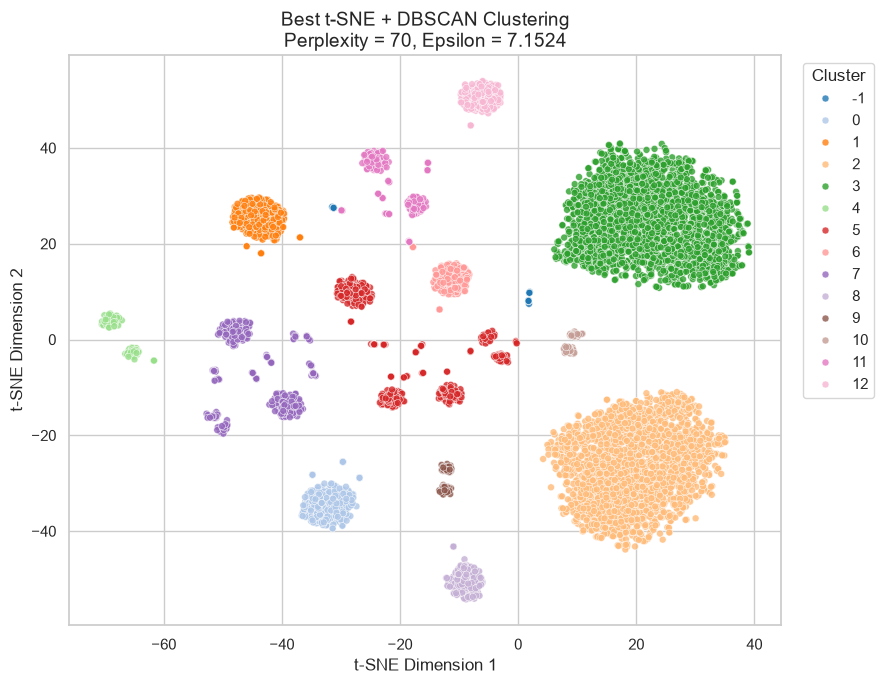

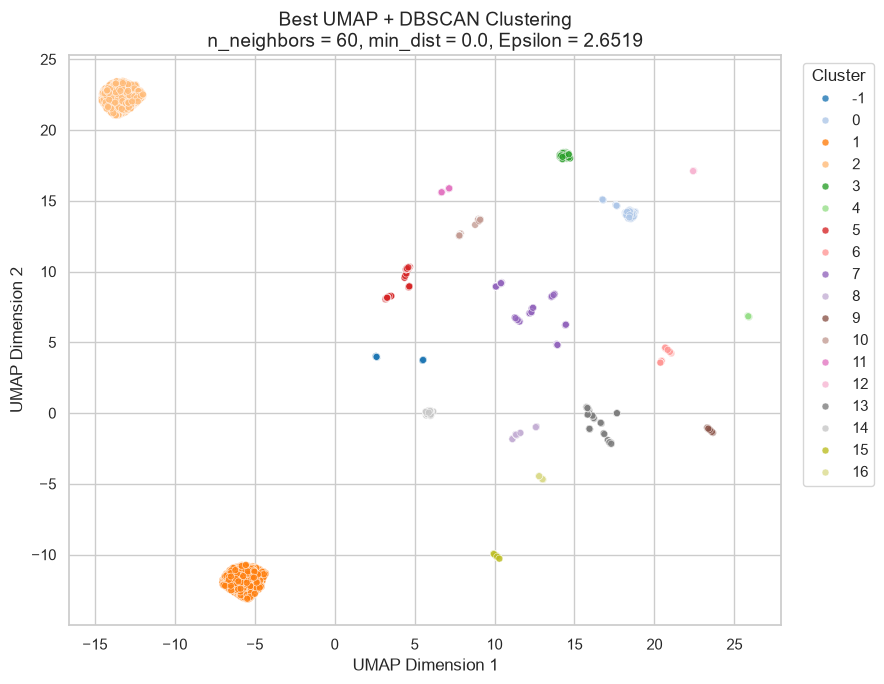

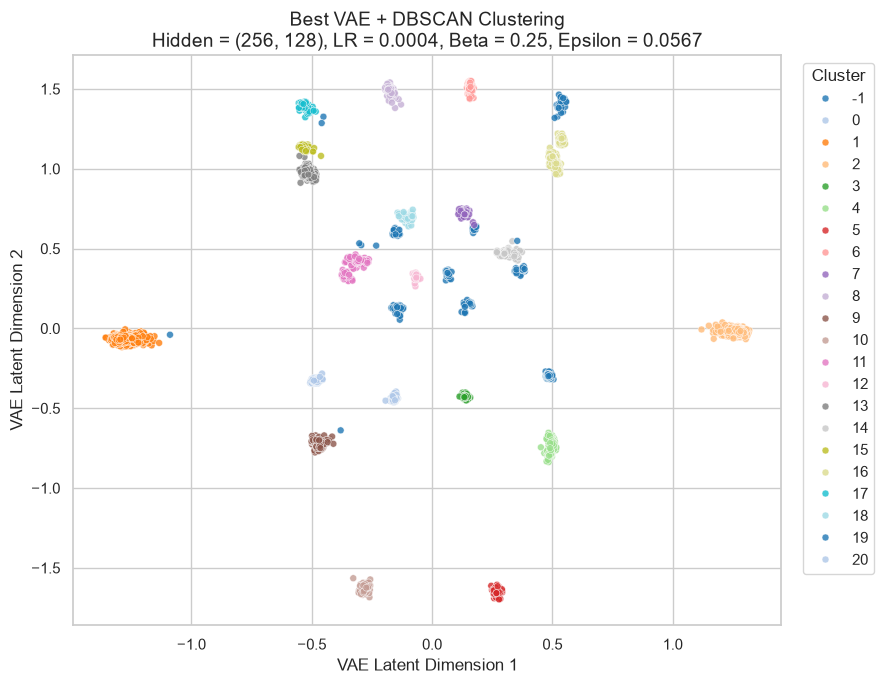

In [52]:
# =========================================================
# 1. Best t-SNE + DBSCAN
# =========================================================

best_tsne_embedding = tsne_embeddings[
    best_tsne_perplexity
]

tsne_plot_df = pd.DataFrame({
    "dimension_1": best_tsne_embedding[:, 0],
    "dimension_2": best_tsne_embedding[:, 1],
    "cluster": best_tsne_labels
})


plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=tsne_plot_df,
    x="dimension_1",
    y="dimension_2",
    hue="cluster",
    palette="tab20",
    s=25,
    alpha=0.8,
    legend="full"
)

plt.title(
    f"Best t-SNE + DBSCAN Clustering\n"
    f"Perplexity = {best_tsne_perplexity}, "
    f"Epsilon = {best_tsne_model['epsilon']:.4f}",
    fontsize=14
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    TSNE_PLOTS_DIR / "best_tsne_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 2. Best UMAP + DBSCAN
# =========================================================

best_umap_embedding = umap_embeddings[
    (
        best_umap_neighbors,
        best_umap_min_dist
    )
]

umap_plot_df = pd.DataFrame({
    "dimension_1": best_umap_embedding[:, 0],
    "dimension_2": best_umap_embedding[:, 1],
    "cluster": best_umap_labels
})


plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=umap_plot_df,
    x="dimension_1",
    y="dimension_2",
    hue="cluster",
    palette="tab20",
    s=25,
    alpha=0.8,
    legend="full"
)

plt.title(
    f"Best UMAP + DBSCAN Clustering\n"
    f"n_neighbors = {best_umap_neighbors}, "
    f"min_dist = {best_umap_min_dist}, "
    f"Epsilon = {best_umap_model['epsilon']:.4f}",
    fontsize=14
)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    UMAP_PLOTS_DIR / "best_umap_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 3. Best VAE + DBSCAN
# =========================================================

best_vae_embedding = vae_embeddings[
    (
        best_vae_hidden,
        best_vae_lr,
        best_vae_beta
    )
]

vae_plot_df = pd.DataFrame({
    "dimension_1": best_vae_embedding[:, 0],
    "dimension_2": best_vae_embedding[:, 1],
    "cluster": best_vae_labels
})


plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=vae_plot_df,
    x="dimension_1",
    y="dimension_2",
    hue="cluster",
    palette="tab20",
    s=25,
    alpha=0.8,
    legend="full"
)

plt.title(
    f"Best VAE + DBSCAN Clustering\n"
    f"Hidden = {best_vae_hidden}, "
    f"LR = {best_vae_lr}, "
    f"Beta = {best_vae_beta}, "
    f"Epsilon = {best_vae_model['epsilon']:.4f}",
    fontsize=14
)

plt.xlabel("VAE Latent Dimension 1")
plt.ylabel("VAE Latent Dimension 2")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    VAE_PLOTS_DIR / "best_vae_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Create and Save Cluster-Size Tables for the Three Best Models

In [53]:
# ---------------------------------------------------------
# Function to create cluster-size summary
# ---------------------------------------------------------

def create_cluster_size_table(labels):

    # Count patients in each cluster
    cluster_counts = pd.Series(labels).value_counts().sort_index()

    # Create summary table
    cluster_size_table = pd.DataFrame({
        "cluster": cluster_counts.index,
        "number_of_patients": cluster_counts.values
    })

    # Calculate percentage of total patients
    cluster_size_table["percentage"] = (
        cluster_size_table["number_of_patients"]
        / len(labels)
        * 100
    )

    return cluster_size_table


# =========================================================
# 1. t-SNE cluster sizes
# =========================================================

tsne_cluster_sizes = create_cluster_size_table(
    best_tsne_labels
)

tsne_cluster_sizes.to_csv(
    TSNE_CLUSTER_DIR / "best_tsne_cluster_sizes.csv",
    index=False
)


# =========================================================
# 2. UMAP cluster sizes
# =========================================================

umap_cluster_sizes = create_cluster_size_table(
    best_umap_labels
)

umap_cluster_sizes.to_csv(
    UMAP_CLUSTER_DIR / "best_umap_cluster_sizes.csv",
    index=False
)


# =========================================================
# 3. VAE cluster sizes
# =========================================================

vae_cluster_sizes = create_cluster_size_table(
    best_vae_labels
)

vae_cluster_sizes.to_csv(
    VAE_CLUSTER_DIR / "best_vae_cluster_sizes.csv",
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("Best t-SNE Cluster Sizes")
display(tsne_cluster_sizes)

print("\nBest UMAP Cluster Sizes")
display(umap_cluster_sizes)

print("\nBest VAE Cluster Sizes")
display(vae_cluster_sizes)

Best t-SNE Cluster Sizes


,cluster,number_of_patients,percentage
0,-1,56,0.712559
1,0,385,4.898842
2,1,362,4.606184
3,2,2118,26.949994
4,3,2195,27.929762
5,4,171,2.175849
6,5,676,8.601603
7,6,249,3.168342
8,7,625,7.952666
9,8,246,3.130169



Best UMAP Cluster Sizes


,cluster,number_of_patients,percentage
0,-1,76,0.967044
1,0,393,5.000636
2,1,2118,26.949994
3,2,2195,27.929762
4,3,354,4.504390
5,4,98,1.246978
6,5,287,3.651864
7,6,249,3.168342
8,7,567,7.214658
9,8,141,1.794121



Best VAE Cluster Sizes


,cluster,number_of_patients,percentage
0,-1,241,3.066548
1,0,363,4.618908
2,1,2117,26.937269
3,2,2195,27.929762
4,3,352,4.478941
5,4,190,2.417610
6,5,229,2.913857
7,6,175,2.226746
8,7,70,0.890699
9,8,175,2.226746


## Save the Best Embeddings Together with Final Cluster Labels

In [54]:
# =========================================================
# 1. Best t-SNE embedding with cluster labels
# =========================================================

best_tsne_complete = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "tsne_1": best_tsne_embedding[:, 0],
    "tsne_2": best_tsne_embedding[:, 1],
    "cluster": best_tsne_labels
})

best_tsne_complete.to_csv(
    TSNE_CLUSTER_DIR / "best_tsne_embedding_with_clusters.csv",
    index=False
)


# =========================================================
# 2. Best UMAP embedding with cluster labels
# =========================================================

best_umap_complete = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "umap_1": best_umap_embedding[:, 0],
    "umap_2": best_umap_embedding[:, 1],
    "cluster": best_umap_labels
})

best_umap_complete.to_csv(
    UMAP_CLUSTER_DIR / "best_umap_embedding_with_clusters.csv",
    index=False
)


# =========================================================
# 3. Best VAE embedding with cluster labels
# =========================================================

best_vae_complete = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "vae_1": best_vae_embedding[:, 0],
    "vae_2": best_vae_embedding[:, 1],
    "cluster": best_vae_labels
})

best_vae_complete.to_csv(
    VAE_CLUSTER_DIR / "best_vae_embedding_with_clusters.csv",
    index=False
)


# ---------------------------------------------------------
# Confirm saved files
# ---------------------------------------------------------

print("Best embedding + cluster files saved successfully.")

print("\nt-SNE:")
print(
    TSNE_CLUSTER_DIR
    / "best_tsne_embedding_with_clusters.csv"
)

print("\nUMAP:")
print(
    UMAP_CLUSTER_DIR
    / "best_umap_embedding_with_clusters.csv"
)

print("\nVAE:")
print(
    VAE_CLUSTER_DIR
    / "best_vae_embedding_with_clusters.csv"
)

Best embedding + cluster files saved successfully.

t-SNE:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\tsne\best_tsne_embedding_with_clusters.csv

UMAP:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\umap\best_umap_embedding_with_clusters.csv

VAE:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\clusters\vae\best_vae_embedding_with_clusters.csv


## Plot the Internal Metrics of the Three Best Models

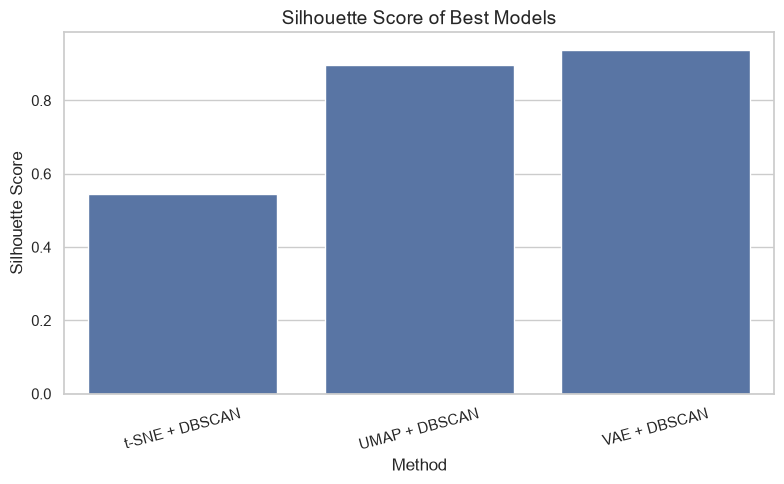

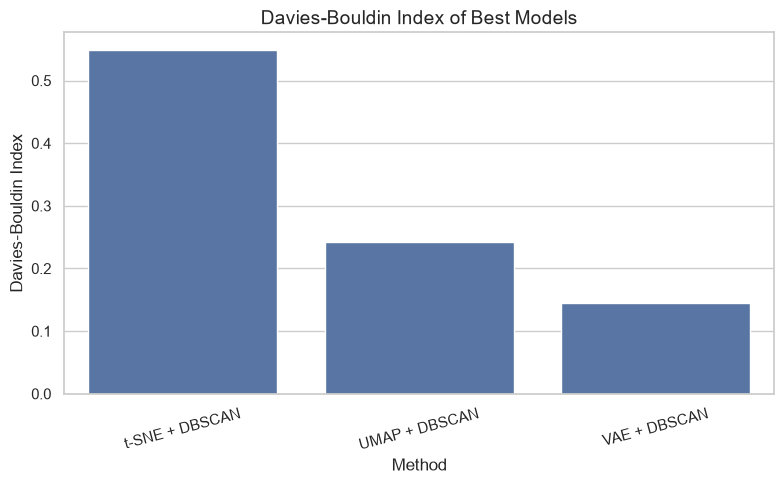

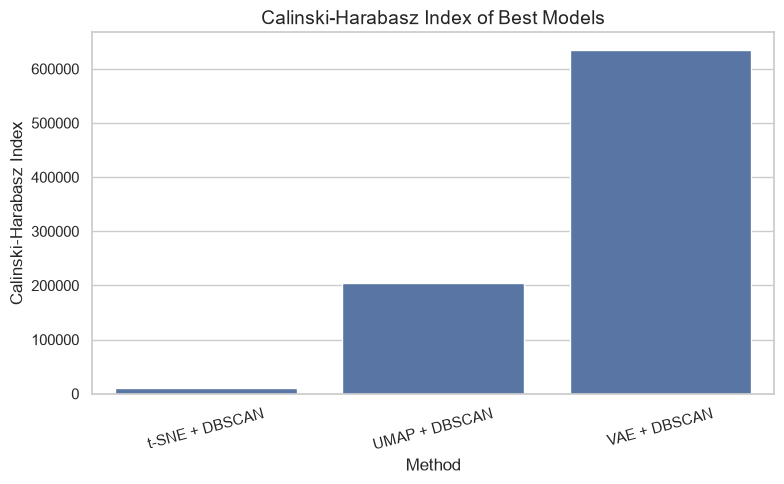

In [55]:
# ---------------------------------------------------------
# Prepare comparison data
# ---------------------------------------------------------

comparison_df = final_model_summary[
    [
        "method",
        "silhouette_score",
        "davies_bouldin_index",
        "calinski_harabasz_index"
    ]
].copy()


# ---------------------------------------------------------
# Use Seaborn whitegrid style
# ---------------------------------------------------------

sns.set_theme(style="whitegrid")


# =========================================================
# 1. Silhouette Score
# Higher is better
# =========================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x="method",
    y="silhouette_score"
)

plt.title(
    "Silhouette Score of Best Models",
    fontsize=14
)

plt.xlabel("Method")
plt.ylabel("Silhouette Score")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "best_models_silhouette_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 2. Davies-Bouldin Index
# Lower is better
# =========================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x="method",
    y="davies_bouldin_index"
)

plt.title(
    "Davies-Bouldin Index of Best Models",
    fontsize=14
)

plt.xlabel("Method")
plt.ylabel("Davies-Bouldin Index")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "best_models_davies_bouldin_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 3. Calinski-Harabasz Index
# Higher is better
# =========================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x="method",
    y="calinski_harabasz_index"
)

plt.title(
    "Calinski-Harabasz Index of Best Models",
    fontsize=14
)

plt.xlabel("Method")
plt.ylabel("Calinski-Harabasz Index")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "best_models_calinski_harabasz_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Compare Cluster Counts and Outlier Percentages of the Best Models

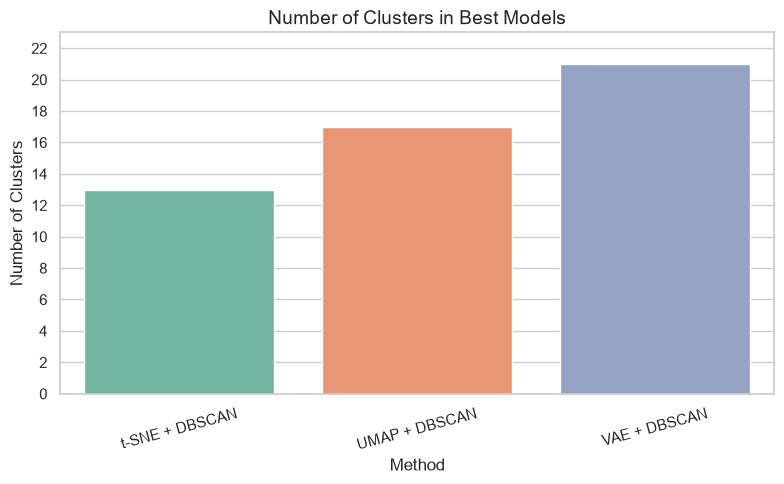

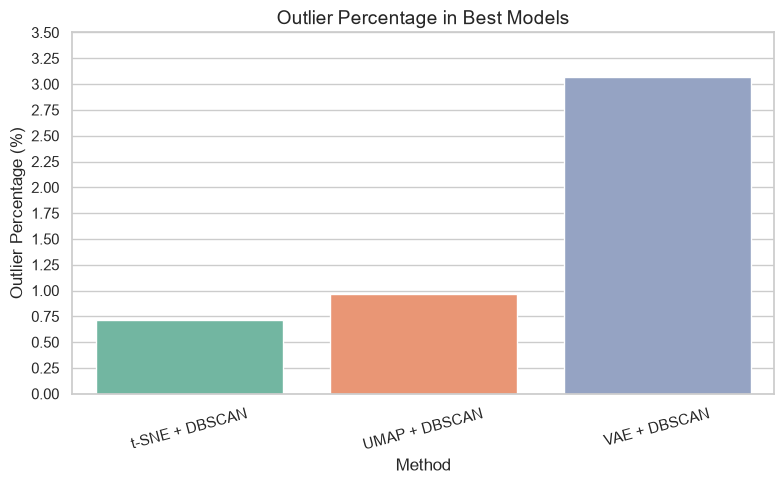

In [56]:
# ---------------------------------------------------------
# Prepare comparison data
# ---------------------------------------------------------

cluster_comparison_df = final_model_summary[
    [
        "method",
        "number_of_clusters",
        "outlier_percentage"
    ]
].copy()


# ---------------------------------------------------------
# Plot style
# ---------------------------------------------------------

sns.set_theme(style="whitegrid")

# Give each method a different color
method_palette = sns.color_palette(
    "Set2",
    n_colors=len(cluster_comparison_df)
)


# =========================================================
# 1. Number of clusters
# =========================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_comparison_df,
    x="method",
    y="number_of_clusters",
    hue="method",
    palette=method_palette,
    legend=False
)

plt.title(
    "Number of Clusters in Best Models",
    fontsize=14
)

plt.xlabel("Method")
plt.ylabel("Number of Clusters")

# Y-axis: 0, 2, 4, ..., 20
plt.yticks(
    np.arange(0, 23, 2)
)

plt.ylim(0, 23)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "best_models_cluster_count_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 2. Outlier percentage
# =========================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_comparison_df,
    x="method",
    y="outlier_percentage",
    hue="method",
    palette=method_palette,
    legend=False
)

plt.title(
    "Outlier Percentage in Best Models",
    fontsize=14
)

plt.xlabel("Method")
plt.ylabel("Outlier Percentage (%)")

# Y-axis: 0.00, 0.25, 0.50, ..., 3.50
outlier_ticks = np.arange(
    0,
    3.51,
    0.25
)

plt.yticks(
    outlier_ticks,
    [f"{value:.2f}" for value in outlier_ticks]
)

plt.ylim(0, 3.5)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "best_models_outlier_percentage_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Compare the Smallest Cluster Size of the Best Models

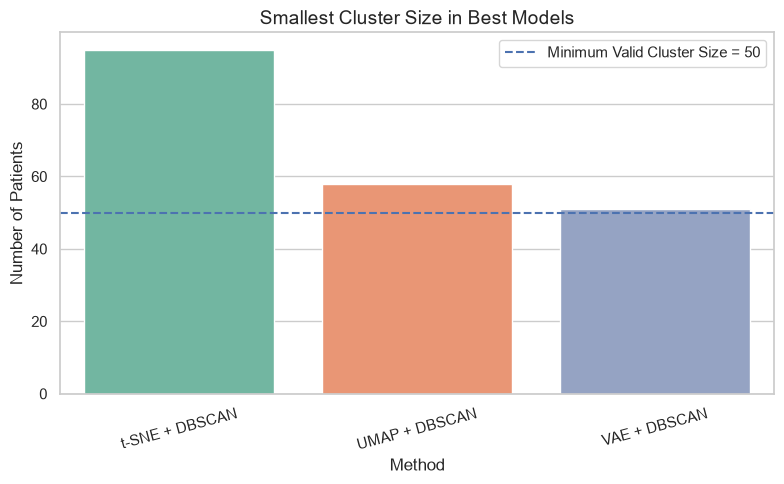

In [57]:
# ---------------------------------------------------------
# Prepare smallest-cluster comparison data
# ---------------------------------------------------------

smallest_cluster_df = final_model_summary[
    [
        "method",
        "smallest_cluster_size"
    ]
].copy()


# ---------------------------------------------------------
# Plot style
# ---------------------------------------------------------

sns.set_theme(style="whitegrid")


# ---------------------------------------------------------
# Plot smallest cluster size
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=smallest_cluster_df,
    x="method",
    y="smallest_cluster_size",
    hue="method",
    palette=method_palette,
    legend=False
)


# ---------------------------------------------------------
# Add minimum validity threshold
# ---------------------------------------------------------

plt.axhline(
    y=50,
    linestyle="--",
    label="Minimum Valid Cluster Size = 50"
)


# ---------------------------------------------------------
# Plot formatting
# ---------------------------------------------------------

plt.title(
    "Smallest Cluster Size in Best Models",
    fontsize=14
)

plt.xlabel("Method")
plt.ylabel("Number of Patients")

plt.xticks(rotation=15)

plt.legend()

plt.tight_layout()


# ---------------------------------------------------------
# Save plot
# ---------------------------------------------------------

plt.savefig(
    PLOTS_DIR / "best_models_smallest_cluster_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Create and Save the Final Selected Hyperparameters Table

In [58]:
# ---------------------------------------------------------
# Create final selected hyperparameter table
# ---------------------------------------------------------

selected_hyperparameters = pd.DataFrame([

    # -----------------------------------------------------
    # t-SNE + DBSCAN
    # -----------------------------------------------------

    {
        "method": "t-SNE + DBSCAN",

        "perplexity": int(
            best_tsne_model["perplexity"]
        ),

        "n_neighbors": np.nan,
        "min_dist": np.nan,

        "hidden_layers": np.nan,
        "learning_rate": np.nan,
        "beta": np.nan,

        "embedding_dimensions": 2,

        "dbscan_min_samples": DBSCAN_MIN_SAMPLES,

        "epsilon_multiplier": (
            best_tsne_model["epsilon_multiplier"]
        ),

        "epsilon": (
            best_tsne_model["epsilon"]
        )
    },


    # -----------------------------------------------------
    # UMAP + DBSCAN
    # -----------------------------------------------------

    {
        "method": "UMAP + DBSCAN",

        "perplexity": np.nan,

        "n_neighbors": int(
            best_umap_model["n_neighbors"]
        ),

        "min_dist": (
            best_umap_model["min_dist"]
        ),

        "hidden_layers": np.nan,
        "learning_rate": np.nan,
        "beta": np.nan,

        "embedding_dimensions": 2,

        "dbscan_min_samples": DBSCAN_MIN_SAMPLES,

        "epsilon_multiplier": (
            best_umap_model["epsilon_multiplier"]
        ),

        "epsilon": (
            best_umap_model["epsilon"]
        )
    },


    # -----------------------------------------------------
    # VAE + DBSCAN
    # -----------------------------------------------------

    {
        "method": "VAE + DBSCAN",

        "perplexity": np.nan,
        "n_neighbors": np.nan,
        "min_dist": np.nan,

        "hidden_layers": (
            f"({int(best_vae_model['hidden_layer_1'])}, "
            f"{int(best_vae_model['hidden_layer_2'])})"
        ),

        "learning_rate": (
            best_vae_model["learning_rate"]
        ),

        "beta": (
            best_vae_model["beta"]
        ),

        "embedding_dimensions": VAE_LATENT_DIM,

        "dbscan_min_samples": DBSCAN_MIN_SAMPLES,

        "epsilon_multiplier": (
            best_vae_model["epsilon_multiplier"]
        ),

        "epsilon": (
            best_vae_model["epsilon"]
        )
    }
])


# ---------------------------------------------------------
# Save selected hyperparameters
# ---------------------------------------------------------

selected_parameters_file = (
    RESULTS_DIR
    / "hyperparameter_results"
    / "final_selected_hyperparameters.csv"
)

selected_hyperparameters.to_csv(
    selected_parameters_file,
    index=False
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("Final Selected Hyperparameters")
print("=" * 50)

display(selected_hyperparameters)

print("\nSaved to:")
print(selected_parameters_file)

Final Selected Hyperparameters


,method,perplexity,n_neighbors,min_dist,hidden_layers,learning_rate,beta,embedding_dimensions,dbscan_min_samples,epsilon_multiplier,epsilon
0,t-SNE + DBSCAN,70.0,NaN,NaN,NaN,NaN,NaN,2,50,0.8,7.152357
1,UMAP + DBSCAN,NaN,60.0,0.0,NaN,NaN,NaN,2,50,0.9,2.651944
2,VAE + DBSCAN,NaN,NaN,NaN,"(256, 128)",0.0004,0.25,2,50,0.9,0.056688



Saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\final_selected_hyperparameters.csv


## Create the Final Complete Model-Selection Table

In [59]:
# ---------------------------------------------------------
# Create final complete model-selection table
# ---------------------------------------------------------

final_selection_table = pd.DataFrame([

    # =====================================================
    # t-SNE + DBSCAN
    # =====================================================

    {
        "method": "t-SNE + DBSCAN",

        "selected_parameters": (
            f"Perplexity = {int(best_tsne_model['perplexity'])}"
        ),

        "epsilon_multiplier": (
            best_tsne_model["epsilon_multiplier"]
        ),

        "epsilon": (
            best_tsne_model["epsilon"]
        ),

        "number_of_clusters": int(
            best_tsne_model["number_of_clusters"]
        ),

        "number_of_outliers": int(
            best_tsne_model["number_of_outliers"]
        ),

        "outlier_percentage": (
            best_tsne_model["outlier_percentage"]
        ),

        "smallest_cluster_size": int(
            best_tsne_model["smallest_cluster_size"]
        ),

        "silhouette_score": (
            best_tsne_model["silhouette_score"]
        ),

        "davies_bouldin_index": (
            best_tsne_model["davies_bouldin_index"]
        ),

        "calinski_harabasz_index": (
            best_tsne_model["calinski_harabasz_index"]
        )
    },


    # =====================================================
    # UMAP + DBSCAN
    # =====================================================

    {
        "method": "UMAP + DBSCAN",

        "selected_parameters": (
            f"n_neighbors = {int(best_umap_model['n_neighbors'])}, "
            f"min_dist = {best_umap_model['min_dist']}"
        ),

        "epsilon_multiplier": (
            best_umap_model["epsilon_multiplier"]
        ),

        "epsilon": (
            best_umap_model["epsilon"]
        ),

        "number_of_clusters": int(
            best_umap_model["number_of_clusters"]
        ),

        "number_of_outliers": int(
            best_umap_model["number_of_outliers"]
        ),

        "outlier_percentage": (
            best_umap_model["outlier_percentage"]
        ),

        "smallest_cluster_size": int(
            best_umap_model["smallest_cluster_size"]
        ),

        "silhouette_score": (
            best_umap_model["silhouette_score"]
        ),

        "davies_bouldin_index": (
            best_umap_model["davies_bouldin_index"]
        ),

        "calinski_harabasz_index": (
            best_umap_model["calinski_harabasz_index"]
        )
    },


    # =====================================================
    # VAE + DBSCAN
    # =====================================================

    {
        "method": "VAE + DBSCAN",

        "selected_parameters": (
            f"Hidden = {best_vae_hidden}, "
            f"Learning Rate = {best_vae_lr}, "
            f"Beta = {best_vae_beta}"
        ),

        "epsilon_multiplier": (
            best_vae_model["epsilon_multiplier"]
        ),

        "epsilon": (
            best_vae_model["epsilon"]
        ),

        "number_of_clusters": int(
            best_vae_model["number_of_clusters"]
        ),

        "number_of_outliers": int(
            best_vae_model["number_of_outliers"]
        ),

        "outlier_percentage": (
            best_vae_model["outlier_percentage"]
        ),

        "smallest_cluster_size": int(
            best_vae_model["smallest_cluster_size"]
        ),

        "silhouette_score": (
            best_vae_model["silhouette_score"]
        ),

        "davies_bouldin_index": (
            best_vae_model["davies_bouldin_index"]
        ),

        "calinski_harabasz_index": (
            best_vae_model["calinski_harabasz_index"]
        )
    }
])


# ---------------------------------------------------------
# Save final selection table
# ---------------------------------------------------------

final_selection_file = (
    RESULTS_DIR
    / "hyperparameter_results"
    / "final_model_selection_table.csv"
)

final_selection_table.to_csv(
    final_selection_file,
    index=False
)


# ---------------------------------------------------------
# Display final table
# ---------------------------------------------------------

print("Final Model Selection Table")
print("=" * 60)

display(final_selection_table)

print("\nSaved to:")
print(final_selection_file)

Final Model Selection Table


,method,selected_parameters,epsilon_multiplier,epsilon,number_of_clusters,number_of_outliers,outlier_percentage,smallest_cluster_size,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,t-SNE + DBSCAN,Perplexity = 70,0.8,7.152357,13,56,0.712559,95,0.543774,0.549291,10800.525614
1,UMAP + DBSCAN,"n_neighbors = 60, min_dist = 0.0",0.9,2.651944,17,76,0.967044,58,0.897240,0.241929,204514.361714
2,VAE + DBSCAN,"Hidden = (256, 128), Learning Rate = 0.0004, B...",0.9,0.056688,21,241,3.066548,51,0.938488,0.144631,635372.705302



Saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\3.nonlinear_dbscan_hyperparameter\hyperparameter_results\final_model_selection_table.csv


## Verify the Final Hyperparameter-Tuning Outputs

In [60]:
# ---------------------------------------------------------
# Important final output files
# ---------------------------------------------------------

final_output_files = [

    # Final overall results
    RESULTS_DIR
    / "hyperparameter_results"
    / "final_selected_hyperparameters.csv",

    RESULTS_DIR
    / "hyperparameter_results"
    / "final_model_selection_table.csv",

    # Ranked t-SNE results
    TSNE_RESULTS_DIR
    / "tsne_ranked_models.csv",

    # Ranked UMAP results
    UMAP_RESULTS_DIR
    / "umap_ranked_models.csv",

    # Ranked VAE results
    VAE_RESULTS_DIR
    / "vae_ranked_models.csv",

    # Best t-SNE clusters
    TSNE_CLUSTER_DIR
    / "best_tsne_embedding_with_clusters.csv",

    # Best UMAP clusters
    UMAP_CLUSTER_DIR
    / "best_umap_embedding_with_clusters.csv",

    # Best VAE clusters
    VAE_CLUSTER_DIR
    / "best_vae_embedding_with_clusters.csv"
]


# ---------------------------------------------------------
# Check whether each file exists
# ---------------------------------------------------------

print("Final Output Verification")
print("=" * 60)

for file in final_output_files:

    if file.exists():
        print("FOUND :", file.name)

    else:
        print("MISSING:", file.name)

Final Output Verification
FOUND : final_selected_hyperparameters.csv
FOUND : final_model_selection_table.csv
FOUND : tsne_ranked_models.csv
FOUND : umap_ranked_models.csv
FOUND : vae_ranked_models.csv
FOUND : best_tsne_embedding_with_clusters.csv
FOUND : best_umap_embedding_with_clusters.csv
FOUND : best_vae_embedding_with_clusters.csv
